In [1]:
# ============================================================
# Cell 1: Imports & Environment Sanity Check
# (RF-DETR detection + ByteTrack tracking)
# ============================================================

# ---- Standard library ----
import os
import sys
import time
import json
import random
from pathlib import Path
from typing import List, Dict, Tuple, Optional

# ---- Numerical / scientific ----
import numpy as np

# ---- Computer vision / video I/O ----
import cv2

# ---- Visualization ----
import matplotlib.pyplot as plt

# ---- Deep learning ----
import torch

# ---- Detector ----
from rfdetr import RFDETRNano

# ---- Tracking (ByteTrack) ----
# supervision provides a ByteTrack wrapper that's convenient for notebooks
try:
    import supervision as sv
    SUPERVISION_OK = True
except Exception as e:
    SUPERVISION_OK = False
    print("Could not import supervision (needed for ByteTrack).")
    print(" Install with: pip install supervision")
    print(" Import error:", repr(e))

# ---- Utilities ----
from tqdm.auto import tqdm
import psutil

# ============================================================
# Environment sanity prints
# ============================================================

print("=== Environment Check ===")
print(f"Python version      : {sys.version.split()[0]}")
print(f"PyTorch version     : {torch.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version        : {torch.version.cuda}")
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")

print(f"CPU cores           : {psutil.cpu_count(logical=True)}")
print(f"supervision ready   : {SUPERVISION_OK}")
if SUPERVISION_OK:
    print(f"supervision version : {sv.__version__}")
print("=========================")

=== Environment Check ===
Python version      : 3.11.9
PyTorch version     : 2.5.1+cu121
CUDA available      : False
CPU cores           : 8
supervision ready   : True
supervision version : 0.27.0


Device: cpu
Checkpoint: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\models\infrared-training\dronevehicle_rfdetr_nano_best_ema.pth
Loading detector from checkpoint...
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
Detector loaded and ready.


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Infrared sanity test image: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\visdrone-dataset-infrared\val\valimgr\00368.jpg


Detections: 27 (threshold=0.3)


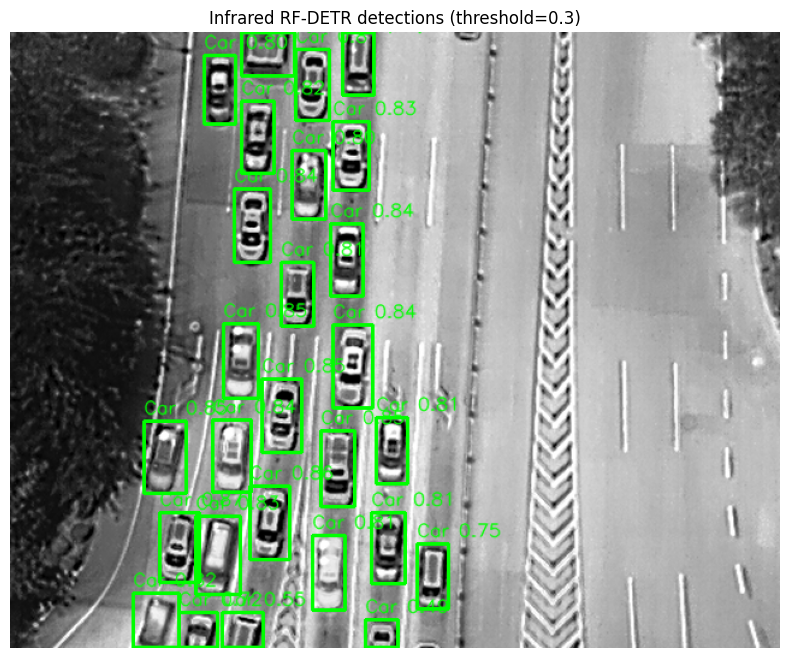

In [2]:
# ============================================================
# Cell 2: Load infrared-trained RF-DETR + visualize detections
# ============================================================

from pathlib import Path
import random
import torch
import cv2
import matplotlib.pyplot as plt
from rfdetr import RFDETRNano

# -----------------------------
# 1) Paths + config
# -----------------------------
PHASE_ROOT = Path.cwd().parent.parent
RFDETR_MODELS_DIR = PHASE_ROOT / "rfdetr" / "models"
INFRARED_RFDETR_MODELS_DIR = RFDETR_MODELS_DIR / "infrared-training"

CKPT_PATH = INFRARED_RFDETR_MODELS_DIR / "dronevehicle_rfdetr_nano_best_ema.pth"
FALLBACK_CKPT_PATH = INFRARED_RFDETR_MODELS_DIR / "dronevehicle_rfdetr_nano_latest_resume.pth"

VAL_IMG_DIR = PHASE_ROOT / "visdrone-dataset-infrared" / "val" / "valimgr"
THRESHOLD = 0.30

# DroneVehicle border crop policy used during training
REMOVE_WHITE_BORDER = True
BORDER_LEFT = 100
BORDER_RIGHT = 100
BORDER_TOP = 100
BORDER_BOTTOM = 100

# Phase class names
PHASE_CLASSES = {
    1: "Human",
    2: "Bicycle",
    3: "Car",
    4: "Truck",
    5: "Bus",
    6: "Other",
}

if CKPT_PATH.exists():
    RESOLVED_CKPT = CKPT_PATH
elif FALLBACK_CKPT_PATH.exists():
    RESOLVED_CKPT = FALLBACK_CKPT_PATH
else:
    raise FileNotFoundError(
        "No infrared-training checkpoint found.\n"
        f"Tried:\n- {CKPT_PATH}\n- {FALLBACK_CKPT_PATH}"
    )

assert VAL_IMG_DIR.exists(), f"Infrared val image dir not found: {VAL_IMG_DIR}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Checkpoint:", RESOLVED_CKPT)

# -----------------------------
# 2) Helpers
# -----------------------------
def collect_image_files(folder: Path):
    valid_suffixes = {".jpg", ".jpeg"}
    return sorted(
        [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in valid_suffixes]
    )

def crop_white_border(img_bgr):
    if not REMOVE_WHITE_BORDER:
        return img_bgr

    h, w = img_bgr.shape[:2]
    cropped = img_bgr[BORDER_TOP:h-BORDER_BOTTOM, BORDER_LEFT:w-BORDER_RIGHT]

    expected_w = 840 - BORDER_LEFT - BORDER_RIGHT   # 640
    expected_h = 712 - BORDER_TOP - BORDER_BOTTOM   # 512

    assert cropped.shape[1] == expected_w, (
        f"Cropped width mismatch. Expected {expected_w}, got {cropped.shape[1]}"
    )
    assert cropped.shape[0] == expected_h, (
        f"Cropped height mismatch. Expected {expected_h}, got {cropped.shape[0]}"
    )

    return cropped

# -----------------------------
# 3) Load model
# -----------------------------
global DETECTOR, _DETECTOR_CKPT
if "DETECTOR" not in globals() or "_DETECTOR_CKPT" not in globals() or _DETECTOR_CKPT != str(RESOLVED_CKPT):
    print("Loading detector from checkpoint...")
    DETECTOR = RFDETRNano(num_classes=len(PHASE_CLASSES), pretrain_weights=str(RESOLVED_CKPT))
    _DETECTOR_CKPT = str(RESOLVED_CKPT)

DETECTOR.model.model.to(device)
DETECTOR.model.model.eval()
print("Detector loaded and ready.")

# -----------------------------
# 4) Pick a random infrared image and run prediction
# -----------------------------
imgs = collect_image_files(VAL_IMG_DIR)
assert imgs, f"No images found in: {VAL_IMG_DIR}"

image_path = str(random.choice(imgs))
print("Infrared sanity test image:", image_path)

img_bgr_original = cv2.imread(image_path)
if img_bgr_original is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

img_bgr_cropped = crop_white_border(img_bgr_original)

# Save temporary cropped file for prediction so inference matches training geometry
temp_infer_path = str(Path(image_path).with_name(Path(image_path).stem + "_cropped_for_inference.jpg"))
ok = cv2.imwrite(temp_infer_path, img_bgr_cropped)
assert ok, f"Failed to write temporary cropped inference image: {temp_infer_path}"

det = DETECTOR.predict(temp_infer_path, threshold=THRESHOLD)
print(f"Detections: {len(det.xyxy)} (threshold={THRESHOLD})")

# -----------------------------
# 5) Visualize boxes
# -----------------------------
img_rgb = cv2.cvtColor(img_bgr_cropped, cv2.COLOR_BGR2RGB)

for box, score, cls in zip(det.xyxy, det.confidence, det.class_id):
    x1, y1, x2, y2 = map(int, box.tolist())
    cls = int(cls)
    label = PHASE_CLASSES.get(cls, f"class_{cls}")
    text = f"{label} {float(score):.2f}"

    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        img_rgb,
        text,
        (x1, max(0, y1 - 6)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA,
    )

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"Infrared RF-DETR detections (threshold={THRESHOLD})")
plt.show()

In [3]:
# ============================================================
# Cell 3: Initialize ByteTrack
# ============================================================

import inspect
import numpy as np
import cv2

assert SUPERVISION_OK, "supervision is not installed/importable. Install with: pip install supervision"

# ---- Desired tracking settings (we'll tune later) ----
TRACK_THRESH = 0.30
TRACK_BUFFER = 30
MATCH_THRESH = 0.80
FRAME_RATE   = 30

# ---- Build kwargs based on what this supervision version supports ----
sig = inspect.signature(sv.ByteTrack.__init__)
params = set(sig.parameters.keys())

kwargs = {}

# Newer supervision naming
if "track_activation_threshold" in params:
    kwargs["track_activation_threshold"] = TRACK_THRESH
if "lost_track_buffer" in params:
    kwargs["lost_track_buffer"] = TRACK_BUFFER
if "minimum_matching_threshold" in params:
    kwargs["minimum_matching_threshold"] = MATCH_THRESH
if "frame_rate" in params:
    kwargs["frame_rate"] = FRAME_RATE

# Older naming (what we tried originally)
if "track_thresh" in params:
    kwargs["track_thresh"] = TRACK_THRESH
if "track_buffer" in params:
    kwargs["track_buffer"] = TRACK_BUFFER
if "match_thresh" in params:
    kwargs["match_thresh"] = MATCH_THRESH

# Fallback: if none of these are accepted, instantiate without args
try:
    TRACKER = sv.ByteTrack(**kwargs)
except TypeError:
    TRACKER = sv.ByteTrack()

print("ByteTrack initialized")
print("ByteTrack init kwargs used:", kwargs)

# -----------------------------
# Helper: RF-DETR detections -> supervision.Detections
# -----------------------------
def rfdetr_to_sv_detections(det, min_conf=0.30):
    xyxy = np.asarray(det.xyxy, dtype=np.float32)
    conf = np.asarray(det.confidence, dtype=np.float32)
    cls  = np.asarray(det.class_id, dtype=np.int32)

    keep = conf >= float(min_conf)
    return sv.Detections(
        xyxy=xyxy[keep],
        confidence=conf[keep],
        class_id=cls[keep]
    )

# -----------------------------
# Helper: Draw tracks
# -----------------------------
def draw_tracks(frame_bgr, detections: "sv.Detections", class_map: dict, show_conf=True):
    out = frame_bgr.copy()
    tracker_ids = getattr(detections, "tracker_id", None)

    for i, box in enumerate(detections.xyxy):
        x1, y1, x2, y2 = box.astype(int).tolist()
        cls = int(detections.class_id[i]) if detections.class_id is not None else -1
        conf = float(detections.confidence[i]) if detections.confidence is not None else 0.0

        tid = int(tracker_ids[i]) if tracker_ids is not None and tracker_ids[i] is not None else -1
        label = class_map.get(cls, f"class_{cls}")

        text = f"ID {tid}: {label}" if tid >= 0 else label
        if show_conf:
            text += f" {conf:.2f}"

        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(out, text, (x1, max(0, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)

    return out

print("Helpers ready: rfdetr_to_sv_detections(), draw_tracks()")

ByteTrack initialized
ByteTrack init kwargs used: {'track_activation_threshold': 0.3, 'lost_track_buffer': 30, 'minimum_matching_threshold': 0.8, 'frame_rate': 30}
Helpers ready: rfdetr_to_sv_detections(), draw_tracks()


In [4]:
# ============================================================
# Cell 4: Frames folder OR video file -> Detect (every N) -> ByteTrack -> Output mp4
# ============================================================

from pathlib import Path
import cv2
import numpy as np
from tqdm.auto import tqdm

# -----------------------------
# 1) Input configuration
# -----------------------------
# FRAMES_DIR = Path(PHASE_ROOT) / "rfdetr" / "videos" / "uav0000009_03358_v"
VIDEO_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "carla_rgb_speeds.mp4"

OUTPUT_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "tracked_output_carla_rgb_speeds.mp4"

DETECT_EVERY_N = 1
DET_THRESHOLD  = 0.30
MIN_BOX_AREA   = 30 * 30

FPS = 30.0
CLASS_MAP = PHASE_CLASSES

assert (VIDEO_PATH is not None) or FRAMES_DIR.exists(), "Provide VIDEO_PATH or a valid FRAMES_DIR."

# -----------------------------
# 2) Build frame iterator
# -----------------------------
def list_frames(folder: Path):
    exts = (".jpg", ".jpeg", ".png")
    frames = [p for p in folder.iterdir() if p.suffix.lower() in exts]
    return sorted(frames, key=lambda p: p.name)

frames_list = None
cap = None

if VIDEO_PATH is not None:
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 1:
        fps = FPS
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
else:
    frames_list = list_frames(FRAMES_DIR)
    assert len(frames_list) > 0, f"No frames found in: {FRAMES_DIR}"
    first = cv2.imread(str(frames_list[0]))
    assert first is not None, f"Could not read first frame: {frames_list[0]}"
    height, width = first.shape[:2]
    fps = FPS
    total_frames = len(frames_list)

print("Input:", VIDEO_PATH if VIDEO_PATH is not None else str(FRAMES_DIR))
print(f"Frames: {total_frames} | Size: {width}x{height} | Output FPS: {fps}")
print(f"Detect every N: {DETECT_EVERY_N}")

# -----------------------------
# 3) Configure tracker and reset for a new sequence
# -----------------------------
try:
    if hasattr(TRACKER, "frame_rate"):
        TRACKER.frame_rate = int(round(fps))
except Exception:
    pass

# Reset tracker so old tracks don’t leak between runs (if supported)
if hasattr(TRACKER, "reset"):
    TRACKER.reset()

# Track metadata: track_id -> (class_id, confidence)
track_meta = {}

def build_tensors_from_detections(detections: "sv.Detections") -> np.ndarray:
    """
    ByteTrack tensor format: Nx5 [x1, y1, x2, y2, score]
    """
    if len(detections) == 0:
        return np.zeros((0, 5), dtype=np.float32)
    return np.hstack([
        detections.xyxy.astype(np.float32),
        detections.confidence.reshape(-1, 1).astype(np.float32),
    ])

def active_tracks_to_boxes_and_ids(tracker) -> tuple[list[np.ndarray], list[int]]:
    """
    Convert tracker.tracked_tracks to (boxes, ids).
    Each track has tlbr (x1,y1,x2,y2) and external_track_id.
    """
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

# -----------------------------
# 4) Video writer
# -----------------------------
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_PATH), fourcc, fps, (width, height))
assert writer.isOpened(), f"Could not open writer: {OUTPUT_PATH}"

# -----------------------------
# 5) Main loop
# -----------------------------
pbar = tqdm(total=total_frames, desc="Processing frames")

for frame_idx in range(total_frames):
    # Load frame
    if cap is not None:
        ok, frame_bgr = cap.read()
        if not ok:
            break
    else:
        frame_bgr = cv2.imread(str(frames_list[frame_idx]))
        if frame_bgr is None:
            continue

    # Detection frame?
    if frame_idx % DETECT_EVERY_N == 0:
        temp_path = "temp_frame.jpg"
        cv2.imwrite(temp_path, frame_bgr)

        det = DETECTOR.predict(temp_path, threshold=DET_THRESHOLD)
        detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

        # Filter tiny boxes
        if len(detections) > 0:
            xyxy = detections.xyxy
            areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
            keep = areas >= MIN_BOX_AREA
            detections = detections[keep]

        # Advance tracker using tensors (core tracking update)
        tensors = build_tensors_from_detections(detections)
        _ = TRACKER.update_with_tensors(tensors)

        # ALSO run update_with_detections on detection frames to get tracker_id mapping
        det_with_ids = TRACKER.update_with_detections(detections)
        if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
            for i in range(len(det_with_ids)):
                tid = int(det_with_ids.tracker_id[i])
                cls = int(det_with_ids.class_id[i])
                conf = float(det_with_ids.confidence[i])
                track_meta[tid] = (cls, conf)

    else:
        # No detections: predict/propagate tracks forward
        _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

    # Draw ACTIVE TRACKS every frame (so boxes persist)
    out = frame_bgr.copy()
    boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)

    for box, tid in zip(boxes, ids):
        x1, y1, x2, y2 = box.astype(int).tolist()
        cls, conf = track_meta.get(tid, (-1, 0.0))
        label = CLASS_MAP.get(cls, f"class_{cls}") if cls != -1 else "unknown"
        text = f"ID {tid}: {label} {conf:.2f}"

        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(out, text, (x1, max(0, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)

    writer.write(out)
    pbar.update(1)

pbar.close()
if cap is not None:
    cap.release()
writer.release()

print(f"\nDone. Saved tracked video to: {OUTPUT_PATH}")

Input: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\carla_rgb_speeds.mp4
Frames: 521 | Size: 800x600 | Output FPS: 20.0
Detect every N: 1


Processing frames:   0%|          | 0/521 [00:00<?, ?it/s]


Done. Saved tracked video to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\tracked_output_carla_rgb_speeds.mp4


# Speed Estimation
Detection + Tracking was accomplished above. Now we try determining speeds of objects using homography.

source: https://www.scitepress.org/Papers/2022/110936/110936.pdf

=== Calibration Frame Selected ===
Source              : video frame 135
Frame index         : 135
Frame shape (HxWxC) : (600, 800, 3)
Next step           : In Cell 6, click the 4 road-plane corners of one reference vehicle.
Saved calibration preview to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\calibration_frame_135.jpg


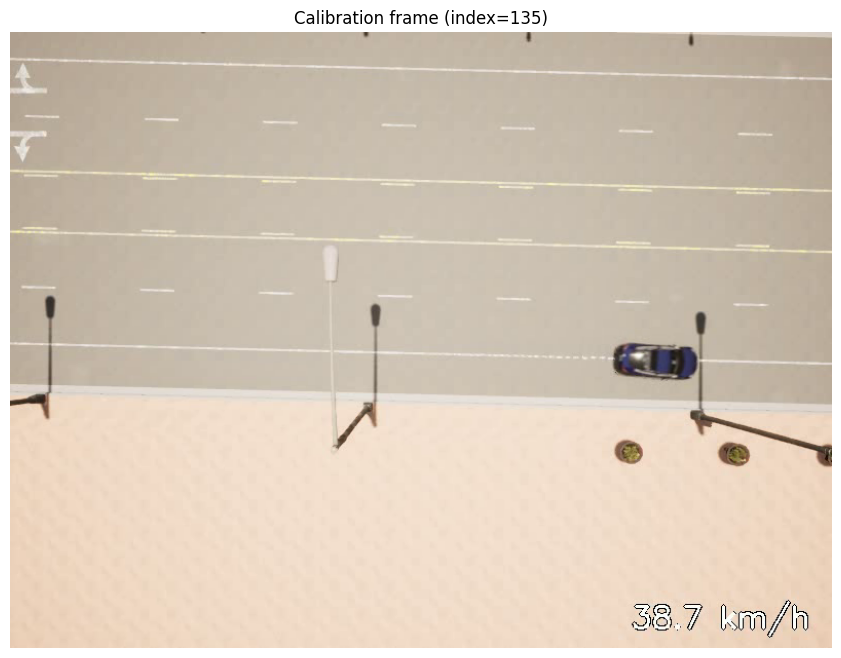

In [5]:
# ============================================================
# Cell 5: Select and display the calibration frame
# Purpose:
# - choose one good frame for homography initialization
# - save that frame for the next cell (manual corner picking)
# - keep this independent of detection/tracking for now
# ============================================================

from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1) Calibration frame settings
# -----------------------------
# Pick a frame where:
# - the road plane is clearly visible
# - one vehicle is clearly seen
# - the vehicle is not heavily occluded
# - the vehicle is preferably a passenger car
CALIBRATION_FRAME_IDX = 135   # <-- change as needed
SAVE_CALIBRATION_PREVIEW = True

# -----------------------------
# 2) Helper: read one frame by index
# -----------------------------
def read_frame_by_index(video_path=None, frames_list=None, frame_idx=0):
    """
    Returns:
        frame_bgr, source_text
    """
    if video_path is not None:
        cap_local = cv2.VideoCapture(str(video_path))
        assert cap_local.isOpened(), f"Could not open video: {video_path}"

        cap_local.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        ok, frame_bgr = cap_local.read()
        cap_local.release()

        assert ok and frame_bgr is not None, f"Could not read frame {frame_idx} from video: {video_path}"
        return frame_bgr, f"video frame {frame_idx}"

    else:
        assert frames_list is not None and len(frames_list) > 0, "frames_list is empty or not available."
        assert 0 <= frame_idx < len(frames_list), f"frame_idx out of range: {frame_idx}"
        frame_path = frames_list[frame_idx]
        frame_bgr = cv2.imread(str(frame_path))
        assert frame_bgr is not None, f"Could not read frame: {frame_path}"
        return frame_bgr, f"image file {frame_path.name}"

# -----------------------------
# 3) Load calibration frame
# -----------------------------
assert 0 <= CALIBRATION_FRAME_IDX < total_frames, (
    f"CALIBRATION_FRAME_IDX={CALIBRATION_FRAME_IDX} is outside [0, {total_frames-1}]"
)

calib_frame_bgr, calib_source = read_frame_by_index(
    video_path=VIDEO_PATH,
    frames_list=frames_list,
    frame_idx=CALIBRATION_FRAME_IDX
)

calib_frame_rgb = cv2.cvtColor(calib_frame_bgr, cv2.COLOR_BGR2RGB)

# Keep globally for later cells
CALIBRATION_FRAME_BGR = calib_frame_bgr.copy()
CALIBRATION_FRAME_RGB = calib_frame_rgb.copy()

print("=== Calibration Frame Selected ===")
print("Source              :", calib_source)
print("Frame index         :", CALIBRATION_FRAME_IDX)
print("Frame shape (HxWxC) :", CALIBRATION_FRAME_BGR.shape)
print("Next step           : In Cell 6, click the 4 road-plane corners of one reference vehicle.")
print("==================================")

# -----------------------------
# 4) Optional preview save
# -----------------------------
CALIBRATION_PREVIEW_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / f"calibration_frame_{CALIBRATION_FRAME_IDX}.jpg"

if SAVE_CALIBRATION_PREVIEW:
    CALIBRATION_PREVIEW_PATH.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(CALIBRATION_PREVIEW_PATH), cv2.cvtColor(CALIBRATION_FRAME_RGB, cv2.COLOR_RGB2BGR))
    print("Saved calibration preview to:", CALIBRATION_PREVIEW_PATH)

# -----------------------------
# 5) Display frame
# -----------------------------
plt.figure(figsize=(14, 8))
plt.imshow(CALIBRATION_FRAME_RGB)
plt.title(f"Calibration frame (index={CALIBRATION_FRAME_IDX})")
plt.axis("off")
plt.show()

=== Cell 6: Manual Corner Picking ===
Click the 4 tire-corner locations of ONE reference vehicle in this order:
  1. front-left tire location
  2. front-right tire location
  3. rear-right tire location
  4. rear-left tire location

Use the vehicle footprint on the ROAD plane.
If the tire contact points are not perfectly visible,
click the best visible approximation where the vehicle meets the road.

Controls:
  - Left click: add point
  - r: reset points
  - q: finish after 4 points
Points reset. Click again.

Selected image points:
  1 = front-left tire location
  2 = front-right tire location
  3 = rear-right tire location
  4 = rear-left tire location
  Point 1: (659.0, 307.0)
  Point 2: (658.0, 337.0)
  Point 3: (599.0, 332.0)
  Point 4: (600.0, 304.0)


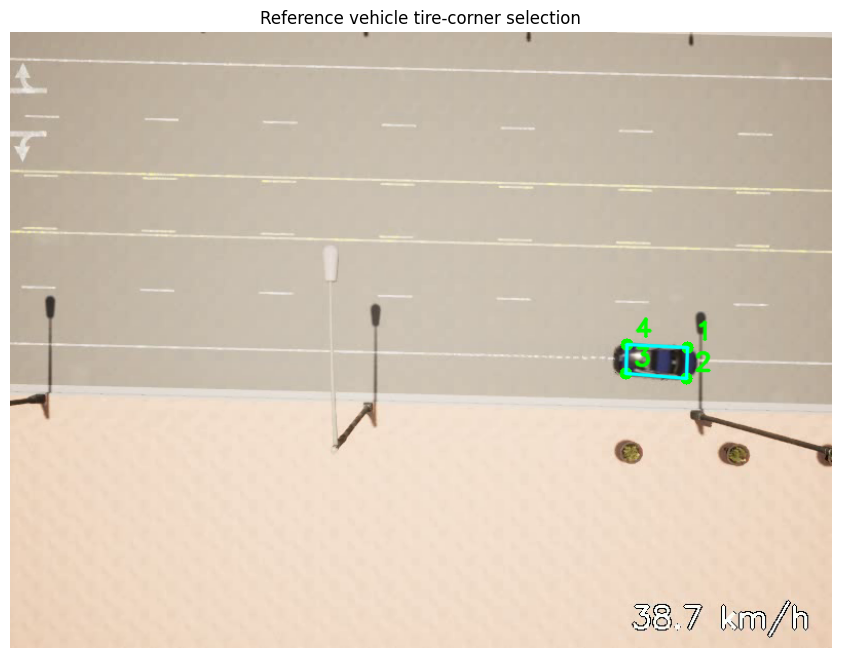

In [6]:
# ============================================================
# Cell 6: Manual corner picking on the reference vehicle
# Purpose:
# - click the 4 road-plane corners of ONE reference vehicle
# - store them in a consistent order
# - visualize the selected points for homography
#
# Click order (important):
#   1. front-left tire location
#   2. front-right tire location
#   3. rear-right tire location
#   4. rear-left tire location
#
# Notes:
# - click the vehicle footprint on the road plane
# - use the bottom outline where the tires/body meet the road
# - if the exact tire contact patch is not visible, click the best visible approximation
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

assert "CALIBRATION_FRAME_BGR" in globals(), "Run Cell 5 first."

# -----------------------------
# 1) Config
# -----------------------------
REFERENCE_CLASS_NAME = "Car"
CLICK_WINDOW_NAME = "Cell 6 - Click 4 tire-corner locations"
POINT_RADIUS = 6
LINE_THICKNESS = 2
TEXT_SCALE = 0.8

# Global storage for mouse callback
clicked_points = []
display_img = CALIBRATION_FRAME_BGR.copy()

# -----------------------------
# 2) Mouse callback
# -----------------------------
def mouse_callback(event, x, y, flags, param):
    global clicked_points, display_img

    if event == cv2.EVENT_LBUTTONDOWN and len(clicked_points) < 4:
        clicked_points.append((x, y))

        # Draw point
        cv2.circle(display_img, (x, y), POINT_RADIUS, (0, 255, 0), -1)

        # Draw index label
        label = str(len(clicked_points))
        cv2.putText(
            display_img,
            label,
            (x + 8, y - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            TEXT_SCALE,
            (0, 255, 0),
            2,
            cv2.LINE_AA,
        )

        # Draw line from previous point
        if len(clicked_points) > 1:
            cv2.line(
                display_img,
                clicked_points[-2],
                clicked_points[-1],
                (255, 255, 0),
                LINE_THICKNESS,
                cv2.LINE_AA,
            )

        # Close polygon after 4th point
        if len(clicked_points) == 4:
            cv2.line(
                display_img,
                clicked_points[-1],
                clicked_points[0],
                (255, 255, 0),
                LINE_THICKNESS,
                cv2.LINE_AA,
            )

# -----------------------------
# 3) Instructions
# -----------------------------
print("=== Cell 6: Manual Corner Picking ===")
print("Click the 4 tire-corner locations of ONE reference vehicle in this order:")
print("  1. front-left tire location")
print("  2. front-right tire location")
print("  3. rear-right tire location")
print("  4. rear-left tire location")
print("")
print("Use the vehicle footprint on the ROAD plane.")
print("If the tire contact points are not perfectly visible,")
print("click the best visible approximation where the vehicle meets the road.")
print("")
print("Controls:")
print("  - Left click: add point")
print("  - r: reset points")
print("  - q: finish after 4 points")
print("=====================================")

# -----------------------------
# 4) Interactive point picking
# -----------------------------
cv2.namedWindow(CLICK_WINDOW_NAME, cv2.WINDOW_NORMAL)
cv2.resizeWindow(CLICK_WINDOW_NAME, 1100, 800)
cv2.setMouseCallback(CLICK_WINDOW_NAME, mouse_callback)

while True:
    cv2.imshow(CLICK_WINDOW_NAME, display_img)
    key = cv2.waitKey(20) & 0xFF

    if key == ord("r"):
        clicked_points = []
        display_img = CALIBRATION_FRAME_BGR.copy()
        print("Points reset. Click again.")

    elif key == ord("q"):
        if len(clicked_points) == 4:
            break
        print(f"You have selected {len(clicked_points)} point(s). Please select exactly 4.")

cv2.destroyAllWindows()

# -----------------------------
# 5) Save points in numpy format
# -----------------------------
assert len(clicked_points) == 4, f"Expected 4 points, got {len(clicked_points)}"

REFERENCE_VEHICLE_IMAGE_POINTS = np.array(clicked_points, dtype=np.float32)

print("\nSelected image points:")
print("  1 = front-left tire location")
print("  2 = front-right tire location")
print("  3 = rear-right tire location")
print("  4 = rear-left tire location")
for i, (x, y) in enumerate(REFERENCE_VEHICLE_IMAGE_POINTS, start=1):
    print(f"  Point {i}: ({x:.1f}, {y:.1f})")

# -----------------------------
# 6) Visual confirmation in matplotlib
# -----------------------------
preview_bgr = CALIBRATION_FRAME_BGR.copy()

for i, (x, y) in enumerate(REFERENCE_VEHICLE_IMAGE_POINTS.astype(int), start=1):
    cv2.circle(preview_bgr, (x, y), POINT_RADIUS, (0, 255, 0), -1)
    cv2.putText(
        preview_bgr,
        str(i),
        (x + 8, y - 8),
        cv2.FONT_HERSHEY_SIMPLEX,
        TEXT_SCALE,
        (0, 255, 0),
        2,
        cv2.LINE_AA,
    )

pts_int = REFERENCE_VEHICLE_IMAGE_POINTS.astype(int)
for i in range(4):
    p1 = tuple(pts_int[i])
    p2 = tuple(pts_int[(i + 1) % 4])
    cv2.line(preview_bgr, p1, p2, (255, 255, 0), LINE_THICKNESS, cv2.LINE_AA)

REFERENCE_VEHICLE_PREVIEW_BGR = preview_bgr.copy()
REFERENCE_VEHICLE_PREVIEW_RGB = cv2.cvtColor(preview_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(REFERENCE_VEHICLE_PREVIEW_RGB)
plt.title("Reference vehicle tire-corner selection")
plt.axis("off")
plt.show()

In [7]:
# ============================================================
# Cell 7: Define assumed real-world dimensions for reference vehicle
# Purpose:
# - assign real-world dimensions to the clicked reference vehicle
# - build the destination rectangle in metric ground-plane coordinates
# - keep everything ready for homography estimation in Cell 8
#
# Point order from Cell 6:
#   1. front-left tire location
#   2. front-right tire location
#   3. rear-right tire location
#   4. rear-left tire location
# ============================================================

import numpy as np

assert "REFERENCE_VEHICLE_IMAGE_POINTS" in globals(), "Run Cell 6 first."

# -----------------------------
# 1) Assumed reference dimensions (meters)
# -----------------------------
# Paper 1 uses average passenger-vehicle dimensions as the metric reference
# These are reasonable starting values for an average sedan/passenger car
REFERENCE_VEHICLE_WIDTH_M  = 2.16
REFERENCE_VEHICLE_LENGTH_M = 4.79

# Optional descriptive label
REFERENCE_VEHICLE_TYPE = "passenger_car"

# -----------------------------
# 2) Build destination rectangle in ground-plane coordinates
# -----------------------------
# We define a local 2D road-plane coordinate system in meters:
#
#   x-axis = vehicle width direction
#   y-axis = vehicle length direction
#
# The reference rectangle is placed with rear-left at y=0 and front edge at y=length
#
# IMPORTANT:
# This destination point order must match the image-point order:
#   1. front-left tire location
#   2. front-right tire location
#   3. rear-right tire location
#   4. rear-left tire location
#
REFERENCE_VEHICLE_WORLD_POINTS = np.array([
    [0.0,                        REFERENCE_VEHICLE_LENGTH_M],  # front-left
    [REFERENCE_VEHICLE_WIDTH_M,  REFERENCE_VEHICLE_LENGTH_M],  # front-right
    [REFERENCE_VEHICLE_WIDTH_M,  0.0],                         # rear-right
    [0.0,                        0.0],                         # rear-left
], dtype=np.float32)

# -----------------------------
# 3) Quick geometric sanity checks
# -----------------------------
img_pts = REFERENCE_VEHICLE_IMAGE_POINTS.astype(np.float32)
world_pts = REFERENCE_VEHICLE_WORLD_POINTS.astype(np.float32)

print("=== Cell 7: Reference Vehicle Dimensions ===")
print("Reference vehicle type :", REFERENCE_VEHICLE_TYPE)
print(f"Assumed width  (m)     : {REFERENCE_VEHICLE_WIDTH_M:.3f}")
print(f"Assumed length (m)     : {REFERENCE_VEHICLE_LENGTH_M:.3f}")
print("")

print("Image points from Cell 6 (pixels):")
for i, (x, y) in enumerate(img_pts, start=1):
    print(f"  Point {i}: ({x:.1f}, {y:.1f})")

print("")
print("Destination world points (meters):")
for i, (x, y) in enumerate(world_pts, start=1):
    print(f"  Point {i}: ({x:.3f}, {y:.3f})")

# -----------------------------
# 4) Store useful derived values
# -----------------------------
REFERENCE_VEHICLE_DIMENSIONS = {
    "type": REFERENCE_VEHICLE_TYPE,
    "width_m": float(REFERENCE_VEHICLE_WIDTH_M),
    "length_m": float(REFERENCE_VEHICLE_LENGTH_M),
}

# Approximate pixel side lengths on the selected quadrilateral
def euclidean(p1, p2):
    return float(np.linalg.norm(np.asarray(p1, dtype=np.float32) - np.asarray(p2, dtype=np.float32)))

REFERENCE_IMAGE_SIDE_LENGTHS = {
    "front_edge_px": euclidean(img_pts[0], img_pts[1]),
    "right_edge_px": euclidean(img_pts[1], img_pts[2]),
    "rear_edge_px":  euclidean(img_pts[2], img_pts[3]),
    "left_edge_px":  euclidean(img_pts[3], img_pts[0]),
}

print("")
print("Approximate image-side lengths (pixels):")
for k, v in REFERENCE_IMAGE_SIDE_LENGTHS.items():
    print(f"  {k:15s}: {v:.2f}")

print("")
print("Outputs created for Cell 8:")
print("  - REFERENCE_VEHICLE_IMAGE_POINTS")
print("  - REFERENCE_VEHICLE_WORLD_POINTS")
print("  - REFERENCE_VEHICLE_DIMENSIONS")
print("==========================================")

=== Cell 7: Reference Vehicle Dimensions ===
Reference vehicle type : passenger_car
Assumed width  (m)     : 2.160
Assumed length (m)     : 4.790

Image points from Cell 6 (pixels):
  Point 1: (659.0, 307.0)
  Point 2: (658.0, 337.0)
  Point 3: (599.0, 332.0)
  Point 4: (600.0, 304.0)

Destination world points (meters):
  Point 1: (0.000, 4.790)
  Point 2: (2.160, 4.790)
  Point 3: (2.160, 0.000)
  Point 4: (0.000, 0.000)

Approximate image-side lengths (pixels):
  front_edge_px  : 30.02
  right_edge_px  : 59.21
  rear_edge_px   : 28.02
  left_edge_px   : 59.08

Outputs created for Cell 8:
  - REFERENCE_VEHICLE_IMAGE_POINTS
  - REFERENCE_VEHICLE_WORLD_POINTS
  - REFERENCE_VEHICLE_DIMENSIONS


=== Cell 8: Homography Computation ===
H_IMG_TO_WORLD:
[[-1.54913266e-02  3.04662757e-01 -8.33226820e+01]
 [ 3.43078396e-01  1.22527999e-02 -2.09571889e+02]
 [ 4.75339680e-03  3.28972941e-04  1.00000000e+00]]

H_WORLD_TO_IMG:
[[-1.96206534e-01  8.02438517e-01  1.51820101e+02]
 [ 3.23624336e+00 -9.19638094e-01  7.69221844e+01]
 [-1.31988985e-04 -3.51177263e-03  2.53033501e-01]]

Image points projected into world space:
  Point 1: (0.0000, 4.7900) m | target=(0.0000, 4.7900)
  Point 2: (2.1600, 4.7900) m | target=(2.1600, 4.7900)
  Point 3: (2.1600, 0.0000) m | target=(2.1600, 0.0000)
  Point 4: (0.0000, 0.0000) m | target=(0.0000, 0.0000)

World-space corner errors (meters):
  Point 1: 0.00000000
  Point 2: 0.00000000
  Point 3: 0.00000000
  Point 4: 0.00000000

World points reprojected into image space:
  Point 1: (659.0000, 307.0000) px | target=(659.0000, 307.0000)
  Point 2: (658.0000, 337.0000) px | target=(658.0000, 337.0000)
  Point 3: (599.0000, 332.0000) px | target=(599.0000, 

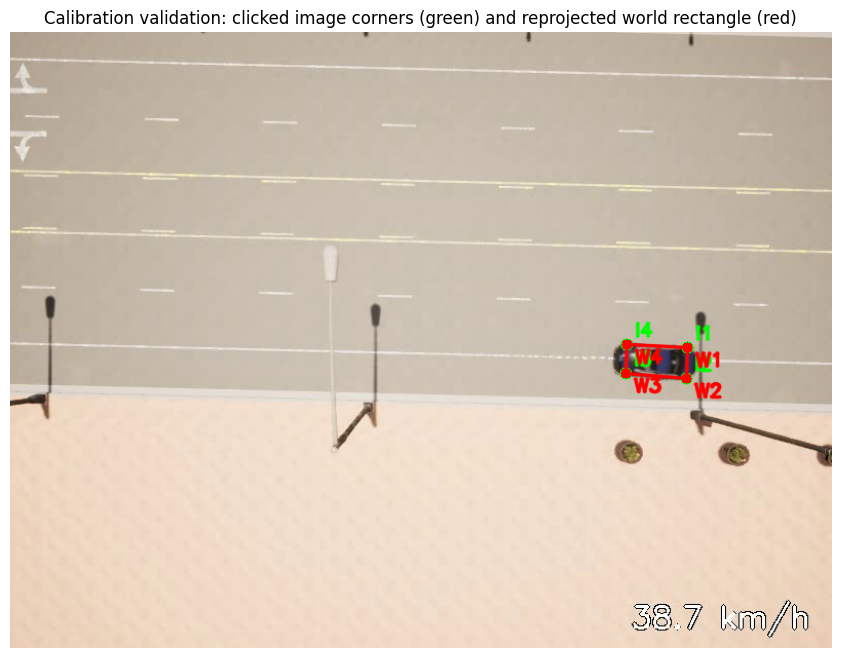

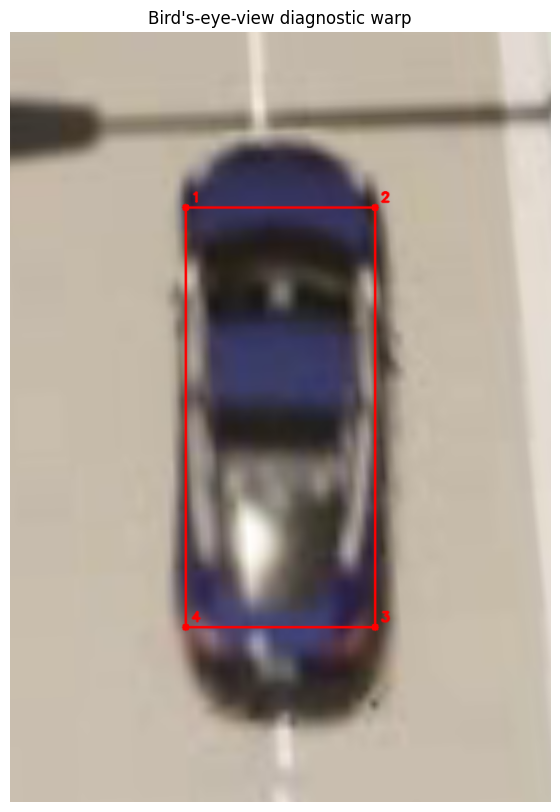


Saved validation overlay to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\homography_validation_overlay_frame_135.jpg
Saved BEV diagnostic to    : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\homography_bev_diagnostic_frame_135.jpg

Interpretation guide:
- Green points are your clicked image points.
- Red points/box are the world rectangle projected back into the image.
- In this 4-point setup, reprojection error should be near zero.
- The BEV diagnostic is more important: it should look geometrically plausible.
- If the BEV looks badly skewed or unrealistic, redo Cell 6 with better road-contact points.

Outputs created for later cells:
  - HOMOGRAPHY_IMG_TO_WORLD / H_IMG_TO_WORLD
  - HOMOGRAPHY_WORLD_TO_IMG / H_WORLD_TO_IMG
  - project_points_homography()
  - project_point_homography()


In [8]:
# ============================================================
# Cell 8: Compute homography and validate calibration
# Purpose:
# - estimate image -> ground-plane homography from the reference vehicle
# - estimate inverse homography (ground-plane -> image)
# - validate the mapping numerically and visually
# - create helpers for projecting points between spaces
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

assert "REFERENCE_VEHICLE_IMAGE_POINTS" in globals(), "Run Cell 6 first."
assert "REFERENCE_VEHICLE_WORLD_POINTS" in globals(), "Run Cell 7 first."
assert "CALIBRATION_FRAME_BGR" in globals(), "Run Cell 5 first."

# -----------------------------
# 1) Compute homography
# -----------------------------
img_pts = REFERENCE_VEHICLE_IMAGE_POINTS.astype(np.float32)
world_pts = REFERENCE_VEHICLE_WORLD_POINTS.astype(np.float32)

H_IMG_TO_WORLD = cv2.getPerspectiveTransform(img_pts, world_pts)
H_WORLD_TO_IMG = np.linalg.inv(H_IMG_TO_WORLD)

print("=== Cell 8: Homography Computation ===")
print("H_IMG_TO_WORLD:")
print(H_IMG_TO_WORLD)
print("")
print("H_WORLD_TO_IMG:")
print(H_WORLD_TO_IMG)
print("======================================")

# -----------------------------
# 2) Helper functions
# -----------------------------
def project_points_homography(points_xy, H):
    """
    Project Nx2 points through homography H.
    Input:
        points_xy : array-like of shape (N, 2)
        H         : 3x3 homography
    Returns:
        projected : np.ndarray of shape (N, 2)
    """
    pts = np.asarray(points_xy, dtype=np.float32).reshape(-1, 1, 2)
    warped = cv2.perspectiveTransform(pts, H)
    return warped.reshape(-1, 2)

def project_point_homography(point_xy, H):
    """
    Project a single 2D point through homography H.
    """
    return project_points_homography([point_xy], H)[0]

# Store helpers globally for later cells
HOMOGRAPHY_IMG_TO_WORLD = H_IMG_TO_WORLD.copy()
HOMOGRAPHY_WORLD_TO_IMG = H_WORLD_TO_IMG.copy()

# -----------------------------
# 3) Numerical validation:
#    image -> world should recover the destination rectangle
# -----------------------------
projected_world_from_image = project_points_homography(img_pts, H_IMG_TO_WORLD)
reprojection_image_from_world = project_points_homography(world_pts, H_WORLD_TO_IMG)

world_errors = np.linalg.norm(projected_world_from_image - world_pts, axis=1)
image_errors = np.linalg.norm(reprojection_image_from_world - img_pts, axis=1)

print("\nImage points projected into world space:")
for i, p in enumerate(projected_world_from_image, start=1):
    print(f"  Point {i}: ({p[0]:.4f}, {p[1]:.4f}) m | target=({world_pts[i-1,0]:.4f}, {world_pts[i-1,1]:.4f})")

print("\nWorld-space corner errors (meters):")
for i, e in enumerate(world_errors, start=1):
    print(f"  Point {i}: {e:.8f}")

print("\nWorld points reprojected into image space:")
for i, p in enumerate(reprojection_image_from_world, start=1):
    print(f"  Point {i}: ({p[0]:.4f}, {p[1]:.4f}) px | target=({img_pts[i-1,0]:.4f}, {img_pts[i-1,1]:.4f})")

print("\nImage-space reprojection errors (pixels):")
for i, e in enumerate(image_errors, start=1):
    print(f"  Point {i}: {e:.8f}")

# -----------------------------
# 4) Visual validation on image:
#    reproject the world rectangle back onto the frame
# -----------------------------
overlay_bgr = CALIBRATION_FRAME_BGR.copy()

# Draw original clicked image points in green
for i, (x, y) in enumerate(img_pts.astype(int), start=1):
    cv2.circle(overlay_bgr, (x, y), 6, (0, 255, 0), -1)
    cv2.putText(
        overlay_bgr,
        f"I{i}",
        (x + 8, y - 8),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2,
        cv2.LINE_AA,
    )

# Draw reprojected world rectangle in red
reproj_int = np.round(reprojection_image_from_world).astype(int)
for i, (x, y) in enumerate(reproj_int, start=1):
    cv2.circle(overlay_bgr, (x, y), 5, (0, 0, 255), -1)
    cv2.putText(
        overlay_bgr,
        f"W{i}",
        (x + 8, y + 18),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2,
        cv2.LINE_AA,
    )

for i in range(4):
    p1 = tuple(reproj_int[i])
    p2 = tuple(reproj_int[(i + 1) % 4])
    cv2.line(overlay_bgr, p1, p2, (0, 0, 255), 2, cv2.LINE_AA)

overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(overlay_rgb)
plt.title("Calibration validation: clicked image corners (green) and reprojected world rectangle (red)")
plt.axis("off")
plt.show()

# -----------------------------
# 5) Bird's-eye-view style diagnostic
#    Warp the whole image into a metric canvas
# -----------------------------
# We create a top-down canvas in pixels, where 1 meter = BEV_PIXELS_PER_METER
BEV_PIXELS_PER_METER = 120
BEV_MARGIN_M = 2.0

world_w_m = float(REFERENCE_VEHICLE_DIMENSIONS["width_m"] + 2 * BEV_MARGIN_M)
world_h_m = float(REFERENCE_VEHICLE_DIMENSIONS["length_m"] + 2 * BEV_MARGIN_M)

bev_w = int(np.ceil(world_w_m * BEV_PIXELS_PER_METER))
bev_h = int(np.ceil(world_h_m * BEV_PIXELS_PER_METER))

# Shift world coordinates so the vehicle rectangle sits inside the canvas margin
T_world_to_bev = np.array([
    [BEV_PIXELS_PER_METER, 0, BEV_MARGIN_M * BEV_PIXELS_PER_METER],
    [0, -BEV_PIXELS_PER_METER, (REFERENCE_VEHICLE_DIMENSIONS["length_m"] + BEV_MARGIN_M) * BEV_PIXELS_PER_METER],
    [0, 0, 1]
], dtype=np.float64)

H_IMG_TO_BEV = T_world_to_bev @ H_IMG_TO_WORLD
BEV_WARP = cv2.warpPerspective(CALIBRATION_FRAME_BGR, H_IMG_TO_BEV, (bev_w, bev_h))
BEV_WARP_RGB = cv2.cvtColor(BEV_WARP, cv2.COLOR_BGR2RGB)

# Draw the reference rectangle on BEV image for visual sanity
bev_overlay = BEV_WARP_RGB.copy()
world_rect_for_bev = world_pts.copy()
world_rect_h = np.concatenate([world_rect_for_bev, np.ones((4, 1), dtype=np.float32)], axis=1)
bev_pts_h = (T_world_to_bev @ world_rect_h.T).T
bev_pts = bev_pts_h[:, :2] / bev_pts_h[:, 2:3]
bev_pts_int = np.round(bev_pts).astype(int)

for i, (x, y) in enumerate(bev_pts_int, start=1):
    cv2.circle(bev_overlay, (x, y), 5, (255, 0, 0), -1)
    cv2.putText(
        bev_overlay,
        str(i),
        (x + 8, y - 8),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2,
        cv2.LINE_AA,
    )

for i in range(4):
    p1 = tuple(bev_pts_int[i])
    p2 = tuple(bev_pts_int[(i + 1) % 4])
    cv2.line(bev_overlay, p1, p2, (255, 0, 0), 2, cv2.LINE_AA)

plt.figure(figsize=(8, 10))
plt.imshow(bev_overlay)
plt.title("Bird's-eye-view diagnostic warp")
plt.axis("off")
plt.show()

# -----------------------------
# 6) Save diagnostics
# -----------------------------
HOMOGRAPHY_VALIDATION_OVERLAY_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / f"homography_validation_overlay_frame_{CALIBRATION_FRAME_IDX}.jpg"
BEV_DIAGNOSTIC_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / f"homography_bev_diagnostic_frame_{CALIBRATION_FRAME_IDX}.jpg"

cv2.imwrite(str(HOMOGRAPHY_VALIDATION_OVERLAY_PATH), cv2.cvtColor(overlay_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(BEV_DIAGNOSTIC_PATH), cv2.cvtColor(bev_overlay, cv2.COLOR_RGB2BGR))

print("\nSaved validation overlay to:", HOMOGRAPHY_VALIDATION_OVERLAY_PATH)
print("Saved BEV diagnostic to    :", BEV_DIAGNOSTIC_PATH)

# -----------------------------
# 7) Simple interpretation note
# -----------------------------
print("\nInterpretation guide:")
print("- Green points are your clicked image points.")
print("- Red points/box are the world rectangle projected back into the image.")
print("- In this 4-point setup, reprojection error should be near zero.")
print("- The BEV diagnostic is more important: it should look geometrically plausible.")
print("- If the BEV looks badly skewed or unrealistic, redo Cell 6 with better road-contact points.")

# Outputs for later cells
print("\nOutputs created for later cells:")
print("  - HOMOGRAPHY_IMG_TO_WORLD / H_IMG_TO_WORLD")
print("  - HOMOGRAPHY_WORLD_TO_IMG / H_WORLD_TO_IMG")
print("  - project_points_homography()")
print("  - project_point_homography()")

In [9]:
# ============================================================
# Cell 9: Geometry + speed helper functions
# Purpose:
# - define reusable helpers for speed estimation
# - convert boxes -> representative points
# - reject unstable border-region boxes
# - project image points -> world points
# - compute displacement, time, and speed
# ============================================================

import cv2
import numpy as np

assert "HOMOGRAPHY_IMG_TO_WORLD" in globals(), "Run Cell 8 first."

# -----------------------------
# 1) Core configuration
# -----------------------------
SPEED_ESTIMATION_CLASS_IDS = {3, 4, 5, 6}

MIN_TRACK_HISTORY_FOR_SPEED = 2
DEFAULT_SPEED_WINDOW = 5
MAX_REASONABLE_SPEED_KMH = 250.0
MIN_REASONABLE_SPEED_KMH = 0.0

# Representative-point mode:
#   "bottom_center" -> closer to Paper 1
#   "center"        -> better for top-down / bird's-eye video
REPRESENTATIVE_POINT_MODE = "center"

BOTTOM_CENTER_Y_OFFSET_PX = 0.0

# Border exclusion settings
BORDER_MARGIN_PX = 20

# -----------------------------
# 2) Bounding-box geometry
# -----------------------------
def bbox_bottom_center_xyxy(box_xyxy, y_offset_px=0.0):
    x1, y1, x2, y2 = map(float, box_xyxy)
    cx = 0.5 * (x1 + x2)
    cy = y2 + float(y_offset_px)
    return np.array([cx, cy], dtype=np.float32)

def bbox_center_xyxy(box_xyxy):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return np.array([(x1 + x2) / 2.0, (y1 + y2) / 2.0], dtype=np.float32)

def bbox_area_xyxy(box_xyxy):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return max(0.0, x2 - x1) * max(0.0, y2 - y1)

def bbox_touches_border(box_xyxy, image_width, image_height, margin_px=BORDER_MARGIN_PX):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return (
        x1 <= margin_px or
        y1 <= margin_px or
        x2 >= (image_width - margin_px) or
        y2 >= (image_height - margin_px)
    )

def representative_point_xyxy(box_xyxy, mode=REPRESENTATIVE_POINT_MODE):
    if mode == "center":
        return bbox_center_xyxy(box_xyxy)
    elif mode == "bottom_center":
        return bbox_bottom_center_xyxy(box_xyxy, y_offset_px=BOTTOM_CENTER_Y_OFFSET_PX)
    else:
        raise ValueError(f"Unsupported REPRESENTATIVE_POINT_MODE={mode}")

# -----------------------------
# 3) Homography projection
# -----------------------------
def image_to_world_point(point_xy, H=None):
    if H is None:
        H = HOMOGRAPHY_IMG_TO_WORLD
    point_xy = np.asarray(point_xy, dtype=np.float32).reshape(1, 1, 2)
    world_xy = cv2.perspectiveTransform(point_xy, H).reshape(2)
    return world_xy.astype(np.float32)

def image_to_world_points(points_xy, H=None):
    if H is None:
        H = HOMOGRAPHY_IMG_TO_WORLD
    pts = np.asarray(points_xy, dtype=np.float32).reshape(-1, 1, 2)
    world_xy = cv2.perspectiveTransform(pts, H).reshape(-1, 2)
    return world_xy.astype(np.float32)

# -----------------------------
# 4) Distance / time / speed
# -----------------------------
def euclidean_distance_m(p1_world, p2_world):
    p1 = np.asarray(p1_world, dtype=np.float32)
    p2 = np.asarray(p2_world, dtype=np.float32)
    return float(np.linalg.norm(p2 - p1))

def frames_to_seconds(frame_delta, fps):
    fps = float(fps)
    if fps <= 0:
        raise ValueError(f"Invalid fps={fps}")
    return float(frame_delta) / fps

def speed_mps_from_positions(p1_world, p2_world, frame_delta, fps):
    dt = frames_to_seconds(frame_delta, fps)
    if dt <= 0:
        return None
    dist_m = euclidean_distance_m(p1_world, p2_world)
    return dist_m / dt

def mps_to_kmh(speed_mps):
    if speed_mps is None:
        return None
    return float(speed_mps) * 3.6

def kmh_to_mps(speed_kmh):
    return float(speed_kmh) / 3.6

def speed_kmh_from_positions(p1_world, p2_world, frame_delta, fps):
    speed_mps = speed_mps_from_positions(p1_world, p2_world, frame_delta, fps)
    if speed_mps is None:
        return None
    return mps_to_kmh(speed_mps)

# -----------------------------
# 5) Simple smoothing / filtering
# -----------------------------
def is_reasonable_speed_kmh(speed_kmh,
                            min_kmh=MIN_REASONABLE_SPEED_KMH,
                            max_kmh=MAX_REASONABLE_SPEED_KMH):
    if speed_kmh is None:
        return False
    return float(min_kmh) <= float(speed_kmh) <= float(max_kmh)

def moving_average(values, window=DEFAULT_SPEED_WINDOW):
    valid = [float(v) for v in values if v is not None]
    if len(valid) == 0:
        return None
    valid = valid[-int(window):]
    return float(np.mean(valid))

# -----------------------------
# 6) Track-history initialization helpers
# -----------------------------
def make_empty_track_history(speed_window=DEFAULT_SPEED_WINDOW):
    return {
        "frames": [],
        "image_points": [],
        "world_points": [],
        "raw_speeds_kmh": [],
        "smoothed_speeds_kmh": [],
        "last_box": None,
        "class_id": None,
        "confidence": None,
        "speed_window": int(speed_window),
    }

def append_track_observation(track_history, frame_idx, box_xyxy, class_id, confidence, fps):
    img_pt = representative_point_xyxy(box_xyxy, mode=REPRESENTATIVE_POINT_MODE)
    world_pt = image_to_world_point(img_pt)

    track_history["frames"].append(int(frame_idx))
    track_history["image_points"].append(img_pt)
    track_history["world_points"].append(world_pt)
    track_history["last_box"] = np.asarray(box_xyxy, dtype=np.float32)
    track_history["class_id"] = int(class_id) if class_id is not None else None
    track_history["confidence"] = float(confidence) if confidence is not None else None

    raw_speed_kmh = None
    if len(track_history["world_points"]) >= 2:
        p1 = track_history["world_points"][-2]
        p2 = track_history["world_points"][-1]
        f1 = track_history["frames"][-2]
        f2 = track_history["frames"][-1]
        frame_delta = f2 - f1

        raw_speed_kmh = speed_kmh_from_positions(p1, p2, frame_delta, fps)
        if raw_speed_kmh is not None and not is_reasonable_speed_kmh(raw_speed_kmh):
            raw_speed_kmh = None

    track_history["raw_speeds_kmh"].append(raw_speed_kmh)

    smoothed_speed_kmh = moving_average(
        track_history["raw_speeds_kmh"],
        window=track_history["speed_window"]
    )
    track_history["smoothed_speeds_kmh"].append(smoothed_speed_kmh)

    return track_history

def latest_speed_kmh(track_history, smoothed=True):
    key = "smoothed_speeds_kmh" if smoothed else "raw_speeds_kmh"
    if len(track_history[key]) == 0:
        return None
    return track_history[key][-1]

# -----------------------------
# 7) Quick sanity check
# -----------------------------
ref_img_pts = REFERENCE_VEHICLE_IMAGE_POINTS.copy()
ref_world_pts = image_to_world_points(ref_img_pts)

print("=== Cell 9: Helper Functions Ready ===")
print("Eligible class IDs for speed :", SPEED_ESTIMATION_CLASS_IDS)
print("Representative point mode    :", REPRESENTATIVE_POINT_MODE)
print("Border margin (px)           :", BORDER_MARGIN_PX)
print("Default smoothing window     :", DEFAULT_SPEED_WINDOW)
print("Max reasonable speed (km/h)  :", MAX_REASONABLE_SPEED_KMH)
print("")

print("Reference image points projected into world plane:")
for i, p in enumerate(ref_world_pts, start=1):
    print(f"  Point {i}: ({p[0]:.4f}, {p[1]:.4f}) m")

print("")
print("Created helpers:")
print("  - representative_point_xyxy()")
print("  - bbox_touches_border()")
print("  - image_to_world_point() / image_to_world_points()")
print("  - euclidean_distance_m()")
print("  - speed_mps_from_positions() / speed_kmh_from_positions()")
print("  - moving_average()")
print("  - make_empty_track_history()")
print("  - append_track_observation()")
print("  - latest_speed_kmh()")
print("======================================")

=== Cell 9: Helper Functions Ready ===
Eligible class IDs for speed : {3, 4, 5, 6}
Representative point mode    : center
Border margin (px)           : 20
Default smoothing window     : 5
Max reasonable speed (km/h)  : 250.0

Reference image points projected into world plane:
  Point 1: (0.0000, 4.7900) m
  Point 2: (2.1600, 4.7900) m
  Point 3: (2.1600, 0.0000) m
  Point 4: (0.0000, 0.0000) m

Created helpers:
  - representative_point_xyxy()
  - bbox_touches_border()
  - image_to_world_point() / image_to_world_points()
  - euclidean_distance_m()
  - speed_mps_from_positions() / speed_kmh_from_positions()
  - moving_average()
  - make_empty_track_history()
  - append_track_observation()
  - latest_speed_kmh()


In [10]:
# ============================================================
# Cell 10: Initialize per-track trajectory and speed state
# Purpose:
# - create persistent storage for each tracked object
# - keep image-space points, world-space points, and speed history
# - prepare reusable state for the speed-estimation loop
# ============================================================

from collections import defaultdict

assert "make_empty_track_history" in globals(), "Run Cell 9 first."

# -----------------------------
# 1) Track-history configuration
# -----------------------------
# Minimum number of observations before a track is considered mature enough
# to trust more for speed reporting.
MIN_TRACK_OBSERVATIONS = 3

# If a track disappears for too long, we can later decide to ignore or archive it
MAX_MISSING_FRAMES = 15

# Keep a registry for active and finished tracks
TRACK_HISTORIES = {}
FINISHED_TRACK_HISTORIES = {}

# Optional bookkeeping for last-seen frame
TRACK_LAST_SEEN_FRAME = {}

# Optional per-track status flags
TRACK_STATUS = defaultdict(lambda: {
    "is_active": True,
    "num_missing_frames": 0,
    "num_observations": 0,
    "has_valid_speed": False,
})

# -----------------------------
# 2) Helper: get/create history for a track
# -----------------------------
def get_or_create_track_history(track_id, speed_window=DEFAULT_SPEED_WINDOW):
    """
    Return an existing track history or create a new one.
    """
    track_id = int(track_id)
    if track_id not in TRACK_HISTORIES:
        TRACK_HISTORIES[track_id] = make_empty_track_history(speed_window=speed_window)
    return TRACK_HISTORIES[track_id]

# -----------------------------
# 3) Helper: mark track observed on a frame
# -----------------------------
def mark_track_observed(track_id, frame_idx):
    """
    Update bookkeeping when a track is seen on the current frame.
    """
    track_id = int(track_id)
    frame_idx = int(frame_idx)

    TRACK_LAST_SEEN_FRAME[track_id] = frame_idx
    TRACK_STATUS[track_id]["is_active"] = True
    TRACK_STATUS[track_id]["num_missing_frames"] = 0

    if track_id in TRACK_HISTORIES:
        TRACK_STATUS[track_id]["num_observations"] = len(TRACK_HISTORIES[track_id]["frames"])

        latest_speed = latest_speed_kmh(TRACK_HISTORIES[track_id], smoothed=True)
        TRACK_STATUS[track_id]["has_valid_speed"] = latest_speed is not None

# -----------------------------
# 4) Helper: update missing-frame counts for unseen tracks
# -----------------------------
def update_missing_tracks(active_track_ids_this_frame, frame_idx, max_missing_frames=MAX_MISSING_FRAMES):
    """
    For any known track not seen on this frame:
    - increment missing-frame count
    - mark inactive if missing too long
    - optionally move to finished registry
    """
    active_track_ids_this_frame = set(int(t) for t in active_track_ids_this_frame)
    frame_idx = int(frame_idx)

    for track_id in list(TRACK_HISTORIES.keys()):
        if track_id not in active_track_ids_this_frame:
            last_seen = TRACK_LAST_SEEN_FRAME.get(track_id, None)

            if last_seen is None:
                TRACK_STATUS[track_id]["num_missing_frames"] += 1
            else:
                TRACK_STATUS[track_id]["num_missing_frames"] = frame_idx - last_seen

            if TRACK_STATUS[track_id]["num_missing_frames"] > max_missing_frames:
                TRACK_STATUS[track_id]["is_active"] = False

                # Move to finished registry if not already there
                if track_id not in FINISHED_TRACK_HISTORIES:
                    FINISHED_TRACK_HISTORIES[track_id] = TRACK_HISTORIES[track_id]

# -----------------------------
# 5) Helper: decide whether a track is ready for speed display
# -----------------------------
def track_ready_for_speed(track_id, min_track_observations=MIN_TRACK_OBSERVATIONS):
    """
    A track is ready if it has enough observations and a valid latest speed.
    """
    track_id = int(track_id)

    if track_id not in TRACK_HISTORIES:
        return False

    hist = TRACK_HISTORIES[track_id]
    if len(hist["frames"]) < int(min_track_observations):
        return False

    latest = latest_speed_kmh(hist, smoothed=True)
    return latest is not None

# -----------------------------
# 6) Helper: summary for one track
# -----------------------------
def summarize_track_state(track_id):
    """
    Return a compact dictionary summary for debugging/inspection.
    """
    track_id = int(track_id)
    hist = TRACK_HISTORIES.get(track_id, None)
    status = TRACK_STATUS.get(track_id, {})

    if hist is None:
        return {
            "track_id": track_id,
            "exists": False,
        }

    return {
        "track_id": track_id,
        "exists": True,
        "num_frames": len(hist["frames"]),
        "last_frame": hist["frames"][-1] if len(hist["frames"]) > 0 else None,
        "class_id": hist["class_id"],
        "confidence": hist["confidence"],
        "latest_raw_speed_kmh": latest_speed_kmh(hist, smoothed=False),
        "latest_smoothed_speed_kmh": latest_speed_kmh(hist, smoothed=True),
        "is_active": status.get("is_active", None),
        "num_missing_frames": status.get("num_missing_frames", None),
        "num_observations": status.get("num_observations", None),
        "has_valid_speed": status.get("has_valid_speed", None),
    }

# -----------------------------
# 7) Initialization confirmation
# -----------------------------
print("=== Cell 10: Track State Initialized ===")
print("MIN_TRACK_OBSERVATIONS :", MIN_TRACK_OBSERVATIONS)
print("MAX_MISSING_FRAMES     :", MAX_MISSING_FRAMES)
print("")
print("Created state containers:")
print("  - TRACK_HISTORIES")
print("  - FINISHED_TRACK_HISTORIES")
print("  - TRACK_LAST_SEEN_FRAME")
print("  - TRACK_STATUS")
print("")
print("Created helpers:")
print("  - get_or_create_track_history()")
print("  - mark_track_observed()")
print("  - update_missing_tracks()")
print("  - track_ready_for_speed()")
print("  - summarize_track_state()")
print("========================================")

=== Cell 10: Track State Initialized ===
MIN_TRACK_OBSERVATIONS : 3
MAX_MISSING_FRAMES     : 15

Created state containers:
  - TRACK_HISTORIES
  - FINISHED_TRACK_HISTORIES
  - TRACK_LAST_SEEN_FRAME
  - TRACK_STATUS

Created helpers:
  - get_or_create_track_history()
  - mark_track_observed()
  - update_missing_tracks()
  - track_ready_for_speed()
  - summarize_track_state()


In [13]:
# ============================================================
# Cell 11: Extend the main loop to collect per-track observations
# Purpose:
# - rerun detection + tracking
# - for each eligible active track, compute its representative point
# - reject border-touching boxes from speed updates
# - project valid points into world coordinates
# - update per-track trajectory/speed history
# ============================================================

from pathlib import Path
import cv2
import numpy as np
from tqdm.auto import tqdm

assert "TRACKER" in globals(), "Run Cell 3 first."
assert "TRACK_HISTORIES" in globals(), "Run Cell 10 first."
assert "append_track_observation" in globals(), "Run Cell 9 first."

VIDEO_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "carla_rgb_speeds.mp4"
OUTPUT_PATH_CELL11 = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "tracked_with_track_history_preview.mp4"

DETECT_EVERY_N = 1
DET_THRESHOLD  = 0.30
MIN_BOX_AREA   = 30 * 30

FPS = 30.0
CLASS_MAP = PHASE_CLASSES

cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"

fps = cap.get(cv2.CAP_PROP_FPS)
if fps is None or fps <= 1:
    fps = FPS
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("Input:", VIDEO_PATH)
print(f"Frames: {total_frames} | Size: {width}x{height} | FPS: {fps}")

try:
    if hasattr(TRACKER, "frame_rate"):
        TRACKER.frame_rate = int(round(fps))
except Exception:
    pass

if hasattr(TRACKER, "reset"):
    TRACKER.reset()

TRACK_HISTORIES.clear()
FINISHED_TRACK_HISTORIES.clear()
TRACK_LAST_SEEN_FRAME.clear()
TRACK_STATUS.clear()

track_meta = {}

def build_tensors_from_detections(detections: "sv.Detections") -> np.ndarray:
    if len(detections) == 0:
        return np.zeros((0, 5), dtype=np.float32)
    return np.hstack([
        detections.xyxy.astype(np.float32),
        detections.confidence.reshape(-1, 1).astype(np.float32),
    ])

def active_tracks_to_boxes_and_ids(tracker) -> tuple[list[np.ndarray], list[int]]:
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

OUTPUT_PATH_CELL11.parent.mkdir(parents=True, exist_ok=True)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_PATH_CELL11), fourcc, fps, (width, height))
assert writer.isOpened(), f"Could not open writer: {OUTPUT_PATH_CELL11}"

pbar = tqdm(total=total_frames, desc="Cell 11: collecting trajectories")

for frame_idx in range(total_frames):
    ok, frame_bgr = cap.read()
    if not ok:
        break

    if frame_idx % DETECT_EVERY_N == 0:
        temp_path = "temp_frame.jpg"
        cv2.imwrite(temp_path, frame_bgr)

        det = DETECTOR.predict(temp_path, threshold=DET_THRESHOLD)
        detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

        if len(detections) > 0:
            xyxy = detections.xyxy
            areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
            keep = areas >= MIN_BOX_AREA
            detections = detections[keep]

        tensors = build_tensors_from_detections(detections)
        _ = TRACKER.update_with_tensors(tensors)

        det_with_ids = TRACKER.update_with_detections(detections)
        if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
            for i in range(len(det_with_ids)):
                tid = int(det_with_ids.tracker_id[i])
                cls = int(det_with_ids.class_id[i])
                conf = float(det_with_ids.confidence[i])
                track_meta[tid] = (cls, conf)
    else:
        _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

    boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)
    active_ids_this_frame = set()

    for box, tid in zip(boxes, ids):
        active_ids_this_frame.add(int(tid))
        cls, conf = track_meta.get(tid, (-1, 0.0))

        if cls in SPEED_ESTIMATION_CLASS_IDS:
            touches_border = bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX)

            if not touches_border:
                hist = get_or_create_track_history(tid, speed_window=DEFAULT_SPEED_WINDOW)
                append_track_observation(
                    track_history=hist,
                    frame_idx=frame_idx,
                    box_xyxy=box,
                    class_id=cls,
                    confidence=conf,
                    fps=fps,
                )

        mark_track_observed(tid, frame_idx)

    update_missing_tracks(active_ids_this_frame, frame_idx, max_missing_frames=MAX_MISSING_FRAMES)

    out = frame_bgr.copy()

    for box, tid in zip(boxes, ids):
        x1, y1, x2, y2 = box.astype(int).tolist()
        cls, conf = track_meta.get(tid, (-1, 0.0))
        label = CLASS_MAP.get(cls, f"class_{cls}") if cls != -1 else "unknown"

        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)

        rep_pt = representative_point_xyxy(box, mode=REPRESENTATIVE_POINT_MODE)
        rep_x, rep_y = map(int, np.round(rep_pt))
        cv2.circle(out, (rep_x, rep_y), 4, (0, 0, 255), -1)

        if bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX):
            status_text = "BORDER"
        else:
            status_text = "OK"

        text = f"ID {tid}: {label} {conf:.2f} | {status_text}"
        cv2.putText(
            out,
            text,
            (x1, max(0, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA,
        )

        if tid in TRACK_HISTORIES and len(TRACK_HISTORIES[tid]["image_points"]) >= 2:
            pts = np.array(TRACK_HISTORIES[tid]["image_points"][-20:], dtype=np.float32)
            pts = np.round(pts).astype(int)
            for j in range(1, len(pts)):
                cv2.line(out, tuple(pts[j - 1]), tuple(pts[j]), (255, 0, 0), 2, cv2.LINE_AA)

    writer.write(out)
    pbar.update(1)

pbar.close()
cap.release()
writer.release()

print(f"\nDone. Saved trajectory preview video to: {OUTPUT_PATH_CELL11}")
print(f"Total tracks with histories: {len(TRACK_HISTORIES)}")

valid_track_ids = sorted(TRACK_HISTORIES.keys())

print("\nExample track summaries:")
for tid in valid_track_ids[:10]:
    print(summarize_track_state(tid))

Input: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\carla_rgb_speeds.mp4
Frames: 521 | Size: 800x600 | FPS: 20.0


Cell 11: collecting trajectories:   0%|          | 0/521 [00:00<?, ?it/s]


Done. Saved trajectory preview video to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\tracked_with_track_history_preview.mp4
Total tracks with histories: 1

Example track summaries:
{'track_id': 1, 'exists': True, 'num_frames': 486, 'last_frame': 520, 'class_id': 3, 'confidence': 0.9005581140518188, 'latest_raw_speed_kmh': 45.009737491607666, 'latest_smoothed_speed_kmh': 50.909764766693115, 'is_active': True, 'num_missing_frames': 0, 'num_observations': 486, 'has_valid_speed': True}


Tracks available for inspection: [1]


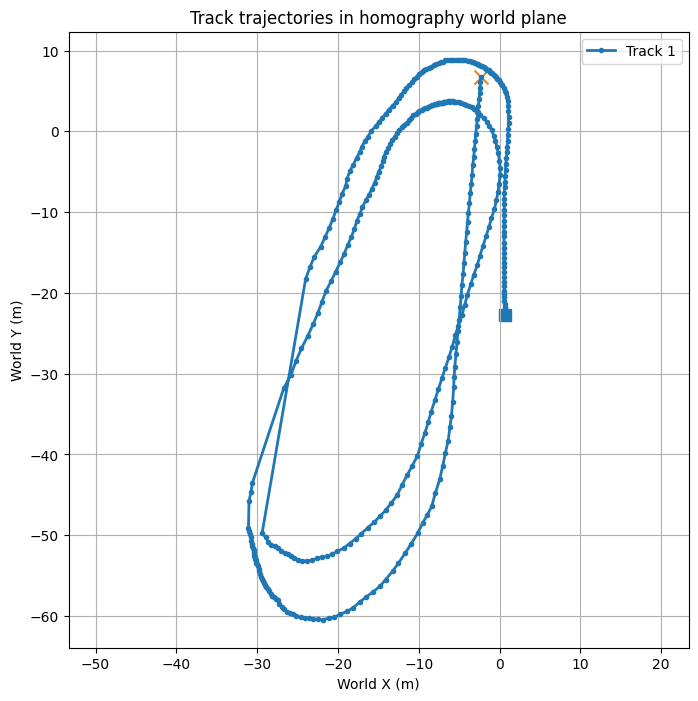

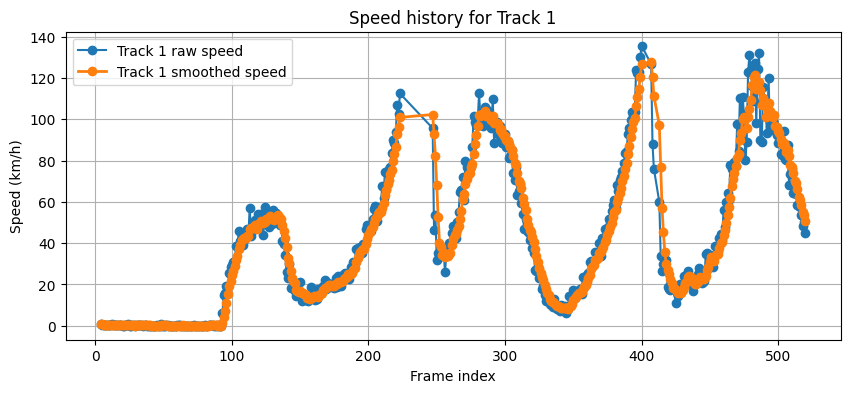


=== Track trajectory summaries ===

Track 1
  class_id              : 3
  num_points            : 486
  total_distance_m      : 327.825
  first_world_point     : [  0.6691204 -22.779873 ]
  last_world_point      : [-2.3183107  6.675011 ]
  mean_raw_speed_kmh    : 42.191
  mean_smooth_speed_kmh : 41.996
  max_raw_speed_kmh     : 135.663
  max_smooth_speed_kmh  : 127.572


In [14]:
# ============================================================
# Cell 12: Inspect projected world trajectories and per-track speeds
# Purpose:
# - visualize each track in world-plane coordinates
# - inspect raw and smoothed speed histories
# - confirm that the homography-based motion is sensible
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

assert "TRACK_HISTORIES" in globals(), "Run Cell 11 first."

# -----------------------------
# 1) Choose which tracks to inspect
# -----------------------------
# By default, inspect all tracks that have at least 2 world points
TRACK_IDS_TO_INSPECT = [
    tid for tid, hist in TRACK_HISTORIES.items()
    if len(hist["world_points"]) >= 2
]

print("Tracks available for inspection:", TRACK_IDS_TO_INSPECT)

# -----------------------------
# 2) Plot world-plane trajectories
# -----------------------------
plt.figure(figsize=(8, 8))

for tid in TRACK_IDS_TO_INSPECT:
    hist = TRACK_HISTORIES[tid]
    world_pts = np.asarray(hist["world_points"], dtype=np.float32)

    if len(world_pts) < 2:
        continue

    xs = world_pts[:, 0]
    ys = world_pts[:, 1]

    plt.plot(xs, ys, marker="o", markersize=3, linewidth=2, label=f"Track {tid}")
    plt.scatter(xs[0], ys[0], s=80, marker="s")
    plt.scatter(xs[-1], ys[-1], s=100, marker="x")

plt.xlabel("World X (m)")
plt.ylabel("World Y (m)")
plt.title("Track trajectories in homography world plane")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# 3) Plot speed histories
# -----------------------------
for tid in TRACK_IDS_TO_INSPECT:
    hist = TRACK_HISTORIES[tid]

    frames = np.asarray(hist["frames"], dtype=np.int32)
    raw_speeds = hist["raw_speeds_kmh"]
    smooth_speeds = hist["smoothed_speeds_kmh"]

    raw_x = []
    raw_y = []
    smooth_x = []
    smooth_y = []

    for f, s in zip(frames, raw_speeds):
        if s is not None:
            raw_x.append(f)
            raw_y.append(float(s))

    for f, s in zip(frames, smooth_speeds):
        if s is not None:
            smooth_x.append(f)
            smooth_y.append(float(s))

    plt.figure(figsize=(10, 4))
    if len(raw_x) > 0:
        plt.plot(raw_x, raw_y, marker="o", linewidth=1.5, label=f"Track {tid} raw speed")
    if len(smooth_x) > 0:
        plt.plot(smooth_x, smooth_y, marker="o", linewidth=2, label=f"Track {tid} smoothed speed")

    plt.xlabel("Frame index")
    plt.ylabel("Speed (km/h)")
    plt.title(f"Speed history for Track {tid}")
    plt.grid(True)
    plt.legend()
    plt.show()

# -----------------------------
# 4) Print compact numeric summaries
# -----------------------------
print("\n=== Track trajectory summaries ===")
for tid in TRACK_IDS_TO_INSPECT:
    hist = TRACK_HISTORIES[tid]
    world_pts = np.asarray(hist["world_points"], dtype=np.float32)

    total_distance_m = 0.0
    if len(world_pts) >= 2:
        diffs = world_pts[1:] - world_pts[:-1]
        step_dists = np.linalg.norm(diffs, axis=1)
        total_distance_m = float(step_dists.sum())

    valid_raw = [float(s) for s in hist["raw_speeds_kmh"] if s is not None]
    valid_smooth = [float(s) for s in hist["smoothed_speeds_kmh"] if s is not None]

    print(f"\nTrack {tid}")
    print(f"  class_id              : {hist['class_id']}")
    print(f"  num_points            : {len(hist['world_points'])}")
    print(f"  total_distance_m      : {total_distance_m:.3f}")
    print(f"  first_world_point     : {world_pts[0] if len(world_pts) > 0 else None}")
    print(f"  last_world_point      : {world_pts[-1] if len(world_pts) > 0 else None}")
    print(f"  mean_raw_speed_kmh    : {np.mean(valid_raw):.3f}" if len(valid_raw) > 0 else "  mean_raw_speed_kmh    : None")
    print(f"  mean_smooth_speed_kmh : {np.mean(valid_smooth):.3f}" if len(valid_smooth) > 0 else "  mean_smooth_speed_kmh : None")
    print(f"  max_raw_speed_kmh     : {np.max(valid_raw):.3f}" if len(valid_raw) > 0 else "  max_raw_speed_kmh     : None")
    print(f"  max_smooth_speed_kmh  : {np.max(valid_smooth):.3f}" if len(valid_smooth) > 0 else "  max_smooth_speed_kmh  : None")

=== Cell 13: Windowed Speeds Computed ===
WINDOW_SPEED_FRAME_GAP  : 5
WINDOW_SPEED_SMOOTHING  : 5

Track 1
  original mean smoothed speed (km/h): 41.996
  windowed mean smoothed speed (km/h): 42.166
  original max raw speed (km/h)      : 135.663
  windowed max raw speed (km/h)      : 126.866
  latest windowed smoothed speed     : 55.83200866699218



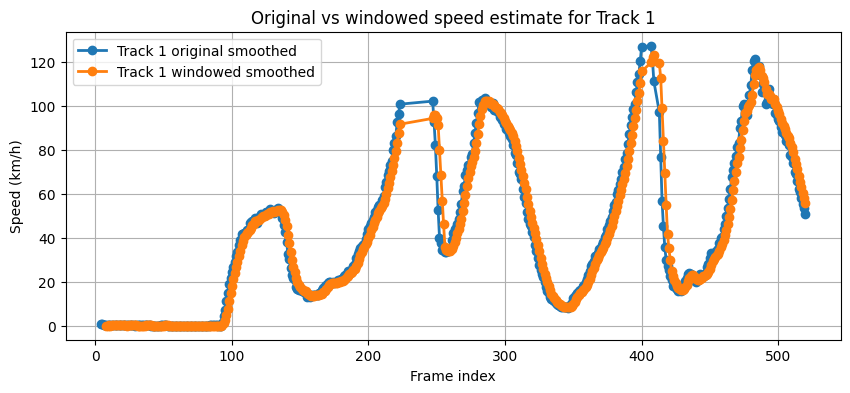

In [15]:
# ============================================================
# Cell 13: Compute more stable windowed speeds
# Purpose:
# - reduce frame-to-frame jitter by computing speed over a wider window
# - store windowed raw and smoothed speeds per track
# - prepare more reliable values for display in later cells
# ============================================================

import numpy as np

assert "TRACK_HISTORIES" in globals(), "Run Cell 11 first."

# -----------------------------
# 1) Configuration
# -----------------------------
# Instead of using only consecutive frames, compute speed using a wider gap.
# Example: compare point at frame t with point at frame t-5.
WINDOW_SPEED_FRAME_GAP = 5

# Optional second-stage smoothing on the windowed speeds
WINDOW_SPEED_SMOOTHING = 5

# Keep conservative physical guardrails
WINDOW_MAX_REASONABLE_SPEED_KMH = 200.0
WINDOW_MIN_REASONABLE_SPEED_KMH = 0.0

# -----------------------------
# 2) Helper functions
# -----------------------------
def compute_windowed_speeds_for_history(
    track_history,
    frame_gap=WINDOW_SPEED_FRAME_GAP,
    smoothing_window=WINDOW_SPEED_SMOOTHING,
    fps=30.0,
    min_kmh=WINDOW_MIN_REASONABLE_SPEED_KMH,
    max_kmh=WINDOW_MAX_REASONABLE_SPEED_KMH,
):
    """
    Compute speed using points separated by `frame_gap` observations.

    Adds / overwrites:
      - track_history["windowed_raw_speeds_kmh"]
      - track_history["windowed_smoothed_speeds_kmh"]
    """
    frames = track_history["frames"]
    world_points = track_history["world_points"]

    n = len(world_points)
    raw_windowed = [None] * n

    for i in range(n):
        j = i - int(frame_gap)
        if j < 0:
            continue

        p1 = world_points[j]
        p2 = world_points[i]
        f1 = frames[j]
        f2 = frames[i]
        frame_delta = f2 - f1

        speed_kmh = speed_kmh_from_positions(p1, p2, frame_delta, fps)

        if speed_kmh is not None:
            if not (float(min_kmh) <= float(speed_kmh) <= float(max_kmh)):
                speed_kmh = None

        raw_windowed[i] = speed_kmh

    smoothed_windowed = []
    for i in range(n):
        prefix = raw_windowed[: i + 1]
        smoothed_windowed.append(moving_average(prefix, window=smoothing_window))

    track_history["windowed_raw_speeds_kmh"] = raw_windowed
    track_history["windowed_smoothed_speeds_kmh"] = smoothed_windowed
    track_history["window_speed_frame_gap"] = int(frame_gap)
    track_history["window_speed_smoothing"] = int(smoothing_window)

    return track_history

def latest_windowed_speed_kmh(track_history, smoothed=True):
    key = "windowed_smoothed_speeds_kmh" if smoothed else "windowed_raw_speeds_kmh"
    if key not in track_history or len(track_history[key]) == 0:
        return None
    return track_history[key][-1]

# -----------------------------
# 3) Compute for all current tracks
# -----------------------------
for tid, hist in TRACK_HISTORIES.items():
    compute_windowed_speeds_for_history(
        track_history=hist,
        frame_gap=WINDOW_SPEED_FRAME_GAP,
        smoothing_window=WINDOW_SPEED_SMOOTHING,
        fps=fps,
        min_kmh=WINDOW_MIN_REASONABLE_SPEED_KMH,
        max_kmh=WINDOW_MAX_REASONABLE_SPEED_KMH,
    )

# -----------------------------
# 4) Compare original vs windowed speeds
# -----------------------------
print("=== Cell 13: Windowed Speeds Computed ===")
print("WINDOW_SPEED_FRAME_GAP  :", WINDOW_SPEED_FRAME_GAP)
print("WINDOW_SPEED_SMOOTHING  :", WINDOW_SPEED_SMOOTHING)
print("")

for tid, hist in TRACK_HISTORIES.items():
    raw_old = [float(s) for s in hist["raw_speeds_kmh"] if s is not None]
    smooth_old = [float(s) for s in hist["smoothed_speeds_kmh"] if s is not None]

    raw_new = [float(s) for s in hist["windowed_raw_speeds_kmh"] if s is not None]
    smooth_new = [float(s) for s in hist["windowed_smoothed_speeds_kmh"] if s is not None]

    print(f"Track {tid}")
    print(f"  original mean smoothed speed (km/h): {np.mean(smooth_old):.3f}" if len(smooth_old) > 0 else "  original mean smoothed speed (km/h): None")
    print(f"  windowed mean smoothed speed (km/h): {np.mean(smooth_new):.3f}" if len(smooth_new) > 0 else "  windowed mean smoothed speed (km/h): None")
    print(f"  original max raw speed (km/h)      : {np.max(raw_old):.3f}" if len(raw_old) > 0 else "  original max raw speed (km/h)      : None")
    print(f"  windowed max raw speed (km/h)      : {np.max(raw_new):.3f}" if len(raw_new) > 0 else "  windowed max raw speed (km/h)      : None")
    print(f"  latest windowed smoothed speed     : {latest_windowed_speed_kmh(hist, smoothed=True)}")
    print("")

# -----------------------------
# 5) Plot comparison for inspectable tracks
# -----------------------------
TRACK_IDS_TO_COMPARE = [
    tid for tid, hist in TRACK_HISTORIES.items()
    if len(hist["world_points"]) >= (WINDOW_SPEED_FRAME_GAP + 1)
]

for tid in TRACK_IDS_TO_COMPARE:
    hist = TRACK_HISTORIES[tid]
    frames_arr = np.asarray(hist["frames"], dtype=np.int32)

    orig_smooth_x, orig_smooth_y = [], []
    win_smooth_x, win_smooth_y = [], []

    for f, s in zip(frames_arr, hist["smoothed_speeds_kmh"]):
        if s is not None:
            orig_smooth_x.append(f)
            orig_smooth_y.append(float(s))

    for f, s in zip(frames_arr, hist["windowed_smoothed_speeds_kmh"]):
        if s is not None:
            win_smooth_x.append(f)
            win_smooth_y.append(float(s))

    plt.figure(figsize=(10, 4))
    if len(orig_smooth_x) > 0:
        plt.plot(orig_smooth_x, orig_smooth_y, marker="o", linewidth=2, label=f"Track {tid} original smoothed")
    if len(win_smooth_x) > 0:
        plt.plot(win_smooth_x, win_smooth_y, marker="o", linewidth=2, label=f"Track {tid} windowed smoothed")

    plt.xlabel("Frame index")
    plt.ylabel("Speed (km/h)")
    plt.title(f"Original vs windowed speed estimate for Track {tid}")
    plt.grid(True)
    plt.legend()
    plt.show()

=== Cell 14: Final Stabilized Speeds ===
FINAL_MIN_OBSERVATIONS   : 10
FINAL_USE_WINDOWED_SPEED : True
FINAL_MAX_SPEED_KMH      : 130.0
FINAL_MAX_STEP_CHANGE    : 12.0
FINAL_HOLD_LAST_VALID    : True
FINAL_SMOOTHING_WINDOW   : 7

Track 1
  base count                 : 481
  filtered count             : 477
  final count                : 477
  latest final speed         : 63.315888911655975
  mean final speed (km/h)    : 51.806
  max final speed (km/h)     : 118.173



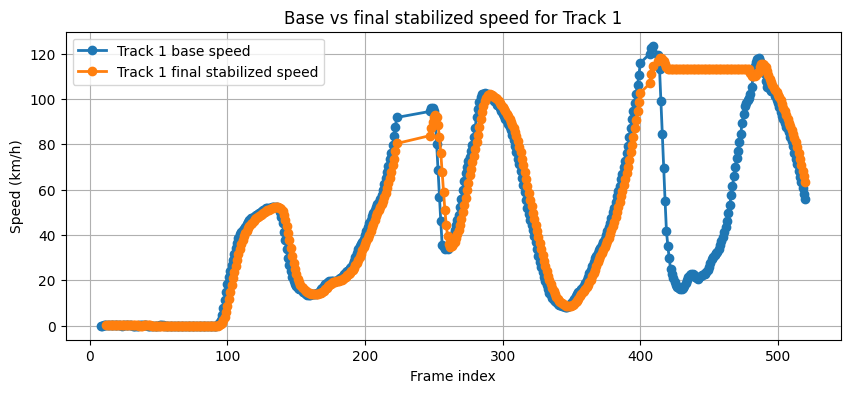

In [16]:
# ============================================================
# Cell 14: Build final stabilized speed estimates
# Purpose:
# - combine filtering rules with the windowed speed estimates
# - reject unstable jumps
# - suppress early unreliable values
# - create a final speed series for later video overlay
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

assert "TRACK_HISTORIES" in globals(), "Run Cell 11 first."
assert "latest_windowed_speed_kmh" in globals(), "Run Cell 13 first."

# -----------------------------
# 1) Final stabilization settings
# -----------------------------
FINAL_MIN_OBSERVATIONS = 10              # do not trust very early track estimates
FINAL_USE_WINDOWED_SPEED = True          # use Cell 13 speeds as base
FINAL_MAX_SPEED_KMH = 130.0              # stricter physical ceiling
FINAL_MAX_STEP_CHANGE_KMH = 12.0         # max allowed jump between adjacent displayed values
FINAL_HOLD_LAST_VALID = True             # keep last valid speed during brief instability
FINAL_SMOOTHING_WINDOW = 7               # second-stage smoothing for final display

# -----------------------------
# 2) Helper: choose base speed series
# -----------------------------
def get_base_speed_series(track_history, use_windowed=True):
    if use_windowed and "windowed_smoothed_speeds_kmh" in track_history:
        return list(track_history["windowed_smoothed_speeds_kmh"])
    return list(track_history["smoothed_speeds_kmh"])

# -----------------------------
# 3) Helper: final stabilization pass
# -----------------------------
def build_final_speed_series(
    track_history,
    min_observations=FINAL_MIN_OBSERVATIONS,
    use_windowed=FINAL_USE_WINDOWED_SPEED,
    max_speed_kmh=FINAL_MAX_SPEED_KMH,
    max_step_change_kmh=FINAL_MAX_STEP_CHANGE_KMH,
    hold_last_valid=FINAL_HOLD_LAST_VALID,
    smoothing_window=FINAL_SMOOTHING_WINDOW,
):
    """
    Build a conservative final speed series for display/use.

    Rules:
    - ignore first few observations
    - reject None or over-max values
    - reject sudden adjacent jumps larger than max_step_change_kmh
    - optionally hold the last valid speed through a rejected frame
    - apply a final trailing moving average
    """
    base_series = get_base_speed_series(track_history, use_windowed=use_windowed)
    n = len(base_series)

    filtered = [None] * n
    last_valid = None

    for i, s in enumerate(base_series):
        # Not enough observations yet
        if i + 1 < int(min_observations):
            filtered[i] = None
            continue

        # Missing value
        if s is None:
            filtered[i] = last_valid if hold_last_valid else None
            continue

        s = float(s)

        # Hard ceiling
        if s < 0.0 or s > float(max_speed_kmh):
            filtered[i] = last_valid if hold_last_valid else None
            continue

        # Sudden jump check
        if last_valid is not None:
            if abs(s - last_valid) > float(max_step_change_kmh):
                filtered[i] = last_valid if hold_last_valid else None
                continue

        filtered[i] = s
        last_valid = filtered[i]

    # Final smoothing
    final_smoothed = []
    for i in range(n):
        prefix = filtered[: i + 1]
        final_smoothed.append(moving_average(prefix, window=smoothing_window))

    track_history["final_filtered_speeds_kmh"] = filtered
    track_history["final_display_speeds_kmh"] = final_smoothed
    track_history["final_speed_config"] = {
        "min_observations": int(min_observations),
        "use_windowed": bool(use_windowed),
        "max_speed_kmh": float(max_speed_kmh),
        "max_step_change_kmh": float(max_step_change_kmh),
        "hold_last_valid": bool(hold_last_valid),
        "smoothing_window": int(smoothing_window),
    }

    return track_history

def latest_final_speed_kmh(track_history):
    series = track_history.get("final_display_speeds_kmh", [])
    if len(series) == 0:
        return None
    return series[-1]

# -----------------------------
# 4) Apply to all tracks
# -----------------------------
for tid, hist in TRACK_HISTORIES.items():
    build_final_speed_series(hist)

# -----------------------------
# 5) Print summary
# -----------------------------
print("=== Cell 14: Final Stabilized Speeds ===")
print("FINAL_MIN_OBSERVATIONS   :", FINAL_MIN_OBSERVATIONS)
print("FINAL_USE_WINDOWED_SPEED :", FINAL_USE_WINDOWED_SPEED)
print("FINAL_MAX_SPEED_KMH      :", FINAL_MAX_SPEED_KMH)
print("FINAL_MAX_STEP_CHANGE    :", FINAL_MAX_STEP_CHANGE_KMH)
print("FINAL_HOLD_LAST_VALID    :", FINAL_HOLD_LAST_VALID)
print("FINAL_SMOOTHING_WINDOW   :", FINAL_SMOOTHING_WINDOW)
print("")

for tid, hist in TRACK_HISTORIES.items():
    final_vals = [float(s) for s in hist.get("final_display_speeds_kmh", []) if s is not None]
    filtered_vals = [float(s) for s in hist.get("final_filtered_speeds_kmh", []) if s is not None]
    base_vals = [float(s) for s in get_base_speed_series(hist, use_windowed=FINAL_USE_WINDOWED_SPEED) if s is not None]

    print(f"Track {tid}")
    print(f"  base count                 : {len(base_vals)}")
    print(f"  filtered count             : {len(filtered_vals)}")
    print(f"  final count                : {len(final_vals)}")
    print(f"  latest final speed         : {latest_final_speed_kmh(hist)}")
    print(f"  mean final speed (km/h)    : {np.mean(final_vals):.3f}" if len(final_vals) > 0 else "  mean final speed (km/h)    : None")
    print(f"  max final speed (km/h)     : {np.max(final_vals):.3f}" if len(final_vals) > 0 else "  max final speed (km/h)     : None")
    print("")

# -----------------------------
# 6) Plot base vs final display speeds
# -----------------------------
TRACK_IDS_TO_PLOT = [
    tid for tid, hist in TRACK_HISTORIES.items()
    if len(hist["frames"]) >= FINAL_MIN_OBSERVATIONS
]

for tid in TRACK_IDS_TO_PLOT:
    hist = TRACK_HISTORIES[tid]
    frames_arr = np.asarray(hist["frames"], dtype=np.int32)

    base_series = get_base_speed_series(hist, use_windowed=FINAL_USE_WINDOWED_SPEED)
    final_series = hist.get("final_display_speeds_kmh", [])

    base_x, base_y = [], []
    final_x, final_y = [], []

    for f, s in zip(frames_arr, base_series):
        if s is not None:
            base_x.append(f)
            base_y.append(float(s))

    for f, s in zip(frames_arr, final_series):
        if s is not None:
            final_x.append(f)
            final_y.append(float(s))

    plt.figure(figsize=(10, 4))
    if len(base_x) > 0:
        plt.plot(base_x, base_y, marker="o", linewidth=2, label=f"Track {tid} base speed")
    if len(final_x) > 0:
        plt.plot(final_x, final_y, marker="o", linewidth=2, label=f"Track {tid} final stabilized speed")

    plt.xlabel("Frame index")
    plt.ylabel("Speed (km/h)")
    plt.title(f"Base vs final stabilized speed for Track {tid}")
    plt.grid(True)
    plt.legend()
    plt.show()

In [17]:
# ============================================================
# Cell 15: Create final annotated video with stabilized speeds
# Purpose:
# - rerun detection + tracking one more time
# - use the representative point logic from Cell 9
# - mark border-touching boxes
# - overlay final stabilized speed for each eligible track
# - save the tracked + speed-estimated output video
# ============================================================

from pathlib import Path
import cv2
import numpy as np
from tqdm.auto import tqdm

assert "TRACK_HISTORIES" in globals(), "Run Cells 11-14 first."
assert "latest_final_speed_kmh" in globals(), "Run Cell 14 first."
assert "representative_point_xyxy" in globals(), "Run updated Cell 9 first."
assert "bbox_touches_border" in globals(), "Run updated Cell 9 first."

# -----------------------------
# 1) Input / output configuration
# -----------------------------
VIDEO_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "carla_rgb_speeds.mp4"
OUTPUT_PATH_CELL15 = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "tracked_with_final_speeds.mp4"

DETECT_EVERY_N = 1
DET_THRESHOLD  = 0.30
MIN_BOX_AREA   = 30 * 30

FPS = 30.0
CLASS_MAP = PHASE_CLASSES

# Display configuration
SHOW_TRAIL = True
TRAIL_LENGTH = 20
SHOW_REPRESENTATIVE_POINT = True
SHOW_BORDER_STATUS = True
SHOW_SPEED_ONLY_WHEN_READY = True
SPEED_DECIMALS = 1

assert VIDEO_PATH is not None, "Provide VIDEO_PATH."

# -----------------------------
# 2) Build video reader
# -----------------------------
cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"

fps = cap.get(cv2.CAP_PROP_FPS)
if fps is None or fps <= 1:
    fps = FPS

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("Input:", VIDEO_PATH)
print(f"Frames: {total_frames} | Size: {width}x{height} | FPS: {fps}")
print("Representative point mode:", REPRESENTATIVE_POINT_MODE)
print("Border margin (px):", BORDER_MARGIN_PX)

# -----------------------------
# 3) Reset tracker for fresh replay
# -----------------------------
try:
    if hasattr(TRACKER, "frame_rate"):
        TRACKER.frame_rate = int(round(fps))
except Exception:
    pass

if hasattr(TRACKER, "reset"):
    TRACKER.reset()

track_meta = {}

# -----------------------------
# 4) Helpers reused from earlier cells
# -----------------------------
def build_tensors_from_detections(detections: "sv.Detections") -> np.ndarray:
    if len(detections) == 0:
        return np.zeros((0, 5), dtype=np.float32)
    return np.hstack([
        detections.xyxy.astype(np.float32),
        detections.confidence.reshape(-1, 1).astype(np.float32),
    ])

def active_tracks_to_boxes_and_ids(tracker) -> tuple[list[np.ndarray], list[int]]:
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

# -----------------------------
# 5) Output writer
# -----------------------------
OUTPUT_PATH_CELL15.parent.mkdir(parents=True, exist_ok=True)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_PATH_CELL15), fourcc, fps, (width, height))
assert writer.isOpened(), f"Could not open writer: {OUTPUT_PATH_CELL15}"

# -----------------------------
# 6) Main loop
# -----------------------------
pbar = tqdm(total=total_frames, desc="Cell 15: writing final speed video")

for frame_idx in range(total_frames):
    ok, frame_bgr = cap.read()
    if not ok:
        break

    # Detection frame?
    if frame_idx % DETECT_EVERY_N == 0:
        temp_path = "temp_frame.jpg"
        cv2.imwrite(temp_path, frame_bgr)

        det = DETECTOR.predict(temp_path, threshold=DET_THRESHOLD)
        detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

        # Filter tiny boxes
        if len(detections) > 0:
            xyxy = detections.xyxy
            areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
            keep = areas >= MIN_BOX_AREA
            detections = detections[keep]

        tensors = build_tensors_from_detections(detections)
        _ = TRACKER.update_with_tensors(tensors)

        det_with_ids = TRACKER.update_with_detections(detections)
        if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
            for i in range(len(det_with_ids)):
                tid = int(det_with_ids.tracker_id[i])
                cls = int(det_with_ids.class_id[i])
                conf = float(det_with_ids.confidence[i])
                track_meta[tid] = (cls, conf)
    else:
        _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

    out = frame_bgr.copy()
    boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)

    for box, tid in zip(boxes, ids):
        x1, y1, x2, y2 = box.astype(int).tolist()
        cls, conf = track_meta.get(tid, (-1, 0.0))
        label = CLASS_MAP.get(cls, f"class_{cls}") if cls != -1 else "unknown"

        touches_border = bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX)

        # Draw bbox with color based on border status
        box_color = (0, 165, 255) if touches_border else (0, 255, 0)
        cv2.rectangle(out, (x1, y1), (x2, y2), box_color, 2)

        # Representative point
        rep_pt = representative_point_xyxy(box, mode=REPRESENTATIVE_POINT_MODE)
        rep_x, rep_y = map(int, np.round(rep_pt))

        if SHOW_REPRESENTATIVE_POINT:
            cv2.circle(out, (rep_x, rep_y), 4, (0, 0, 255), -1)

        # Optional trajectory trail from stored history
        if SHOW_TRAIL and tid in TRACK_HISTORIES:
            pts = np.asarray(TRACK_HISTORIES[tid]["image_points"], dtype=np.float32)
            if len(pts) >= 2:
                pts = np.round(pts[-TRAIL_LENGTH:]).astype(int)
                for j in range(1, len(pts)):
                    cv2.line(out, tuple(pts[j - 1]), tuple(pts[j]), (255, 0, 0), 2, cv2.LINE_AA)

        # Pull final stabilized speed from stored history
        speed_text = None
        if tid in TRACK_HISTORIES:
            hist = TRACK_HISTORIES[tid]

            # Speed histories are indexed by observation count, not raw frame index.
            # Find the observation corresponding to this frame if it exists.
            if "frames" in hist and "final_display_speeds_kmh" in hist:
                try:
                    obs_idx = hist["frames"].index(frame_idx)
                    speed_val = hist["final_display_speeds_kmh"][obs_idx]
                except ValueError:
                    speed_val = None
            else:
                speed_val = None

            if speed_val is not None:
                speed_text = f"{speed_val:.{SPEED_DECIMALS}f} km/h"

        # Compose label text
        text = f"ID {tid}: {label}"
        if conf is not None:
            text += f" {conf:.2f}"

        if SHOW_BORDER_STATUS:
            text += " | BORDER" if touches_border else " | OK"

        if speed_text is not None:
            text += f" | {speed_text}"
        elif not SHOW_SPEED_ONLY_WHEN_READY:
            text += " | speed: --"

        cv2.putText(
            out,
            text,
            (x1, max(0, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            box_color,
            1,
            cv2.LINE_AA,
        )

    writer.write(out)
    pbar.update(1)

pbar.close()
cap.release()
writer.release()

print(f"\nDone. Saved final annotated video to: {OUTPUT_PATH_CELL15}")

Input: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\carla_rgb_speeds.mp4
Frames: 521 | Size: 800x600 | FPS: 20.0
Representative point mode: center
Border margin (px): 20


Cell 15: writing final speed video:   0%|          | 0/521 [00:00<?, ?it/s]


Done. Saved final annotated video to: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\tracked_with_final_speeds.mp4


In [18]:
# ============================================================
# Cell 16: Save and load calibration artifacts
# Purpose:
# - persist calibration so you do not have to click points every run
# - save image points, world points, homography, and metadata
# - reload calibration later for the same camera/setup
# ============================================================

from pathlib import Path
import json
import numpy as np

assert "REFERENCE_VEHICLE_IMAGE_POINTS" in globals(), "Run Cells 6-8 first."
assert "REFERENCE_VEHICLE_WORLD_POINTS" in globals(), "Run Cells 7-8 first."
assert "HOMOGRAPHY_IMG_TO_WORLD" in globals(), "Run Cell 8 first."
assert "HOMOGRAPHY_WORLD_TO_IMG" in globals(), "Run Cell 8 first."

# -----------------------------
# 1) Configuration
# -----------------------------
CALIBRATION_NAME = "carla_rgb_speeds_bev"
CALIBRATION_DIR = Path(PHASE_ROOT) / "rfdetr" / "calibration"
CALIBRATION_DIR.mkdir(parents=True, exist_ok=True)

CALIBRATION_JSON_PATH = CALIBRATION_DIR / f"{CALIBRATION_NAME}.json"
CALIBRATION_NPZ_PATH  = CALIBRATION_DIR / f"{CALIBRATION_NAME}.npz"

# Choose action:
#   "save" -> save current calibration from notebook state
#   "load" -> load existing calibration from disk into notebook state
CALIBRATION_ACTION = "save"

# -----------------------------
# 2) Helpers
# -----------------------------
def _to_serializable_array(arr):
    return np.asarray(arr).tolist()

def save_calibration_artifacts(
    json_path,
    npz_path,
    calibration_name,
    image_points,
    world_points,
    H_img_to_world,
    H_world_to_img,
    vehicle_dimensions=None,
    extra_metadata=None,
):
    image_points = np.asarray(image_points, dtype=np.float32)
    world_points = np.asarray(world_points, dtype=np.float32)
    H_img_to_world = np.asarray(H_img_to_world, dtype=np.float64)
    H_world_to_img = np.asarray(H_world_to_img, dtype=np.float64)

    metadata = {
        "calibration_name": calibration_name,
        "image_points": _to_serializable_array(image_points),
        "world_points": _to_serializable_array(world_points),
        "H_img_to_world": _to_serializable_array(H_img_to_world),
        "H_world_to_img": _to_serializable_array(H_world_to_img),
        "vehicle_dimensions": vehicle_dimensions if vehicle_dimensions is not None else {},
        "extra_metadata": extra_metadata if extra_metadata is not None else {},
    }

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    np.savez(
        npz_path,
        image_points=image_points,
        world_points=world_points,
        H_img_to_world=H_img_to_world,
        H_world_to_img=H_world_to_img,
    )

def load_calibration_artifacts(json_path, npz_path=None):
    with open(json_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    loaded = {
        "calibration_name": metadata.get("calibration_name", None),
        "image_points": np.asarray(metadata["image_points"], dtype=np.float32),
        "world_points": np.asarray(metadata["world_points"], dtype=np.float32),
        "H_img_to_world": np.asarray(metadata["H_img_to_world"], dtype=np.float64),
        "H_world_to_img": np.asarray(metadata["H_world_to_img"], dtype=np.float64),
        "vehicle_dimensions": metadata.get("vehicle_dimensions", {}),
        "extra_metadata": metadata.get("extra_metadata", {}),
    }

    # Optional consistency check against NPZ
    if npz_path is not None and Path(npz_path).exists():
        npz = np.load(npz_path)
        for k_json, k_npz in [
            ("image_points", "image_points"),
            ("world_points", "world_points"),
            ("H_img_to_world", "H_img_to_world"),
            ("H_world_to_img", "H_world_to_img"),
        ]:
            a = loaded[k_json]
            b = np.asarray(npz[k_npz])
            if not np.allclose(a, b, atol=1e-6):
                print(f"Warning: mismatch between JSON and NPZ for {k_json}")

    return loaded

# -----------------------------
# 3) Save or load
# -----------------------------
if CALIBRATION_ACTION == "save":
    extra_metadata = {
        "calibration_frame_idx": int(CALIBRATION_FRAME_IDX) if "CALIBRATION_FRAME_IDX" in globals() else None,
        "representative_point_mode_at_save": globals().get("REPRESENTATIVE_POINT_MODE", None),
    }

    save_calibration_artifacts(
        json_path=CALIBRATION_JSON_PATH,
        npz_path=CALIBRATION_NPZ_PATH,
        calibration_name=CALIBRATION_NAME,
        image_points=REFERENCE_VEHICLE_IMAGE_POINTS,
        world_points=REFERENCE_VEHICLE_WORLD_POINTS,
        H_img_to_world=HOMOGRAPHY_IMG_TO_WORLD,
        H_world_to_img=HOMOGRAPHY_WORLD_TO_IMG,
        vehicle_dimensions=globals().get("REFERENCE_VEHICLE_DIMENSIONS", {}),
        extra_metadata=extra_metadata,
    )

    print("=== Cell 16: Calibration Saved ===")
    print("Calibration name :", CALIBRATION_NAME)
    print("JSON path        :", CALIBRATION_JSON_PATH)
    print("NPZ path         :", CALIBRATION_NPZ_PATH)
    print("==================================")

elif CALIBRATION_ACTION == "load":
    assert CALIBRATION_JSON_PATH.exists(), f"Calibration JSON not found: {CALIBRATION_JSON_PATH}"

    loaded = load_calibration_artifacts(CALIBRATION_JSON_PATH, CALIBRATION_NPZ_PATH)

    # Restore into notebook globals so later cells can reuse them
    REFERENCE_VEHICLE_IMAGE_POINTS = loaded["image_points"]
    REFERENCE_VEHICLE_WORLD_POINTS = loaded["world_points"]
    HOMOGRAPHY_IMG_TO_WORLD = loaded["H_img_to_world"]
    HOMOGRAPHY_WORLD_TO_IMG = loaded["H_world_to_img"]
    REFERENCE_VEHICLE_DIMENSIONS = loaded["vehicle_dimensions"]

    print("=== Cell 16: Calibration Loaded ===")
    print("Calibration name :", loaded["calibration_name"])
    print("JSON path        :", CALIBRATION_JSON_PATH)
    print("NPZ path         :", CALIBRATION_NPZ_PATH)
    print("")
    print("Restored variables:")
    print("  - REFERENCE_VEHICLE_IMAGE_POINTS")
    print("  - REFERENCE_VEHICLE_WORLD_POINTS")
    print("  - HOMOGRAPHY_IMG_TO_WORLD")
    print("  - HOMOGRAPHY_WORLD_TO_IMG")
    print("  - REFERENCE_VEHICLE_DIMENSIONS")
    print("===================================")

    print("\nLoaded image points:")
    for i, (x, y) in enumerate(REFERENCE_VEHICLE_IMAGE_POINTS, start=1):
        print(f"  Point {i}: ({x:.1f}, {y:.1f})")

    print("\nLoaded world points:")
    for i, (x, y) in enumerate(REFERENCE_VEHICLE_WORLD_POINTS, start=1):
        print(f"  Point {i}: ({x:.3f}, {y:.3f})")

else:
    raise ValueError("CALIBRATION_ACTION must be either 'save' or 'load'")

=== Cell 16: Calibration Saved ===
Calibration name : carla_rgb_speeds_bev
JSON path        : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\calibration\carla_rgb_speeds_bev.json
NPZ path         : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\calibration\carla_rgb_speeds_bev.npz


In [19]:
# ============================================================
# Cell 17: Export track histories and run summaries
# Purpose:
# - save per-track / per-observation results to CSV
# - save compact track summary to JSON
# - make later analysis easier without re-running the notebook
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd

assert "TRACK_HISTORIES" in globals(), "Run Cells 11-14 first."

# -----------------------------
# 1) Output configuration
# -----------------------------
EXPORT_NAME = "carla_rgb_speeds_bev_run"
EXPORT_DIR = Path(PHASE_ROOT) / "rfdetr" / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

TRACK_OBSERVATIONS_CSV_PATH = EXPORT_DIR / f"{EXPORT_NAME}_track_observations.csv"
TRACK_SUMMARY_JSON_PATH     = EXPORT_DIR / f"{EXPORT_NAME}_track_summary.json"
RUN_CONFIG_JSON_PATH        = EXPORT_DIR / f"{EXPORT_NAME}_run_config.json"

# -----------------------------
# 2) Helpers
# -----------------------------
def _safe_list_get(seq, idx, default=None):
    if seq is None:
        return default
    if idx < 0 or idx >= len(seq):
        return default
    return seq[idx]

def build_track_observations_dataframe(track_histories):
    """
    One row per stored observation.
    """
    rows = []

    for tid, hist in track_histories.items():
        frames = hist.get("frames", [])
        image_points = hist.get("image_points", [])
        world_points = hist.get("world_points", [])
        raw_speeds = hist.get("raw_speeds_kmh", [])
        smooth_speeds = hist.get("smoothed_speeds_kmh", [])
        windowed_raw = hist.get("windowed_raw_speeds_kmh", [])
        windowed_smooth = hist.get("windowed_smoothed_speeds_kmh", [])
        final_filtered = hist.get("final_filtered_speeds_kmh", [])
        final_display = hist.get("final_display_speeds_kmh", [])

        n = len(frames)

        for i in range(n):
            img_pt = _safe_list_get(image_points, i, default=[None, None])
            world_pt = _safe_list_get(world_points, i, default=[None, None])

            row = {
                "track_id": int(tid),
                "obs_index": int(i),
                "frame_idx": int(frames[i]),
                "class_id": hist.get("class_id", None),
                "confidence": hist.get("confidence", None),

                "image_x": float(img_pt[0]) if img_pt is not None else None,
                "image_y": float(img_pt[1]) if img_pt is not None else None,

                "world_x_m": float(world_pt[0]) if world_pt is not None else None,
                "world_y_m": float(world_pt[1]) if world_pt is not None else None,

                "raw_speed_kmh": _safe_list_get(raw_speeds, i, None),
                "smoothed_speed_kmh": _safe_list_get(smooth_speeds, i, None),
                "windowed_raw_speed_kmh": _safe_list_get(windowed_raw, i, None),
                "windowed_smoothed_speed_kmh": _safe_list_get(windowed_smooth, i, None),
                "final_filtered_speed_kmh": _safe_list_get(final_filtered, i, None),
                "final_display_speed_kmh": _safe_list_get(final_display, i, None),
            }
            rows.append(row)

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["track_id", "frame_idx", "obs_index"]).reset_index(drop=True)
    return df

def summarize_single_track(track_id, hist):
    """
    Compact summary dictionary for one track.
    """
    world_pts = np.asarray(hist.get("world_points", []), dtype=np.float32)
    frames = hist.get("frames", [])

    total_distance_m = 0.0
    if len(world_pts) >= 2:
        diffs = world_pts[1:] - world_pts[:-1]
        total_distance_m = float(np.linalg.norm(diffs, axis=1).sum())

    def valid_vals(key):
        return [float(v) for v in hist.get(key, []) if v is not None]

    raw_vals = valid_vals("raw_speeds_kmh")
    smooth_vals = valid_vals("smoothed_speeds_kmh")
    windowed_vals = valid_vals("windowed_smoothed_speeds_kmh")
    final_vals = valid_vals("final_display_speeds_kmh")

    summary = {
        "track_id": int(track_id),
        "class_id": hist.get("class_id", None),
        "confidence": hist.get("confidence", None),
        "num_observations": int(len(frames)),
        "first_frame": int(frames[0]) if len(frames) > 0 else None,
        "last_frame": int(frames[-1]) if len(frames) > 0 else None,
        "total_distance_m": total_distance_m,
        "first_world_point": world_pts[0].tolist() if len(world_pts) > 0 else None,
        "last_world_point": world_pts[-1].tolist() if len(world_pts) > 0 else None,

        "mean_raw_speed_kmh": float(np.mean(raw_vals)) if len(raw_vals) > 0 else None,
        "max_raw_speed_kmh": float(np.max(raw_vals)) if len(raw_vals) > 0 else None,

        "mean_smoothed_speed_kmh": float(np.mean(smooth_vals)) if len(smooth_vals) > 0 else None,
        "max_smoothed_speed_kmh": float(np.max(smooth_vals)) if len(smooth_vals) > 0 else None,

        "mean_windowed_smoothed_speed_kmh": float(np.mean(windowed_vals)) if len(windowed_vals) > 0 else None,
        "max_windowed_smoothed_speed_kmh": float(np.max(windowed_vals)) if len(windowed_vals) > 0 else None,

        "mean_final_display_speed_kmh": float(np.mean(final_vals)) if len(final_vals) > 0 else None,
        "max_final_display_speed_kmh": float(np.max(final_vals)) if len(final_vals) > 0 else None,
        "latest_final_display_speed_kmh": float(final_vals[-1]) if len(final_vals) > 0 else None,
    }
    return summary

def build_track_summary(track_histories):
    summaries = []
    for tid, hist in track_histories.items():
        summaries.append(summarize_single_track(tid, hist))
    summaries.sort(key=lambda x: x["track_id"])
    return summaries

# -----------------------------
# 3) Build exports
# -----------------------------
df_tracks = build_track_observations_dataframe(TRACK_HISTORIES)
track_summary = build_track_summary(TRACK_HISTORIES)

run_config = {
    "export_name": EXPORT_NAME,
    "representative_point_mode": globals().get("REPRESENTATIVE_POINT_MODE", None),
    "border_margin_px": globals().get("BORDER_MARGIN_PX", None),
    "default_speed_window": globals().get("DEFAULT_SPEED_WINDOW", None),
    "window_speed_frame_gap": globals().get("WINDOW_SPEED_FRAME_GAP", None),
    "window_speed_smoothing": globals().get("WINDOW_SPEED_SMOOTHING", None),
    "final_min_observations": globals().get("FINAL_MIN_OBSERVATIONS", None),
    "final_use_windowed_speed": globals().get("FINAL_USE_WINDOWED_SPEED", None),
    "final_max_speed_kmh": globals().get("FINAL_MAX_SPEED_KMH", None),
    "final_max_step_change_kmh": globals().get("FINAL_MAX_STEP_CHANGE_KMH", None),
    "final_hold_last_valid": globals().get("FINAL_HOLD_LAST_VALID", None),
    "final_smoothing_window": globals().get("FINAL_SMOOTHING_WINDOW", None),
    "reference_vehicle_dimensions": globals().get("REFERENCE_VEHICLE_DIMENSIONS", {}),
    "calibration_name": globals().get("CALIBRATION_NAME", None),
}

# -----------------------------
# 4) Save to disk
# -----------------------------
df_tracks.to_csv(TRACK_OBSERVATIONS_CSV_PATH, index=False)

with open(TRACK_SUMMARY_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(track_summary, f, indent=2)

with open(RUN_CONFIG_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=2)

# -----------------------------
# 5) Console summary
# -----------------------------
print("=== Cell 17: Exports Saved ===")
print("Track observations CSV :", TRACK_OBSERVATIONS_CSV_PATH)
print("Track summary JSON     :", TRACK_SUMMARY_JSON_PATH)
print("Run config JSON        :", RUN_CONFIG_JSON_PATH)
print("")

print(f"Number of exported observations : {len(df_tracks)}")
print(f"Number of exported tracks       : {len(track_summary)}")

if len(track_summary) > 0:
    print("\nTrack summaries:")
    for s in track_summary[:10]:
        print(
            f"  Track {s['track_id']} | "
            f"class={s['class_id']} | "
            f"obs={s['num_observations']} | "
            f"mean_final={s['mean_final_display_speed_kmh']}"
        )

print("================================")

=== Cell 17: Exports Saved ===
Track observations CSV : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\exports\carla_rgb_speeds_bev_run_track_observations.csv
Track summary JSON     : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\exports\carla_rgb_speeds_bev_run_track_summary.json
Run config JSON        : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\exports\carla_rgb_speeds_bev_run_run_config.json

Number of exported observations : 486
Number of exported tracks       : 1

Track summaries:
  Track 1 | class=3 | obs=486 | mean_final=51.80644370488736


In [20]:
# ============================================================
# Cell 18: End-to-end runner for video OR frames directory
# Purpose:
# - provide one entry point for detection + tracking + speed estimation
# - support either a video path or a directory of frames
# - optionally use saved calibration
# - write final annotated output video
# - export track observations / summaries
# ============================================================

from pathlib import Path
import cv2
import json
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

assert "DETECTOR" in globals(), "Run Cells 1-2 first."
assert "TRACKER" in globals(), "Run Cell 3 first."
assert "representative_point_xyxy" in globals(), "Run Cell 9 first."
assert "bbox_touches_border" in globals(), "Run Cell 9 first."
assert "get_or_create_track_history" in globals(), "Run Cell 10 first."
assert "mark_track_observed" in globals(), "Run Cell 10 first."
assert "update_missing_tracks" in globals(), "Run Cell 10 first."
assert "build_final_speed_series" in globals(), "Run Cell 14 first."

# -----------------------------
# 1) User configuration
# -----------------------------
INPUT_TYPE = "video"   # "video" or "frames"

VIDEO_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "carla_rgb_speeds.mp4"
FRAMES_DIR = None      # e.g. Path(PHASE_ROOT) / "rfdetr" / "videos" / "my_frames"

RUN_NAME = "custom_video_bev_e2e"
OUTPUT_DIR = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "speed-estimation-runs" / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_VIDEO_PATH = OUTPUT_DIR / f"{RUN_NAME}_annotated.mp4"
OUTPUT_TRACK_CSV_PATH = OUTPUT_DIR / f"{RUN_NAME}_track_observations.csv"
OUTPUT_TRACK_SUMMARY_JSON_PATH = OUTPUT_DIR / f"{RUN_NAME}_track_summary.json"
OUTPUT_RUN_CONFIG_JSON_PATH = OUTPUT_DIR / f"{RUN_NAME}_run_config.json"

# Detection / tracking settings
DETECT_EVERY_N = 1
DET_THRESHOLD = 0.30
MIN_BOX_AREA = 30 * 30
FPS_FALLBACK = 30.0
CLASS_MAP = PHASE_CLASSES

# Display settings
SHOW_TRAIL = True
TRAIL_LENGTH = 20
SHOW_REPRESENTATIVE_POINT = True
SHOW_BORDER_STATUS = True
SHOW_SPEED_ONLY_WHEN_READY = True
SPEED_DECIMALS = 1

# If you have multiple saved calibrations, load the right one before running this cell.
# This cell assumes HOMOGRAPHY_* variables already exist in memory.

# -----------------------------
# 2) Input helpers
# -----------------------------
def list_frames(folder: Path):
    exts = (".jpg", ".jpeg", ".png")
    frames = [p for p in folder.iterdir() if p.suffix.lower() in exts]
    return sorted(frames, key=lambda p: p.name)

def open_input_source(input_type, video_path=None, frames_dir=None, fps_fallback=30.0):
    if input_type == "video":
        assert video_path is not None, "VIDEO_PATH must be provided when INPUT_TYPE='video'"
        cap = cv2.VideoCapture(str(video_path))
        assert cap.isOpened(), f"Could not open video: {video_path}"

        fps = cap.get(cv2.CAP_PROP_FPS)
        if fps is None or fps <= 1:
            fps = fps_fallback

        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        return {
            "mode": "video",
            "cap": cap,
            "frames_list": None,
            "fps": fps,
            "width": width,
            "height": height,
            "total_frames": total_frames,
            "source_text": str(video_path),
        }

    elif input_type == "frames":
        assert frames_dir is not None, "FRAMES_DIR must be provided when INPUT_TYPE='frames'"
        frames_list = list_frames(frames_dir)
        assert len(frames_list) > 0, f"No frames found in: {frames_dir}"

        first = cv2.imread(str(frames_list[0]))
        assert first is not None, f"Could not read first frame: {frames_list[0]}"
        height, width = first.shape[:2]

        return {
            "mode": "frames",
            "cap": None,
            "frames_list": frames_list,
            "fps": fps_fallback,
            "width": width,
            "height": height,
            "total_frames": len(frames_list),
            "source_text": str(frames_dir),
        }

    else:
        raise ValueError("INPUT_TYPE must be either 'video' or 'frames'")

def read_frame_from_source(source, frame_idx):
    if source["mode"] == "video":
        ok, frame_bgr = source["cap"].read()
        if not ok:
            return None
        return frame_bgr
    else:
        frame_path = source["frames_list"][frame_idx]
        frame_bgr = cv2.imread(str(frame_path))
        return frame_bgr

# -----------------------------
# 3) Export helpers
# -----------------------------
def _safe_list_get(seq, idx, default=None):
    if seq is None:
        return default
    if idx < 0 or idx >= len(seq):
        return default
    return seq[idx]

def build_track_observations_dataframe(track_histories):
    rows = []

    for tid, hist in track_histories.items():
        frames = hist.get("frames", [])
        image_points = hist.get("image_points", [])
        world_points = hist.get("world_points", [])
        raw_speeds = hist.get("raw_speeds_kmh", [])
        smooth_speeds = hist.get("smoothed_speeds_kmh", [])
        windowed_raw = hist.get("windowed_raw_speeds_kmh", [])
        windowed_smooth = hist.get("windowed_smoothed_speeds_kmh", [])
        final_filtered = hist.get("final_filtered_speeds_kmh", [])
        final_display = hist.get("final_display_speeds_kmh", [])

        n = len(frames)

        for i in range(n):
            img_pt = _safe_list_get(image_points, i, default=[None, None])
            world_pt = _safe_list_get(world_points, i, default=[None, None])

            rows.append({
                "track_id": int(tid),
                "obs_index": int(i),
                "frame_idx": int(frames[i]),
                "class_id": hist.get("class_id", None),
                "confidence": hist.get("confidence", None),
                "image_x": float(img_pt[0]) if img_pt is not None else None,
                "image_y": float(img_pt[1]) if img_pt is not None else None,
                "world_x_m": float(world_pt[0]) if world_pt is not None else None,
                "world_y_m": float(world_pt[1]) if world_pt is not None else None,
                "raw_speed_kmh": _safe_list_get(raw_speeds, i, None),
                "smoothed_speed_kmh": _safe_list_get(smooth_speeds, i, None),
                "windowed_raw_speed_kmh": _safe_list_get(windowed_raw, i, None),
                "windowed_smoothed_speed_kmh": _safe_list_get(windowed_smooth, i, None),
                "final_filtered_speed_kmh": _safe_list_get(final_filtered, i, None),
                "final_display_speed_kmh": _safe_list_get(final_display, i, None),
            })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["track_id", "frame_idx", "obs_index"]).reset_index(drop=True)
    return df

def summarize_single_track(track_id, hist):
    world_pts = np.asarray(hist.get("world_points", []), dtype=np.float32)
    frames = hist.get("frames", [])

    total_distance_m = 0.0
    if len(world_pts) >= 2:
        diffs = world_pts[1:] - world_pts[:-1]
        total_distance_m = float(np.linalg.norm(diffs, axis=1).sum())

    def valid_vals(key):
        return [float(v) for v in hist.get(key, []) if v is not None]

    final_vals = valid_vals("final_display_speeds_kmh")
    return {
        "track_id": int(track_id),
        "class_id": hist.get("class_id", None),
        "confidence": hist.get("confidence", None),
        "num_observations": int(len(frames)),
        "first_frame": int(frames[0]) if len(frames) > 0 else None,
        "last_frame": int(frames[-1]) if len(frames) > 0 else None,
        "total_distance_m": total_distance_m,
        "mean_final_display_speed_kmh": float(np.mean(final_vals)) if len(final_vals) > 0 else None,
        "max_final_display_speed_kmh": float(np.max(final_vals)) if len(final_vals) > 0 else None,
        "latest_final_display_speed_kmh": float(final_vals[-1]) if len(final_vals) > 0 else None,
    }

def build_track_summary(track_histories):
    summaries = []
    for tid, hist in track_histories.items():
        summaries.append(summarize_single_track(tid, hist))
    summaries.sort(key=lambda x: x["track_id"])
    return summaries

# -----------------------------
# 4) Speed post-processing helpers
# -----------------------------
def compute_windowed_speeds_for_history(
    track_history,
    frame_gap=WINDOW_SPEED_FRAME_GAP,
    smoothing_window=WINDOW_SPEED_SMOOTHING,
    fps=30.0,
    min_kmh=WINDOW_MIN_REASONABLE_SPEED_KMH,
    max_kmh=WINDOW_MAX_REASONABLE_SPEED_KMH,
):
    frames = track_history["frames"]
    world_points = track_history["world_points"]
    n = len(world_points)

    raw_windowed = [None] * n
    for i in range(n):
        j = i - int(frame_gap)
        if j < 0:
            continue

        p1 = world_points[j]
        p2 = world_points[i]
        f1 = frames[j]
        f2 = frames[i]
        frame_delta = f2 - f1

        speed_kmh = speed_kmh_from_positions(p1, p2, frame_delta, fps)
        if speed_kmh is not None:
            if not (float(min_kmh) <= float(speed_kmh) <= float(max_kmh)):
                speed_kmh = None

        raw_windowed[i] = speed_kmh

    smoothed_windowed = []
    for i in range(n):
        prefix = raw_windowed[: i + 1]
        smoothed_windowed.append(moving_average(prefix, window=smoothing_window))

    track_history["windowed_raw_speeds_kmh"] = raw_windowed
    track_history["windowed_smoothed_speeds_kmh"] = smoothed_windowed
    track_history["window_speed_frame_gap"] = int(frame_gap)
    track_history["window_speed_smoothing"] = int(smoothing_window)
    return track_history

# -----------------------------
# 5) Prepare input + writer + tracker
# -----------------------------
source = open_input_source(
    input_type=INPUT_TYPE,
    video_path=VIDEO_PATH,
    frames_dir=FRAMES_DIR,
    fps_fallback=FPS_FALLBACK,
)

fps = source["fps"]
width = source["width"]
height = source["height"]
total_frames = source["total_frames"]

print("Input source:", source["source_text"])
print(f"Frames: {total_frames} | Size: {width}x{height} | FPS: {fps}")
print("Representative point mode:", REPRESENTATIVE_POINT_MODE)
print("Border margin (px):", BORDER_MARGIN_PX)

try:
    if hasattr(TRACKER, "frame_rate"):
        TRACKER.frame_rate = int(round(fps))
except Exception:
    pass

if hasattr(TRACKER, "reset"):
    TRACKER.reset()

TRACK_HISTORIES.clear()
FINISHED_TRACK_HISTORIES.clear()
TRACK_LAST_SEEN_FRAME.clear()
TRACK_STATUS.clear()

track_meta = {}

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_VIDEO_PATH), fourcc, fps, (width, height))
assert writer.isOpened(), f"Could not open writer: {OUTPUT_VIDEO_PATH}"

# -----------------------------
# 6) Core helpers for detection/tracking
# -----------------------------
def build_tensors_from_detections(detections: "sv.Detections") -> np.ndarray:
    if len(detections) == 0:
        return np.zeros((0, 5), dtype=np.float32)
    return np.hstack([
        detections.xyxy.astype(np.float32),
        detections.confidence.reshape(-1, 1).astype(np.float32),
    ])

def active_tracks_to_boxes_and_ids(tracker) -> tuple[list[np.ndarray], list[int]]:
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

# -----------------------------
# 7) End-to-end main loop
# -----------------------------
pbar = tqdm(total=total_frames, desc="Cell 18: end-to-end pipeline")

for frame_idx in range(total_frames):
    frame_bgr = read_frame_from_source(source, frame_idx)
    if frame_bgr is None:
        pbar.update(1)
        continue

    # Detect
    if frame_idx % DETECT_EVERY_N == 0:
        temp_path = "temp_frame.jpg"
        cv2.imwrite(temp_path, frame_bgr)

        det = DETECTOR.predict(temp_path, threshold=DET_THRESHOLD)
        detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

        if len(detections) > 0:
            xyxy = detections.xyxy
            areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
            keep = areas >= MIN_BOX_AREA
            detections = detections[keep]

        tensors = build_tensors_from_detections(detections)
        _ = TRACKER.update_with_tensors(tensors)

        det_with_ids = TRACKER.update_with_detections(detections)
        if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
            for i in range(len(det_with_ids)):
                tid = int(det_with_ids.tracker_id[i])
                cls = int(det_with_ids.class_id[i])
                conf = float(det_with_ids.confidence[i])
                track_meta[tid] = (cls, conf)
    else:
        _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

    boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)
    active_ids_this_frame = set()

    # Update histories
    for box, tid in zip(boxes, ids):
        active_ids_this_frame.add(int(tid))
        cls, conf = track_meta.get(tid, (-1, 0.0))

        if cls in SPEED_ESTIMATION_CLASS_IDS:
            touches_border = bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX)
            if not touches_border:
                hist = get_or_create_track_history(tid, speed_window=DEFAULT_SPEED_WINDOW)
                append_track_observation(
                    track_history=hist,
                    frame_idx=frame_idx,
                    box_xyxy=box,
                    class_id=cls,
                    confidence=conf,
                    fps=fps,
                )

        mark_track_observed(tid, frame_idx)

    update_missing_tracks(active_ids_this_frame, frame_idx, max_missing_frames=MAX_MISSING_FRAMES)

    # Draw annotated output
    out = frame_bgr.copy()

    for box, tid in zip(boxes, ids):
        x1, y1, x2, y2 = box.astype(int).tolist()
        cls, conf = track_meta.get(tid, (-1, 0.0))
        label = CLASS_MAP.get(cls, f"class_{cls}") if cls != -1 else "unknown"

        touches_border = bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX)
        box_color = (0, 165, 255) if touches_border else (0, 255, 0)
        cv2.rectangle(out, (x1, y1), (x2, y2), box_color, 2)

        rep_pt = representative_point_xyxy(box, mode=REPRESENTATIVE_POINT_MODE)
        rep_x, rep_y = map(int, np.round(rep_pt))
        if SHOW_REPRESENTATIVE_POINT:
            cv2.circle(out, (rep_x, rep_y), 4, (0, 0, 255), -1)

        if SHOW_TRAIL and tid in TRACK_HISTORIES:
            pts = np.asarray(TRACK_HISTORIES[tid]["image_points"], dtype=np.float32)
            if len(pts) >= 2:
                pts = np.round(pts[-TRAIL_LENGTH:]).astype(int)
                for j in range(1, len(pts)):
                    cv2.line(out, tuple(pts[j - 1]), tuple(pts[j]), (255, 0, 0), 2, cv2.LINE_AA)

        speed_text = None
        if tid in TRACK_HISTORIES:
            hist = TRACK_HISTORIES[tid]
            if "frames" in hist and "final_display_speeds_kmh" in hist:
                try:
                    obs_idx = hist["frames"].index(frame_idx)
                    speed_val = hist["final_display_speeds_kmh"][obs_idx]
                except ValueError:
                    speed_val = None
            else:
                speed_val = None

            if speed_val is not None:
                speed_text = f"{speed_val:.{SPEED_DECIMALS}f} km/h"

        text = f"ID {tid}: {label}"
        if conf is not None:
            text += f" {conf:.2f}"

        if SHOW_BORDER_STATUS:
            text += " | BORDER" if touches_border else " | OK"

        if speed_text is not None:
            text += f" | {speed_text}"
        elif not SHOW_SPEED_ONLY_WHEN_READY:
            text += " | speed: --"

        cv2.putText(
            out,
            text,
            (x1, max(0, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            box_color,
            1,
            cv2.LINE_AA,
        )

    writer.write(out)
    pbar.update(1)

pbar.close()

if source["cap"] is not None:
    source["cap"].release()
writer.release()

# -----------------------------
# 8) Post-process speeds
# -----------------------------
for tid, hist in TRACK_HISTORIES.items():
    compute_windowed_speeds_for_history(
        track_history=hist,
        frame_gap=WINDOW_SPEED_FRAME_GAP,
        smoothing_window=WINDOW_SPEED_SMOOTHING,
        fps=fps,
        min_kmh=WINDOW_MIN_REASONABLE_SPEED_KMH,
        max_kmh=WINDOW_MAX_REASONABLE_SPEED_KMH,
    )

for tid, hist in TRACK_HISTORIES.items():
    build_final_speed_series(hist)

# Re-write annotated video with final speeds now that they exist
# For practical notebook simplicity, do a second lightweight pass over the same source.
# This keeps the main logic easy to reason about.
source = open_input_source(
    input_type=INPUT_TYPE,
    video_path=VIDEO_PATH,
    frames_dir=FRAMES_DIR,
    fps_fallback=FPS_FALLBACK,
)

try:
    if hasattr(TRACKER, "frame_rate"):
        TRACKER.frame_rate = int(round(fps))
except Exception:
    pass

if hasattr(TRACKER, "reset"):
    TRACKER.reset()

track_meta = {}
writer = cv2.VideoWriter(str(OUTPUT_VIDEO_PATH), fourcc, fps, (width, height))
assert writer.isOpened(), f"Could not reopen writer: {OUTPUT_VIDEO_PATH}"

pbar = tqdm(total=total_frames, desc="Cell 18: writing final annotated video")

for frame_idx in range(total_frames):
    frame_bgr = read_frame_from_source(source, frame_idx)
    if frame_bgr is None:
        pbar.update(1)
        continue

    if frame_idx % DETECT_EVERY_N == 0:
        temp_path = "temp_frame.jpg"
        cv2.imwrite(temp_path, frame_bgr)

        det = DETECTOR.predict(temp_path, threshold=DET_THRESHOLD)
        detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

        if len(detections) > 0:
            xyxy = detections.xyxy
            areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
            keep = areas >= MIN_BOX_AREA
            detections = detections[keep]

        tensors = build_tensors_from_detections(detections)
        _ = TRACKER.update_with_tensors(tensors)

        det_with_ids = TRACKER.update_with_detections(detections)
        if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
            for i in range(len(det_with_ids)):
                tid = int(det_with_ids.tracker_id[i])
                cls = int(det_with_ids.class_id[i])
                conf = float(det_with_ids.confidence[i])
                track_meta[tid] = (cls, conf)
    else:
        _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

    out = frame_bgr.copy()
    boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)

    for box, tid in zip(boxes, ids):
        x1, y1, x2, y2 = box.astype(int).tolist()
        cls, conf = track_meta.get(tid, (-1, 0.0))
        label = CLASS_MAP.get(cls, f"class_{cls}") if cls != -1 else "unknown"

        touches_border = bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX)
        box_color = (0, 165, 255) if touches_border else (0, 255, 0)
        cv2.rectangle(out, (x1, y1), (x2, y2), box_color, 2)

        rep_pt = representative_point_xyxy(box, mode=REPRESENTATIVE_POINT_MODE)
        rep_x, rep_y = map(int, np.round(rep_pt))
        if SHOW_REPRESENTATIVE_POINT:
            cv2.circle(out, (rep_x, rep_y), 4, (0, 0, 255), -1)

        if SHOW_TRAIL and tid in TRACK_HISTORIES:
            pts = np.asarray(TRACK_HISTORIES[tid]["image_points"], dtype=np.float32)
            if len(pts) >= 2:
                pts = np.round(pts[-TRAIL_LENGTH:]).astype(int)
                for j in range(1, len(pts)):
                    cv2.line(out, tuple(pts[j - 1]), tuple(pts[j]), (255, 0, 0), 2, cv2.LINE_AA)

        speed_text = None
        if tid in TRACK_HISTORIES:
            hist = TRACK_HISTORIES[tid]
            try:
                obs_idx = hist["frames"].index(frame_idx)
                speed_val = hist["final_display_speeds_kmh"][obs_idx]
            except ValueError:
                speed_val = None

            if speed_val is not None:
                speed_text = f"{speed_val:.{SPEED_DECIMALS}f} km/h"

        text = f"ID {tid}: {label}"
        if conf is not None:
            text += f" {conf:.2f}"

        if SHOW_BORDER_STATUS:
            text += " | BORDER" if touches_border else " | OK"

        if speed_text is not None:
            text += f" | {speed_text}"
        elif not SHOW_SPEED_ONLY_WHEN_READY:
            text += " | speed: --"

        cv2.putText(
            out,
            text,
            (x1, max(0, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            box_color,
            1,
            cv2.LINE_AA,
        )

    writer.write(out)
    pbar.update(1)

pbar.close()
if source["cap"] is not None:
    source["cap"].release()
writer.release()

# -----------------------------
# 9) Export CSV / JSON
# -----------------------------
df_tracks = build_track_observations_dataframe(TRACK_HISTORIES)
track_summary = build_track_summary(TRACK_HISTORIES)

run_config = {
    "run_name": RUN_NAME,
    "input_type": INPUT_TYPE,
    "video_path": str(VIDEO_PATH) if VIDEO_PATH is not None else None,
    "frames_dir": str(FRAMES_DIR) if FRAMES_DIR is not None else None,
    "output_video_path": str(OUTPUT_VIDEO_PATH),
    "representative_point_mode": REPRESENTATIVE_POINT_MODE,
    "border_margin_px": BORDER_MARGIN_PX,
    "detect_every_n": DETECT_EVERY_N,
    "det_threshold": DET_THRESHOLD,
    "min_box_area": MIN_BOX_AREA,
    "default_speed_window": DEFAULT_SPEED_WINDOW,
    "window_speed_frame_gap": WINDOW_SPEED_FRAME_GAP,
    "window_speed_smoothing": WINDOW_SPEED_SMOOTHING,
    "final_min_observations": FINAL_MIN_OBSERVATIONS,
    "final_use_windowed_speed": FINAL_USE_WINDOWED_SPEED,
    "final_max_speed_kmh": FINAL_MAX_SPEED_KMH,
    "final_max_step_change_kmh": FINAL_MAX_STEP_CHANGE_KMH,
    "final_hold_last_valid": FINAL_HOLD_LAST_VALID,
    "final_smoothing_window": FINAL_SMOOTHING_WINDOW,
    "reference_vehicle_dimensions": globals().get("REFERENCE_VEHICLE_DIMENSIONS", {}),
    "calibration_name": globals().get("CALIBRATION_NAME", None),
}

df_tracks.to_csv(OUTPUT_TRACK_CSV_PATH, index=False)

with open(OUTPUT_TRACK_SUMMARY_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(track_summary, f, indent=2)

with open(OUTPUT_RUN_CONFIG_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=2)

# -----------------------------
# 10) Final summary
# -----------------------------
print("\n=== Cell 18 complete ===")
print("Annotated video       :", OUTPUT_VIDEO_PATH)
print("Track observations CSV:", OUTPUT_TRACK_CSV_PATH)
print("Track summary JSON    :", OUTPUT_TRACK_SUMMARY_JSON_PATH)
print("Run config JSON       :", OUTPUT_RUN_CONFIG_JSON_PATH)
print("")
print(f"Exported observations : {len(df_tracks)}")
print(f"Exported tracks       : {len(track_summary)}")

if len(track_summary) > 0:
    print("\nTrack summaries:")
    for s in track_summary[:10]:
        print(
            f"  Track {s['track_id']} | "
            f"class={s['class_id']} | "
            f"obs={s['num_observations']} | "
            f"mean_final={s['mean_final_display_speed_kmh']}"
        )
print("================================")

Input source: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\carla_rgb_speeds.mp4
Frames: 521 | Size: 800x600 | FPS: 20.0
Representative point mode: center
Border margin (px): 20


Cell 18: end-to-end pipeline:   0%|          | 0/521 [00:00<?, ?it/s]

Cell 18: writing final annotated video:   0%|          | 0/521 [00:00<?, ?it/s]


=== Cell 18 complete ===
Annotated video       : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\speed-estimation-runs\custom_video_bev_e2e\custom_video_bev_e2e_annotated.mp4
Track observations CSV: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\speed-estimation-runs\custom_video_bev_e2e\custom_video_bev_e2e_track_observations.csv
Track summary JSON    : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\speed-estimation-runs\custom_video_bev_e2e\custom_video_bev_e2e_track_summary.json
Run config JSON       : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\speed-estimation-runs\custom_video_bev_e2e\custom_video_bev_e2e_run_config.json

Exported observations : 486
Exported tracks       : 1

Track summaries:
  Track 1 | class=3 | obs=486 | mean_final=51.80644370488736


In [27]:
# ============================================================
# Cell 19: Load and Align Ground Truth Speeds and Speed Estimations CSVs
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

GT_CSV_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "carla_rgb_speeds.csv"
PRED_CSV_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "speed-estimation-runs" / "custom_video_bev_e2e" / "custom_video_bev_e2e_track_observations.csv"

gt_df = pd.read_csv(GT_CSV_PATH).rename(columns={
    "frame": "frame_idx",
    "speed_kmh": "gt_speed_kmh"
})

pred_df = pd.read_csv(PRED_CSV_PATH)

# Keep only the main track if needed
pred_df = pred_df[pred_df["track_id"] == 1].copy()

speed_cols = [
    "raw_speed_kmh",
    "smoothed_speed_kmh",
    "windowed_raw_speed_kmh",
    "windowed_smoothed_speed_kmh",
    "final_filtered_speed_kmh",
    "final_display_speed_kmh",
]

compare_df = gt_df.merge(
    pred_df[["frame_idx"] + speed_cols],
    on="frame_idx",
    how="left"
)

print("Ground truth shape:", gt_df.shape)
print("Prediction shape  :", pred_df.shape)
print("Merged shape      :", compare_df.shape)
compare_df.head()

Ground truth shape: (521, 2)
Prediction shape  : (486, 15)
Merged shape      : (521, 8)


,frame_idx,gt_speed_kmh,raw_speed_kmh,smoothed_speed_kmh,windowed_raw_speed_kmh,windowed_smoothed_speed_kmh,final_filtered_speed_kmh,final_display_speed_kmh
0,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1.76,NaN,NaN,NaN,NaN,NaN,NaN
2,2,3.53,NaN,NaN,NaN,NaN,NaN,NaN
3,3,5.29,NaN,NaN,NaN,NaN,NaN,NaN
4,4,6.92,0.73386,0.73386,NaN,NaN,NaN,NaN


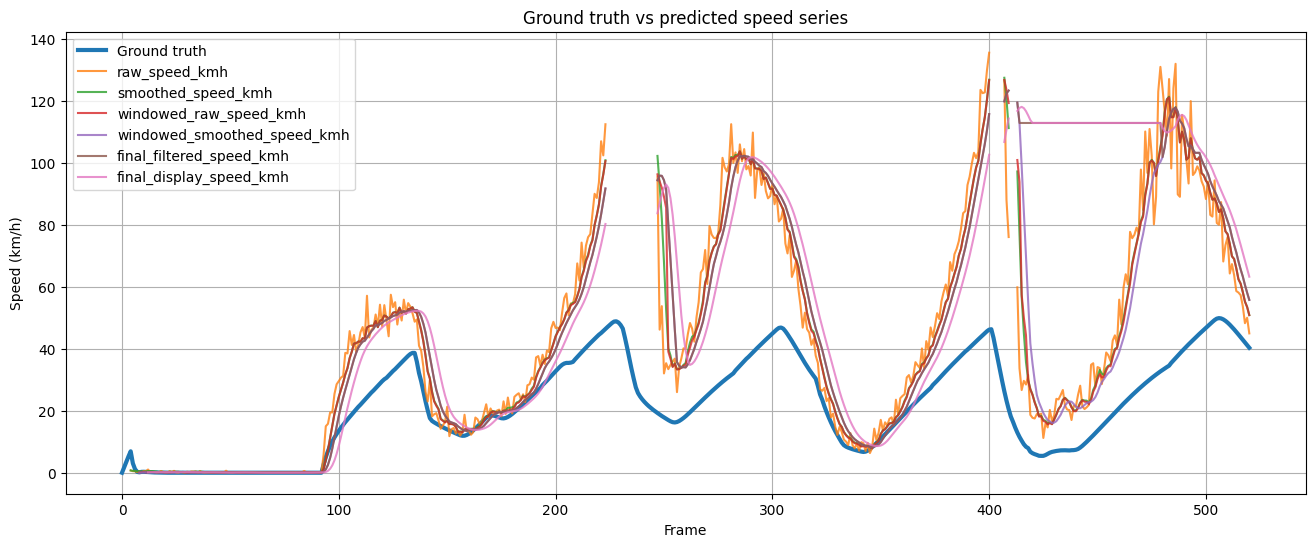

In [28]:
# ============================================================
# Cell 20: Plot Speed Curves
# This plot will immediately show whether the main issue is:
# - constant scale inflation
# - lag
# - jitter
# - certain post-processing stages blowing up the values
# ============================================================

plt.figure(figsize=(16, 6))
plt.plot(compare_df["frame_idx"], compare_df["gt_speed_kmh"], label="Ground truth", linewidth=3)

for col in speed_cols:
    plt.plot(compare_df["frame_idx"], compare_df[col], label=col, alpha=0.8)

plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Ground truth vs predicted speed series")
plt.grid(True)
plt.legend()
plt.show()

In [29]:
# ============================================================
# Cell 21: Find Best Series
# ============================================================

def compute_metrics(df, gt_col, pred_col):
    sub = df[[gt_col, pred_col]].dropna().copy()
    if len(sub) == 0:
        return None

    err = sub[pred_col] - sub[gt_col]
    abs_err = np.abs(err)

    return {
        "series": pred_col,
        "n": len(sub),
        "mae_kmh": abs_err.mean(),
        "rmse_kmh": np.sqrt(np.mean(err ** 2)),
        "bias_kmh": err.mean(),
        "corr": sub[pred_col].corr(sub[gt_col]),
        "gt_mean_kmh": sub[gt_col].mean(),
        "pred_mean_kmh": sub[pred_col].mean(),
        "pred_max_kmh": sub[pred_col].max(),
    }

metrics = []
for col in speed_cols:
    m = compute_metrics(compare_df, "gt_speed_kmh", col)
    if m is not None:
        metrics.append(m)

metrics_df = pd.DataFrame(metrics).sort_values("mae_kmh")
metrics_df

,series,n,mae_kmh,rmse_kmh,bias_kmh,corr,gt_mean_kmh,pred_mean_kmh,pred_max_kmh
1,smoothed_speed_kmh,485,20.932063,31.074267,20.879321,0.866939,21.116309,41.995630,127.571864
3,windowed_smoothed_speed_kmh,481,21.033818,31.505719,20.897277,0.842489,21.268233,42.165510,123.435150
0,raw_speed_kmh,485,21.139650,31.501073,21.074883,0.867131,21.116309,42.191192,135.663385
2,windowed_raw_speed_kmh,481,21.141804,31.504533,21.118640,0.857988,21.268233,42.386872,126.865922
4,final_filtered_speed_kmh,477,30.872879,46.498193,30.737817,0.569084,21.444507,52.182324,123.435150
5,final_display_speed_kmh,477,30.874958,46.449888,30.361936,0.555178,21.444507,51.806444,118.173080


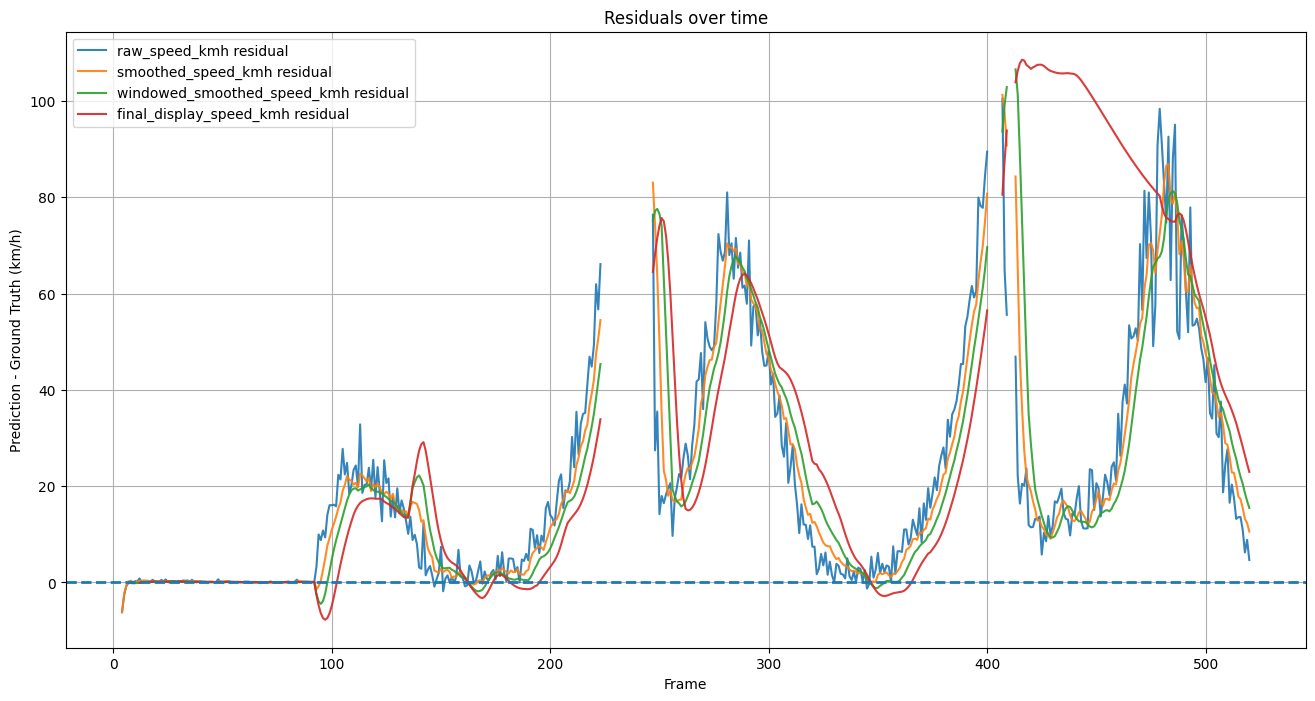

In [30]:
# ============================================================
# Cell 22: Plot Residuals
# If residual stays mostly positive, then the problem is not random noise. It is scale bias
# ============================================================

best_cols = [
    "raw_speed_kmh",
    "smoothed_speed_kmh",
    "windowed_smoothed_speed_kmh",
    "final_display_speed_kmh",
]

plt.figure(figsize=(16, 8))

for col in best_cols:
    residual = compare_df[col] - compare_df["gt_speed_kmh"]
    plt.plot(compare_df["frame_idx"], residual, label=f"{col} residual", alpha=0.9)

plt.axhline(0, linestyle="--", linewidth=2)
plt.xlabel("Frame")
plt.ylabel("Prediction - Ground Truth (km/h)")
plt.title("Residuals over time")
plt.grid(True)
plt.legend()
plt.show()

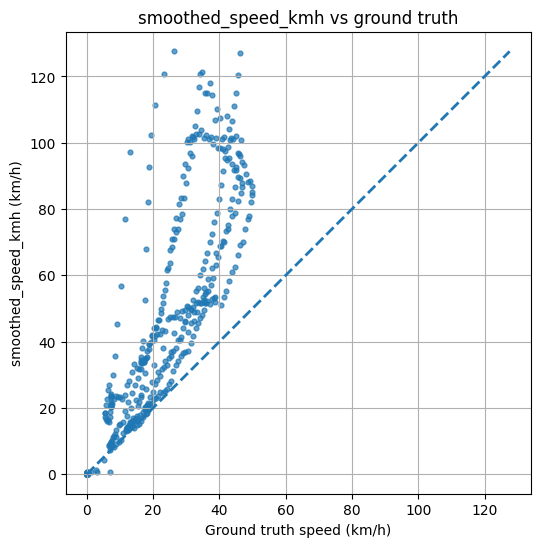

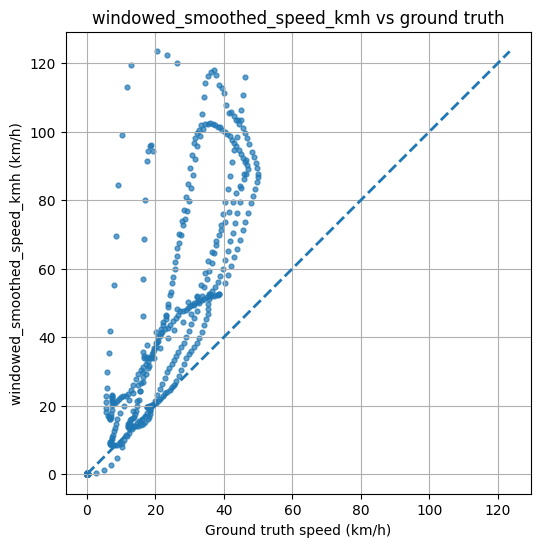

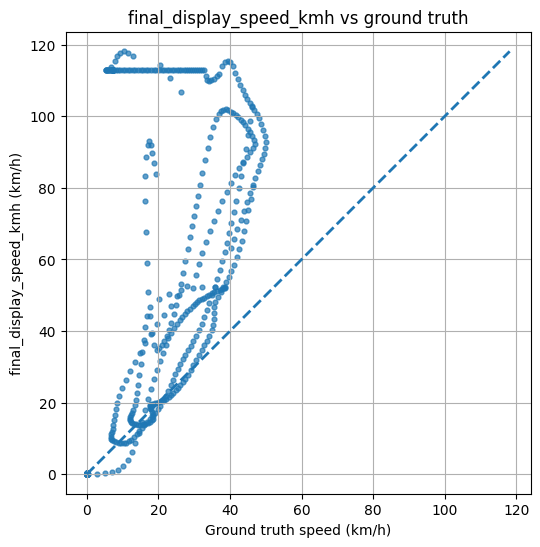

In [31]:
# ============================================================
# Cell 23: Scatter Plot Against Ground Truths
# If the points roughly form a straight line above the diagonal, that means the model is capturing trend but with the wrong scale
# ============================================================

plot_cols = [
    "smoothed_speed_kmh",
    "windowed_smoothed_speed_kmh",
    "final_display_speed_kmh",
]

for col in plot_cols:
    sub = compare_df[["gt_speed_kmh", col]].dropna()
    if len(sub) == 0:
        continue

    plt.figure(figsize=(6, 6))
    plt.scatter(sub["gt_speed_kmh"], sub[col], s=12, alpha=0.7)
    max_v = max(sub["gt_speed_kmh"].max(), sub[col].max())
    plt.plot([0, max_v], [0, max_v], linestyle="--", linewidth=2)
    plt.xlabel("Ground truth speed (km/h)")
    plt.ylabel(f"{col} (km/h)")
    plt.title(f"{col} vs ground truth")
    plt.grid(True)
    plt.axis("equal")
    plt.show()

In [32]:
# ============================================================
# Cell 24: Choose the best base prediction series
# Purpose:
# - avoid using final_display_speed_kmh for calibration experiments
# - use the best intermediate series instead
# ============================================================

BEST_BASE_COL = "smoothed_speed_kmh"
GT_COL = "gt_speed_kmh"

base_df = compare_df[["frame_idx", GT_COL, BEST_BASE_COL]].dropna().copy()

print("Using base series:", BEST_BASE_COL)
print("Rows:", len(base_df))
print(base_df.head())

Using base series: smoothed_speed_kmh
Rows: 485
   frame_idx  gt_speed_kmh  smoothed_speed_kmh
4          4          6.92            0.733860
5          5          3.04            0.616040
6          6          1.17            0.567105
7          7          0.26            0.470741
8          8          0.14            0.464613


In [33]:
# ============================================================
# Cell 25: Fit affine correction (ground truth ~ a * pred + b)
# Purpose:
# - quantify scale + offset mismatch
# - create a corrected speed series for comparison
# ============================================================

import numpy as np

x = base_df[BEST_BASE_COL].to_numpy(dtype=np.float64)
y = base_df[GT_COL].to_numpy(dtype=np.float64)

a, b = np.polyfit(x, y, 1)

base_df["affine_corrected_kmh"] = a * base_df[BEST_BASE_COL] + b

print(f"Affine correction:")
print(f"  gt ≈ {a:.6f} * {BEST_BASE_COL} + {b:.6f}")

Affine correction:
  gt ≈ 0.375625 * smoothed_speed_kmh + 5.341696


In [34]:
# ============================================================
# Cell 26: Compare metrics before and after affine correction
# ============================================================

def compute_metrics_from_arrays(gt, pred, name="series"):
    gt = np.asarray(gt, dtype=np.float64)
    pred = np.asarray(pred, dtype=np.float64)

    mask = np.isfinite(gt) & np.isfinite(pred)
    gt = gt[mask]
    pred = pred[mask]

    err = pred - gt
    abs_err = np.abs(err)

    return {
        "series": name,
        "n": len(gt),
        "mae_kmh": abs_err.mean(),
        "rmse_kmh": np.sqrt(np.mean(err ** 2)),
        "bias_kmh": err.mean(),
        "corr": np.corrcoef(gt, pred)[0, 1],
        "gt_mean_kmh": gt.mean(),
        "pred_mean_kmh": pred.mean(),
        "pred_max_kmh": pred.max(),
    }

before_metrics = compute_metrics_from_arrays(
    base_df[GT_COL],
    base_df[BEST_BASE_COL],
    name=f"{BEST_BASE_COL} (original)"
)

after_metrics = compute_metrics_from_arrays(
    base_df[GT_COL],
    base_df["affine_corrected_kmh"],
    name=f"{BEST_BASE_COL} (affine corrected)"
)

import pandas as pd
pd.DataFrame([before_metrics, after_metrics])

,series,n,mae_kmh,rmse_kmh,bias_kmh,corr,gt_mean_kmh,pred_mean_kmh,pred_max_kmh
0,smoothed_speed_kmh (original),485,20.932063,31.074267,2.087932e+01,0.866939,21.116309,41.995630,127.571864
1,smoothed_speed_kmh (affine corrected),485,6.125636,7.522716,1.382995e-14,0.866939,21.116309,21.116309,53.260892


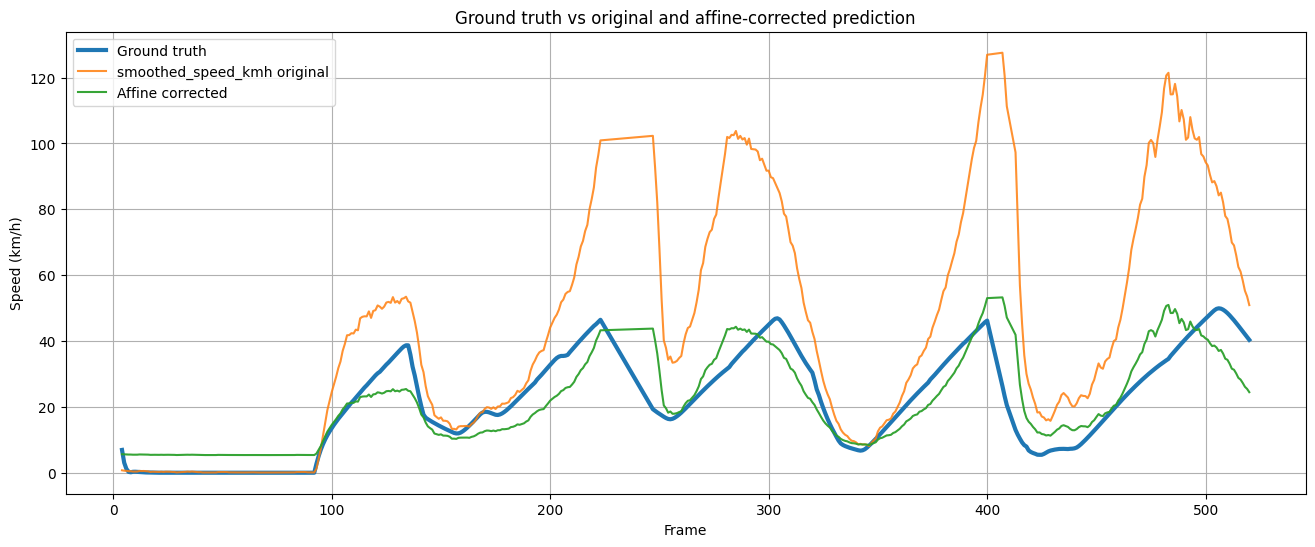

In [35]:
# ============================================================
# Cell 27: Plot original vs affine-corrected speed
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
plt.plot(base_df["frame_idx"], base_df[GT_COL], label="Ground truth", linewidth=3)
plt.plot(base_df["frame_idx"], base_df[BEST_BASE_COL], label=f"{BEST_BASE_COL} original", alpha=0.85)
plt.plot(base_df["frame_idx"], base_df["affine_corrected_kmh"], label="Affine corrected", alpha=0.95)

plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Ground truth vs original and affine-corrected prediction")
plt.grid(True)
plt.legend()
plt.show()

In [36]:
# ============================================================
# Cell 28: Test frame shift / lag
# Purpose:
# - see whether prediction aligns better if shifted in time
# ============================================================

def lag_search(df, gt_col, pred_col, max_shift=20):
    results = []

    for shift in range(-max_shift, max_shift + 1):
        temp = df[["frame_idx", gt_col, pred_col]].copy()

        if shift > 0:
            temp["pred_shifted"] = temp[pred_col].shift(shift)
        elif shift < 0:
            temp["pred_shifted"] = temp[pred_col].shift(shift)
        else:
            temp["pred_shifted"] = temp[pred_col]

        sub = temp[[gt_col, "pred_shifted"]].dropna()
        if len(sub) == 0:
            continue

        err = sub["pred_shifted"] - sub[gt_col]
        mae = np.mean(np.abs(err))
        corr = sub["pred_shifted"].corr(sub[gt_col])

        results.append({
            "shift_frames": shift,
            "n": len(sub),
            "mae_kmh": mae,
            "corr": corr,
        })

    return pd.DataFrame(results)

lag_df = lag_search(compare_df, GT_COL, BEST_BASE_COL, max_shift=20)
lag_df.sort_values("mae_kmh").head(10)

,shift_frames,n,mae_kmh,corr
26,6,479,20.549381,0.843061
25,5,480,20.551891,0.851668
27,7,478,20.557136,0.832947
24,4,481,20.573821,0.858462
28,8,477,20.574448,0.821294
29,9,476,20.611155,0.808148
23,3,482,20.620759,0.863329
30,10,475,20.661565,0.793160
22,2,483,20.697487,0.866431
31,11,474,20.735346,0.776665


Best lag by MAE:
shift_frames      6.000000
n               479.000000
mae_kmh          20.549381
corr              0.843061
Name: 26, dtype: float64

Best lag by correlation:
shift_frames      1.000000
n               484.000000
mae_kmh          20.806344
corr              0.867660
Name: 21, dtype: float64


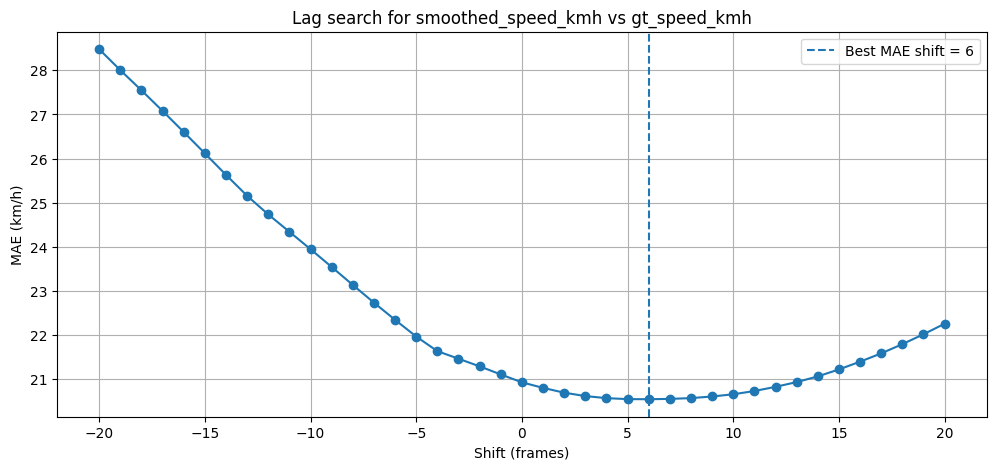

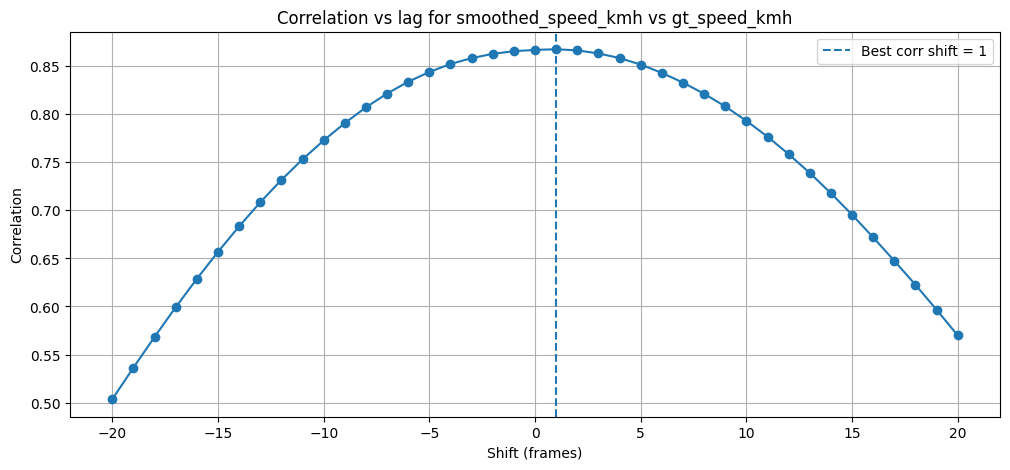

In [37]:
# ============================================================
# Cell 29: Plot lag-search result
# Purpose:
# - visualize whether a frame shift improves alignment
# - identify best shift by MAE and correlation
# ============================================================

import matplotlib.pyplot as plt

assert "lag_df" in globals(), "Run Cell 28 first."

lag_df = lag_df.sort_values("shift_frames").reset_index(drop=True)

best_mae_row = lag_df.loc[lag_df["mae_kmh"].idxmin()]
best_corr_row = lag_df.loc[lag_df["corr"].idxmax()]

print("Best lag by MAE:")
print(best_mae_row)
print("")
print("Best lag by correlation:")
print(best_corr_row)

plt.figure(figsize=(12, 5))
plt.plot(lag_df["shift_frames"], lag_df["mae_kmh"], marker="o")
plt.axvline(best_mae_row["shift_frames"], linestyle="--", label=f"Best MAE shift = {int(best_mae_row['shift_frames'])}")
plt.xlabel("Shift (frames)")
plt.ylabel("MAE (km/h)")
plt.title(f"Lag search for {BEST_BASE_COL} vs {GT_COL}")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(lag_df["shift_frames"], lag_df["corr"], marker="o")
plt.axvline(best_corr_row["shift_frames"], linestyle="--", label=f"Best corr shift = {int(best_corr_row['shift_frames'])}")
plt.xlabel("Shift (frames)")
plt.ylabel("Correlation")
plt.title(f"Correlation vs lag for {BEST_BASE_COL} vs {GT_COL}")
plt.grid(True)
plt.legend()
plt.show()

In [38]:
# ============================================================
# Cell 30: Apply best lag and compare metrics
# Purpose:
# - create lag-adjusted version of the best base series
# - compare original vs lag-adjusted metrics
# ============================================================

BEST_SHIFT = int(best_mae_row["shift_frames"])
print("Applying best shift:", BEST_SHIFT)

lag_base_df = compare_df[["frame_idx", GT_COL, BEST_BASE_COL]].copy()

# Positive shift means compare current GT to earlier pred samples
lag_base_df["lag_adjusted_kmh"] = lag_base_df[BEST_BASE_COL].shift(BEST_SHIFT)

lag_base_df = lag_base_df.dropna().copy()

orig_metrics_lag_space = compute_metrics_from_arrays(
    lag_base_df[GT_COL],
    lag_base_df[BEST_BASE_COL],
    name=f"{BEST_BASE_COL} (same rows as lag-adjusted)"
)

lag_metrics = compute_metrics_from_arrays(
    lag_base_df[GT_COL],
    lag_base_df["lag_adjusted_kmh"],
    name=f"{BEST_BASE_COL} (lag adjusted)"
)

import pandas as pd
pd.DataFrame([orig_metrics_lag_space, lag_metrics])

Applying best shift: 6


,series,n,mae_kmh,rmse_kmh,bias_kmh,corr,gt_mean_kmh,pred_mean_kmh,pred_max_kmh
0,smoothed_speed_kmh (same rows as lag-adjusted),467,20.209706,29.882962,20.194388,0.887132,21.467238,41.661625,126.955857
1,smoothed_speed_kmh (lag adjusted),467,19.575224,29.520656,18.801994,0.842170,21.467238,40.269232,127.571864


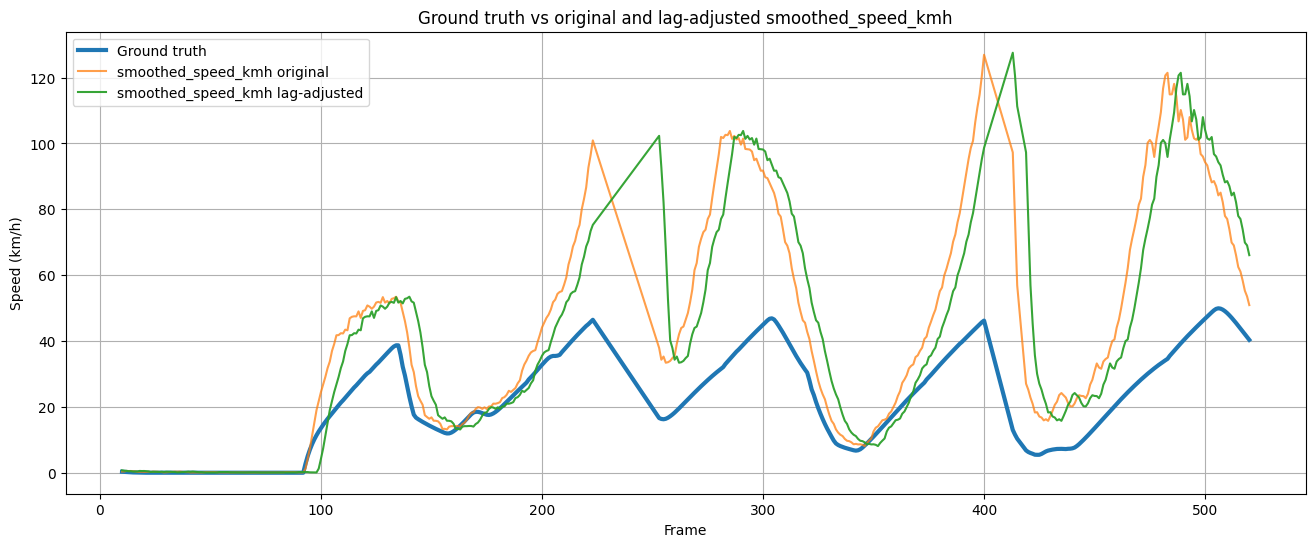

In [39]:
# ============================================================
# Cell 31: Plot original vs lag-adjusted prediction
# Purpose:
# - visually check whether timing misalignment is significant
# ============================================================

plt.figure(figsize=(16, 6))
plt.plot(lag_base_df["frame_idx"], lag_base_df[GT_COL], label="Ground truth", linewidth=3)
plt.plot(lag_base_df["frame_idx"], lag_base_df[BEST_BASE_COL], label=f"{BEST_BASE_COL} original", alpha=0.75)
plt.plot(lag_base_df["frame_idx"], lag_base_df["lag_adjusted_kmh"], label=f"{BEST_BASE_COL} lag-adjusted", alpha=0.95)

plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title(f"Ground truth vs original and lag-adjusted {BEST_BASE_COL}")
plt.grid(True)
plt.legend()
plt.show()

In [40]:
# ============================================================
# Cell 32: Combine lag + affine correction
# Purpose:
# - test whether time alignment + scale correction explains most error
# ============================================================

x_lag = lag_base_df["lag_adjusted_kmh"].to_numpy(dtype=np.float64)
y_lag = lag_base_df[GT_COL].to_numpy(dtype=np.float64)

a_lag, b_lag = np.polyfit(x_lag, y_lag, 1)
lag_base_df["lag_affine_corrected_kmh"] = a_lag * lag_base_df["lag_adjusted_kmh"] + b_lag

print(f"Lag + affine correction:")
print(f"  gt ≈ {a_lag:.6f} * lag_adjusted + {b_lag:.6f}")

lag_affine_metrics = compute_metrics_from_arrays(
    lag_base_df[GT_COL],
    lag_base_df["lag_affine_corrected_kmh"],
    name=f"{BEST_BASE_COL} (lag + affine corrected)"
)

pd.DataFrame([
    orig_metrics_lag_space,
    lag_metrics,
    lag_affine_metrics
])

Lag + affine correction:
  gt ≈ 0.375803 * lag_adjusted + 6.333930


,series,n,mae_kmh,rmse_kmh,bias_kmh,corr,gt_mean_kmh,pred_mean_kmh,pred_max_kmh
0,smoothed_speed_kmh (same rows as lag-adjusted),467,20.209706,29.882962,2.019439e+01,0.887132,21.467238,41.661625,126.955857
1,smoothed_speed_kmh (lag adjusted),467,19.575224,29.520656,1.880199e+01,0.842170,21.467238,40.269232,127.571864
2,smoothed_speed_kmh (lag + affine corrected),467,6.468387,8.185804,-1.058967e-14,0.842170,21.467238,21.467238,54.275848


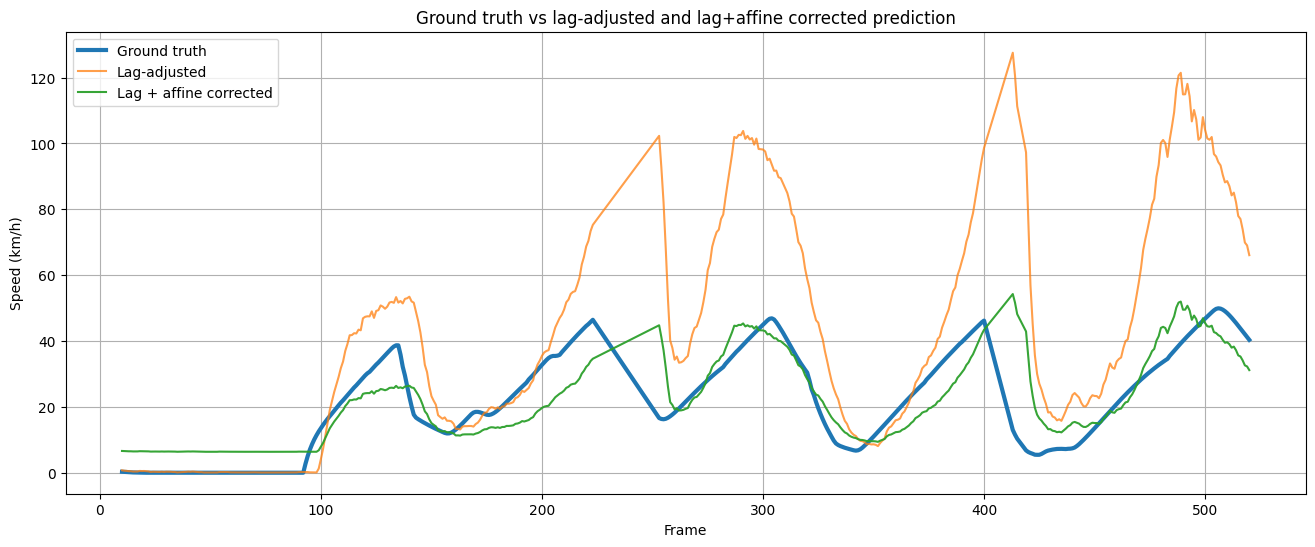

In [41]:
# ============================================================
# Cell 33: Plot lag + affine corrected curve
# Purpose:
# - see whether a simple calibrated correction explains the mismatch
# ============================================================

plt.figure(figsize=(16, 6))
plt.plot(lag_base_df["frame_idx"], lag_base_df[GT_COL], label="Ground truth", linewidth=3)
plt.plot(lag_base_df["frame_idx"], lag_base_df["lag_adjusted_kmh"], label="Lag-adjusted", alpha=0.75)
plt.plot(lag_base_df["frame_idx"], lag_base_df["lag_affine_corrected_kmh"], label="Lag + affine corrected", alpha=0.95)

plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Ground truth vs lag-adjusted and lag+affine corrected prediction")
plt.grid(True)
plt.legend()
plt.show()

In [42]:
# ============================================================
# Cell 34: Direct comparison - affine only vs lag + affine
# Purpose:
# - confirm which correction strategy is better
# - keep one clear table for decision-making
# ============================================================

comparison_rows = [
    {
        "method": "affine_only",
        "mae_kmh": 6.125636,
        "rmse_kmh": 7.522716,
        "corr": 0.866939,
    },
    {
        "method": "lag_plus_affine",
        "mae_kmh": 6.468387,
        "rmse_kmh": 8.185804,
        "corr": 0.842170,
    },
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df["mae_rank"] = comparison_df["mae_kmh"].rank(method="dense")
comparison_df["rmse_rank"] = comparison_df["rmse_kmh"].rank(method="dense")
comparison_df["corr_rank"] = comparison_df["corr"].rank(ascending=False, method="dense")

comparison_df = comparison_df.sort_values(["mae_kmh", "rmse_kmh", "corr"], ascending=[True, True, False])
comparison_df

,method,mae_kmh,rmse_kmh,corr,mae_rank,rmse_rank,corr_rank
0,affine_only,6.125636,7.522716,0.866939,1.0,1.0,1.0
1,lag_plus_affine,6.468387,8.185804,0.842170,2.0,2.0,2.0


In [43]:
# ============================================================
# Cell 35: Set up representative-point experiment comparison
# Purpose:
# - preserve the current CENTER-based comparison as baseline
# - define the video / GT inputs for rerunning with BOTTOM_CENTER
# - keep all comparison inputs in one place
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

# -----------------------------
# 1) Paths
# -----------------------------
VIDEO_PATH_EXPERIMENT = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "carla_rgb_speeds.mp4"
GT_CSV_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "carla_rgb_speeds.csv"

assert VIDEO_PATH_EXPERIMENT.exists(), f"Missing video: {VIDEO_PATH_EXPERIMENT}"
assert GT_CSV_PATH.exists(), f"Missing GT CSV: {GT_CSV_PATH}"

# -----------------------------
# 2) Preserve current CENTER baseline from existing compare_df
# -----------------------------
assert "compare_df" in globals(), "compare_df not found. Run your CSV comparison cells first."

CENTER_BASELINE_DF = compare_df.copy()
CENTER_BASELINE_LABEL = "center"

# We will compare the same 'best base' series for both modes
BEST_COMPARE_COL = "smoothed_speed_kmh"
GT_COL = "gt_speed_kmh"

print("=== Cell 35: Experiment Setup ===")
print("Video path              :", VIDEO_PATH_EXPERIMENT)
print("GT CSV path             :", GT_CSV_PATH)
print("Baseline mode preserved :", CENTER_BASELINE_LABEL)
print("Comparison column       :", BEST_COMPARE_COL)
print("GT column               :", GT_COL)
print("Baseline rows           :", len(CENTER_BASELINE_DF))
print("=================================")

=== Cell 35: Experiment Setup ===
Video path              : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\carla_rgb_speeds.mp4
GT CSV path             : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\carla_rgb_speeds.csv
Baseline mode preserved : center
Comparison column       : smoothed_speed_kmh
GT column               : gt_speed_kmh
Baseline rows           : 521


In [44]:
# ============================================================
# Cell 36: Define a reusable rerun function for representative-point mode
# Purpose:
# - rerun the speed-estimation pass with a chosen representative point
# - regenerate per-frame predictions
# - merge them with ground truth for fair comparison
#
# Notes:
# - This is the important "Cell 18-like" rerun.
# - It reuses your existing helpers/state from earlier cells.
# ============================================================

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

def run_representative_point_experiment(
    representative_point_mode="bottom_center",
    video_path=VIDEO_PATH_EXPERIMENT,
    gt_csv_path=GT_CSV_PATH,
    det_every_n=1,
    det_threshold=0.30,
    min_box_area=30 * 30,
    output_csv_path=None,
):
    global REPRESENTATIVE_POINT_MODE

    # -----------------------------
    # 1) Set representative-point mode
    # -----------------------------
    old_mode = REPRESENTATIVE_POINT_MODE
    REPRESENTATIVE_POINT_MODE = representative_point_mode

    # -----------------------------
    # 2) Reset tracker and state
    # -----------------------------
    assert "TRACKER" in globals(), "Run Cell 3 first."
    assert "TRACK_HISTORIES" in globals(), "Run Cell 10 first."

    if hasattr(TRACKER, "reset"):
        TRACKER.reset()

    TRACK_HISTORIES.clear()
    FINISHED_TRACK_HISTORIES.clear()
    TRACK_LAST_SEEN_FRAME.clear()
    TRACK_STATUS.clear()

    track_meta = {}

    def build_tensors_from_detections_local(detections: "sv.Detections") -> np.ndarray:
        if len(detections) == 0:
            return np.zeros((0, 5), dtype=np.float32)
        return np.hstack([
            detections.xyxy.astype(np.float32),
            detections.confidence.reshape(-1, 1).astype(np.float32),
        ])

    def active_tracks_to_boxes_and_ids_local(tracker):
        tracks = getattr(tracker, "tracked_tracks", [])
        boxes, ids = [], []
        for t in tracks:
            boxes.append(np.array(t.tlbr, dtype=np.float32))
            ids.append(int(t.external_track_id))
        return boxes, ids

    # -----------------------------
    # 3) Open video
    # -----------------------------
    cap = cv2.VideoCapture(str(video_path))
    assert cap.isOpened(), f"Could not open video: {video_path}"

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 1:
        fps = FPS

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    try:
        if hasattr(TRACKER, "frame_rate"):
            TRACKER.frame_rate = int(round(fps))
    except Exception:
        pass

    # -----------------------------
    # 4) Main pass: collect histories
    # -----------------------------
    pbar = tqdm(total=total_frames, desc=f"Rep-point experiment: {representative_point_mode}")

    for frame_idx in range(total_frames):
        ok, frame_bgr = cap.read()
        if not ok:
            break

        if frame_idx % det_every_n == 0:
            temp_path = "temp_frame_rep_point_experiment.jpg"
            cv2.imwrite(temp_path, frame_bgr)

            det = DETECTOR.predict(temp_path, threshold=det_threshold)
            detections = rfdetr_to_sv_detections(det, min_conf=det_threshold)

            if len(detections) > 0:
                xyxy = detections.xyxy
                areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
                keep = areas >= min_box_area
                detections = detections[keep]

            tensors = build_tensors_from_detections_local(detections)
            _ = TRACKER.update_with_tensors(tensors)

            det_with_ids = TRACKER.update_with_detections(detections)
            if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
                for i in range(len(det_with_ids)):
                    tid = int(det_with_ids.tracker_id[i])
                    cls = int(det_with_ids.class_id[i])
                    conf = float(det_with_ids.confidence[i])
                    track_meta[tid] = (cls, conf)
        else:
            _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

        boxes, ids = active_tracks_to_boxes_and_ids_local(TRACKER)
        active_ids_this_frame = set()

        for box, tid in zip(boxes, ids):
            active_ids_this_frame.add(int(tid))
            cls, conf = track_meta.get(tid, (-1, 0.0))

            if cls in SPEED_ESTIMATION_CLASS_IDS:
                touches_border = bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX)

                if not touches_border:
                    hist = get_or_create_track_history(tid, speed_window=DEFAULT_SPEED_WINDOW)
                    append_track_observation(
                        track_history=hist,
                        frame_idx=frame_idx,
                        box_xyxy=box,
                        class_id=cls,
                        confidence=conf,
                        fps=fps,
                    )

            mark_track_observed(tid, frame_idx)

        update_missing_tracks(active_ids_this_frame, frame_idx, max_missing_frames=MAX_MISSING_FRAMES)
        pbar.update(1)

    pbar.close()
    cap.release()

    # -----------------------------
    # 5) Build observation dataframe from track histories
    # -----------------------------
    rows = []
    for tid, hist in TRACK_HISTORIES.items():
        n = len(hist["frames"])
        for i in range(n):
            rows.append({
                "track_id": tid,
                "frame_idx": hist["frames"][i],
                "class_id": hist["class_id"],
                "confidence": hist["confidence"],
                "raw_speed_kmh": hist["raw_speeds_kmh"][i] if i < len(hist["raw_speeds_kmh"]) else None,
                "smoothed_speed_kmh": hist["smoothed_speeds_kmh"][i] if i < len(hist["smoothed_speeds_kmh"]) else None,
                "rep_point_mode": representative_point_mode,
            })

    obs_df = pd.DataFrame(rows).sort_values(["track_id", "frame_idx"]).reset_index(drop=True)

    # -----------------------------
    # 6) Optional save
    # -----------------------------
    if output_csv_path is not None:
        output_csv_path = Path(output_csv_path)
        output_csv_path.parent.mkdir(parents=True, exist_ok=True)
        obs_df.to_csv(output_csv_path, index=False)

    # -----------------------------
    # 7) Merge with GT for the main track
    # -----------------------------
    gt_df_local = pd.read_csv(gt_csv_path).rename(columns={
        "frame": "frame_idx",
        "speed_kmh": "gt_speed_kmh"
    })

    # pick track with most observations
    if len(obs_df) == 0:
        raise ValueError(f"No observations were generated for mode={representative_point_mode}")

    track_counts = obs_df.groupby("track_id").size().sort_values(ascending=False)
    best_track_id = int(track_counts.index[0])

    pred_df_local = obs_df[obs_df["track_id"] == best_track_id].copy()

    merged_df = gt_df_local.merge(
        pred_df_local[["frame_idx", "raw_speed_kmh", "smoothed_speed_kmh"]],
        on="frame_idx",
        how="left"
    )

    # restore prior mode so notebook state is not silently changed forever
    REPRESENTATIVE_POINT_MODE = old_mode

    return {
        "mode": representative_point_mode,
        "best_track_id": best_track_id,
        "observations_df": obs_df,
        "pred_df": pred_df_local,
        "compare_df": merged_df,
        "track_counts": track_counts,
    }

In [45]:
# ============================================================
# Cell 37: Run the BOTTOM_CENTER experiment
# Purpose:
# - rerun the speed pipeline using bottom_center
# - produce a fresh compare_df for later center vs bottom_center plots
# ============================================================

BOTTOM_CENTER_RESULTS = run_representative_point_experiment(
    representative_point_mode="bottom_center",
    video_path=VIDEO_PATH_EXPERIMENT,
    gt_csv_path=GT_CSV_PATH,
    output_csv_path=Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "bottom_center_track_observations.csv",
)

BOTTOM_CENTER_COMPARE_DF = BOTTOM_CENTER_RESULTS["compare_df"].copy()
BOTTOM_CENTER_PRED_DF = BOTTOM_CENTER_RESULTS["pred_df"].copy()

print("=== Cell 37: Bottom-center rerun complete ===")
print("Best track ID           :", BOTTOM_CENTER_RESULTS["best_track_id"])
print("Track counts:")
print(BOTTOM_CENTER_RESULTS["track_counts"].head())
print("")
print("Bottom-center compare rows:", len(BOTTOM_CENTER_COMPARE_DF))
print(BOTTOM_CENTER_COMPARE_DF.head())
print("=============================================")

Rep-point experiment: bottom_center:   0%|          | 0/521 [00:00<?, ?it/s]

=== Cell 37: Bottom-center rerun complete ===
Best track ID           : 1
Track counts:
track_id
1    486
dtype: int64

Bottom-center compare rows: 521
   frame_idx  gt_speed_kmh  raw_speed_kmh  smoothed_speed_kmh
0          0          0.00            NaN                 NaN
1          1          1.76            NaN                 NaN
2          2          3.53            NaN                 NaN
3          3          5.29            NaN                 NaN
4          4          6.92       0.747865            0.747865


In [46]:
# ============================================================
# Cell 38: Load / build bottom_center comparison dataframe
# Purpose:
# - ensure we have a bottom_center compare dataframe even if the
#   in-memory experiment object is gone
# - merge bottom_center predictions with ground truth
# ============================================================

import pandas as pd
from pathlib import Path

GT_CSV_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "carla_rgb_speeds.csv"
BOTTOM_CENTER_OBS_CSV_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "bottom_center_track_observations.csv"

assert GT_CSV_PATH.exists(), f"Missing GT CSV: {GT_CSV_PATH}"
assert BOTTOM_CENTER_OBS_CSV_PATH.exists(), f"Missing bottom-center CSV: {BOTTOM_CENTER_OBS_CSV_PATH}"
assert "CENTER_BASELINE_DF" in globals(), "Run Cell 35 first so the center baseline is preserved."

gt_df_bc = pd.read_csv(GT_CSV_PATH).rename(columns={
    "frame": "frame_idx",
    "speed_kmh": "gt_speed_kmh"
})

bottom_obs_df = pd.read_csv(BOTTOM_CENTER_OBS_CSV_PATH)

# Pick the track with the most observations
track_counts_bc = bottom_obs_df.groupby("track_id").size().sort_values(ascending=False)
best_track_id_bc = int(track_counts_bc.index[0])

bottom_pred_df = bottom_obs_df[bottom_obs_df["track_id"] == best_track_id_bc].copy()

BOTTOM_CENTER_COMPARE_DF = gt_df_bc.merge(
    bottom_pred_df[["frame_idx", "raw_speed_kmh", "smoothed_speed_kmh"]],
    on="frame_idx",
    how="left"
)

print("=== Cell 38: Bottom-center compare dataframe ready ===")
print("Best bottom-center track ID:", best_track_id_bc)
print("Track counts:")
print(track_counts_bc.head())
print("")
print("Center baseline rows       :", len(CENTER_BASELINE_DF))
print("Bottom-center compare rows :", len(BOTTOM_CENTER_COMPARE_DF))
print(BOTTOM_CENTER_COMPARE_DF.head())
print("======================================================")

=== Cell 38: Bottom-center compare dataframe ready ===
Best bottom-center track ID: 1
Track counts:
track_id
1    486
dtype: int64

Center baseline rows       : 521
Bottom-center compare rows : 521
   frame_idx  gt_speed_kmh  raw_speed_kmh  smoothed_speed_kmh
0          0          0.00            NaN                 NaN
1          1          1.76            NaN                 NaN
2          2          3.53            NaN                 NaN
3          3          5.29            NaN                 NaN
4          4          6.92       0.747865            0.747865


In [47]:
# ============================================================
# Cell 39: Compute center vs bottom_center metrics
# Purpose:
# - compare the same speed column for both representative-point modes
# - decide which one is better before any further correction
# ============================================================

import numpy as np
import pandas as pd

COMPARE_COL = "smoothed_speed_kmh"
GT_COL = "gt_speed_kmh"

def compute_metrics_from_df(df, gt_col, pred_col, label):
    sub = df[[gt_col, pred_col]].dropna().copy()
    gt = sub[gt_col].to_numpy(dtype=np.float64)
    pred = sub[pred_col].to_numpy(dtype=np.float64)

    err = pred - gt
    abs_err = np.abs(err)

    return {
        "mode": label,
        "series": pred_col,
        "n": len(sub),
        "mae_kmh": float(abs_err.mean()),
        "rmse_kmh": float(np.sqrt(np.mean(err ** 2))),
        "bias_kmh": float(err.mean()),
        "corr": float(np.corrcoef(gt, pred)[0, 1]),
        "gt_mean_kmh": float(gt.mean()),
        "pred_mean_kmh": float(pred.mean()),
        "pred_max_kmh": float(pred.max()),
    }

center_metrics = compute_metrics_from_df(
    CENTER_BASELINE_DF,
    GT_COL,
    COMPARE_COL,
    label="center"
)

bottom_center_metrics = compute_metrics_from_df(
    BOTTOM_CENTER_COMPARE_DF,
    GT_COL,
    COMPARE_COL,
    label="bottom_center"
)

REP_POINT_COMPARISON_DF = pd.DataFrame([center_metrics, bottom_center_metrics])
REP_POINT_COMPARISON_DF = REP_POINT_COMPARISON_DF.sort_values(
    ["mae_kmh", "rmse_kmh", "corr"],
    ascending=[True, True, False]
).reset_index(drop=True)

print("=== Cell 39: Center vs Bottom-center comparison ===")
display(REP_POINT_COMPARISON_DF)

=== Cell 39: Center vs Bottom-center comparison ===


,mode,series,n,mae_kmh,rmse_kmh,bias_kmh,corr,gt_mean_kmh,pred_mean_kmh,pred_max_kmh
0,bottom_center,smoothed_speed_kmh,485,20.533845,30.149496,20.442115,0.871566,21.116309,41.558424,126.877444
1,center,smoothed_speed_kmh,485,20.932063,31.074267,20.879321,0.866939,21.116309,41.995630,127.571864


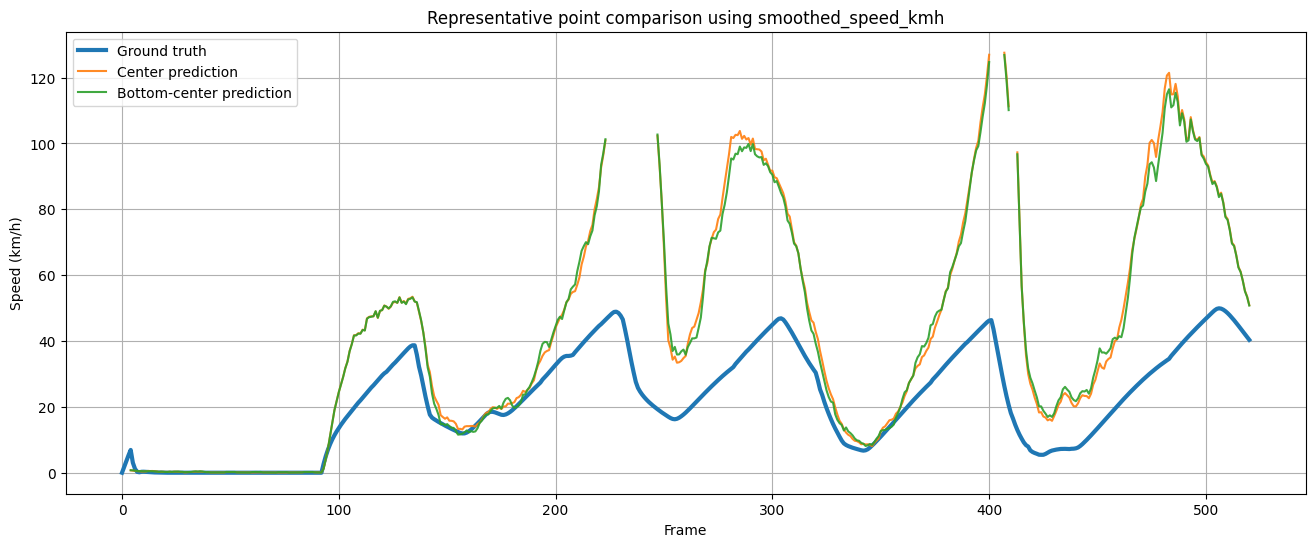

In [48]:
# ============================================================
# Cell 40: Plot center vs bottom_center against ground truth
# Purpose:
# - visually compare which representative point follows GT better
# - inspect scale bias and shape differences
# ============================================================

import matplotlib.pyplot as plt

center_plot_df = CENTER_BASELINE_DF[["frame_idx", GT_COL, COMPARE_COL]].copy()
center_plot_df = center_plot_df.rename(columns={COMPARE_COL: "center_pred_kmh"})

bottom_plot_df = BOTTOM_CENTER_COMPARE_DF[["frame_idx", GT_COL, COMPARE_COL]].copy()
bottom_plot_df = bottom_plot_df.rename(columns={COMPARE_COL: "bottom_center_pred_kmh"})

plot_df = center_plot_df.merge(
    bottom_plot_df[["frame_idx", "bottom_center_pred_kmh"]],
    on="frame_idx",
    how="outer"
).sort_values("frame_idx")

plt.figure(figsize=(16, 6))
plt.plot(plot_df["frame_idx"], plot_df[GT_COL], label="Ground truth", linewidth=3)
plt.plot(plot_df["frame_idx"], plot_df["center_pred_kmh"], label="Center prediction", alpha=0.9)
plt.plot(plot_df["frame_idx"], plot_df["bottom_center_pred_kmh"], label="Bottom-center prediction", alpha=0.9)

plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title(f"Representative point comparison using {COMPARE_COL}")
plt.grid(True)
plt.legend()
plt.show()

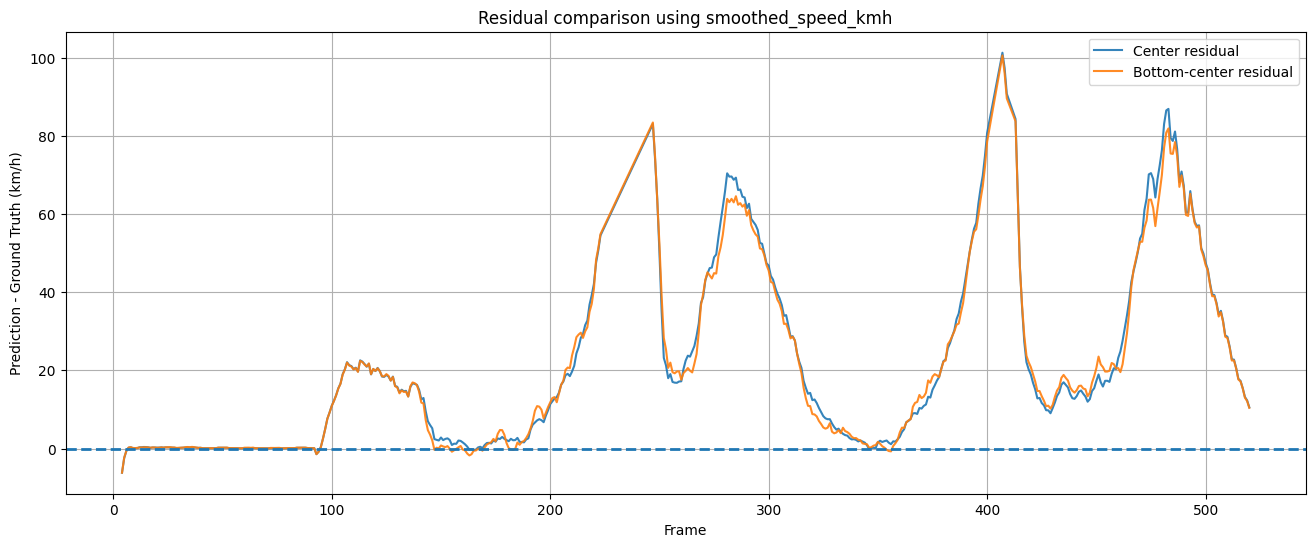

Residual summary:
  Center mean residual        : 20.879321 km/h
  Bottom-center mean residual : 20.442115 km/h


In [49]:
# ============================================================
# Cell 41: Residual comparison for center vs bottom_center
# Purpose:
# - compare prediction-minus-ground-truth residuals over time
# - see whether bottom_center reduces the positive bias consistently
# ============================================================

import matplotlib.pyplot as plt

RESIDUAL_COL = "smoothed_speed_kmh"
GT_COL = "gt_speed_kmh"

center_resid_df = CENTER_BASELINE_DF[["frame_idx", GT_COL, RESIDUAL_COL]].dropna().copy()
center_resid_df["residual_kmh"] = center_resid_df[RESIDUAL_COL] - center_resid_df[GT_COL]

bottom_resid_df = BOTTOM_CENTER_COMPARE_DF[["frame_idx", GT_COL, RESIDUAL_COL]].dropna().copy()
bottom_resid_df["residual_kmh"] = bottom_resid_df[RESIDUAL_COL] - bottom_resid_df[GT_COL]

plt.figure(figsize=(16, 6))
plt.plot(center_resid_df["frame_idx"], center_resid_df["residual_kmh"], label="Center residual", alpha=0.9)
plt.plot(bottom_resid_df["frame_idx"], bottom_resid_df["residual_kmh"], label="Bottom-center residual", alpha=0.9)
plt.axhline(0, linestyle="--", linewidth=2)

plt.xlabel("Frame")
plt.ylabel("Prediction - Ground Truth (km/h)")
plt.title(f"Residual comparison using {RESIDUAL_COL}")
plt.grid(True)
plt.legend()
plt.show()

print("Residual summary:")
print(f"  Center mean residual        : {center_resid_df['residual_kmh'].mean():.6f} km/h")
print(f"  Bottom-center mean residual : {bottom_resid_df['residual_kmh'].mean():.6f} km/h")

In [50]:
# ============================================================
# Cell 42: Fit affine correction for both center and bottom_center
# Purpose:
# - test whether each representative-point mode can be corrected well
# - compare the corrected versions fairly
# ============================================================

import numpy as np
import pandas as pd

COMPARE_COL = "smoothed_speed_kmh"
GT_COL = "gt_speed_kmh"

def fit_affine_and_apply(df, gt_col, pred_col, mode_label):
    sub = df[["frame_idx", gt_col, pred_col]].dropna().copy()

    x = sub[pred_col].to_numpy(dtype=np.float64)
    y = sub[gt_col].to_numpy(dtype=np.float64)

    a, b = np.polyfit(x, y, 1)
    corrected_col = f"{mode_label}_affine_corrected_kmh"
    sub[corrected_col] = a * sub[pred_col] + b

    metrics_original = compute_metrics_from_arrays(
        sub[gt_col].to_numpy(),
        sub[pred_col].to_numpy(),
        name=f"{mode_label} original"
    )

    metrics_corrected = compute_metrics_from_arrays(
        sub[gt_col].to_numpy(),
        sub[corrected_col].to_numpy(),
        name=f"{mode_label} affine corrected"
    )

    return {
        "mode": mode_label,
        "a": float(a),
        "b": float(b),
        "df": sub,
        "corrected_col": corrected_col,
        "metrics_original": metrics_original,
        "metrics_corrected": metrics_corrected,
    }

CENTER_AFFINE_RESULT = fit_affine_and_apply(
    CENTER_BASELINE_DF,
    GT_COL,
    COMPARE_COL,
    mode_label="center"
)

BOTTOM_CENTER_AFFINE_RESULT = fit_affine_and_apply(
    BOTTOM_CENTER_COMPARE_DF,
    GT_COL,
    COMPARE_COL,
    mode_label="bottom_center"
)

affine_metrics_df = pd.DataFrame([
    CENTER_AFFINE_RESULT["metrics_original"],
    CENTER_AFFINE_RESULT["metrics_corrected"],
    BOTTOM_CENTER_AFFINE_RESULT["metrics_original"],
    BOTTOM_CENTER_AFFINE_RESULT["metrics_corrected"],
]).sort_values(["mae_kmh", "rmse_kmh", "corr"], ascending=[True, True, False]).reset_index(drop=True)

print("Center affine fit:")
print(f"  gt ≈ {CENTER_AFFINE_RESULT['a']:.6f} * pred + {CENTER_AFFINE_RESULT['b']:.6f}")
print("")
print("Bottom-center affine fit:")
print(f"  gt ≈ {BOTTOM_CENTER_AFFINE_RESULT['a']:.6f} * pred + {BOTTOM_CENTER_AFFINE_RESULT['b']:.6f}")
print("")
display(affine_metrics_df)

Center affine fit:
  gt ≈ 0.375625 * pred + 5.341696

Bottom-center affine fit:
  gt ≈ 0.386408 * pred + 5.057820



,series,n,mae_kmh,rmse_kmh,bias_kmh,corr,gt_mean_kmh,pred_mean_kmh,pred_max_kmh
0,bottom_center affine corrected,485,6.048273,7.399930,1.828366e-14,0.871566,21.116309,21.116309,54.084223
1,center affine corrected,485,6.125636,7.522716,1.382995e-14,0.866939,21.116309,21.116309,53.260892
2,bottom_center original,485,20.533845,30.149496,2.044211e+01,0.871566,21.116309,41.558424,126.877444
3,center original,485,20.932063,31.074267,2.087932e+01,0.866939,21.116309,41.995630,127.571864


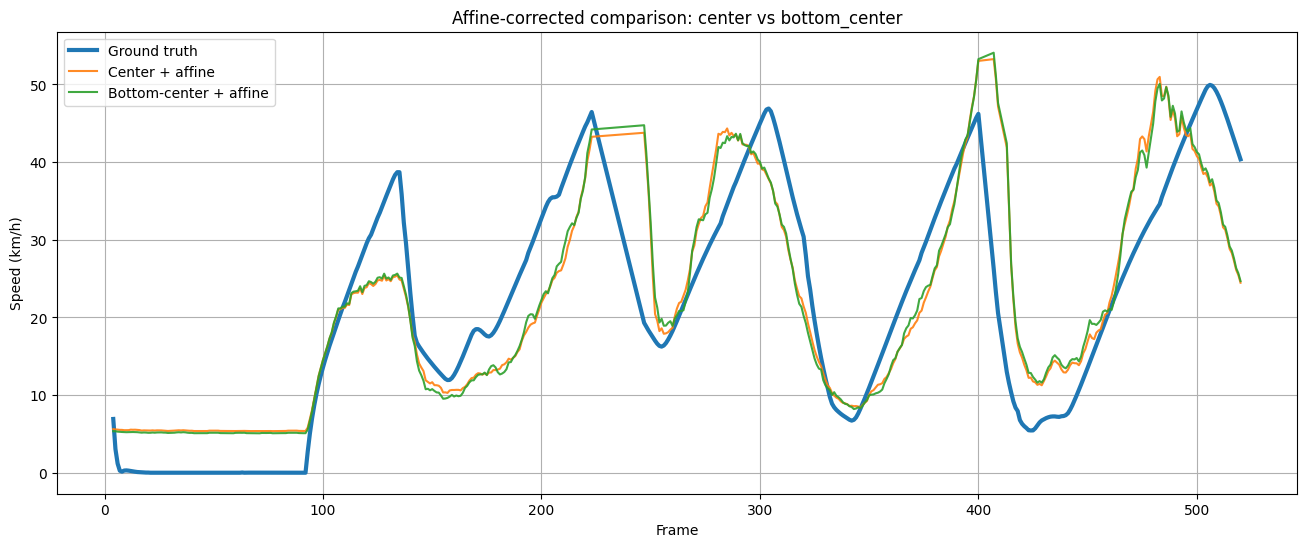

In [51]:
# ============================================================
# Cell 43: Plot affine-corrected center vs affine-corrected bottom_center
# Purpose:
# - compare the best corrected versions of both representative-point modes
# - decide which mode is the better basis before further experiments
# ============================================================

import matplotlib.pyplot as plt

center_aff_df = CENTER_AFFINE_RESULT["df"].copy()
center_corr_col = CENTER_AFFINE_RESULT["corrected_col"]

bottom_aff_df = BOTTOM_CENTER_AFFINE_RESULT["df"].copy()
bottom_corr_col = BOTTOM_CENTER_AFFINE_RESULT["corrected_col"]

plot_aff_df = center_aff_df[["frame_idx", GT_COL, center_corr_col]].merge(
    bottom_aff_df[["frame_idx", bottom_corr_col]],
    on="frame_idx",
    how="outer"
).sort_values("frame_idx")

plt.figure(figsize=(16, 6))
plt.plot(plot_aff_df["frame_idx"], plot_aff_df[GT_COL], label="Ground truth", linewidth=3)
plt.plot(plot_aff_df["frame_idx"], plot_aff_df[center_corr_col], label="Center + affine", alpha=0.9)
plt.plot(plot_aff_df["frame_idx"], plot_aff_df[bottom_corr_col], label="Bottom-center + affine", alpha=0.9)

plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Affine-corrected comparison: center vs bottom_center")
plt.grid(True)
plt.legend()
plt.show()

In [52]:
# ============================================================
# Cell 44: Formally pick the better representative-point mode
# Purpose:
# - choose the best mode using affine-corrected performance
# - store the winning corrected dataframe for export/comparison
# ============================================================

# We will choose based on the affine-corrected MAE first,
# then RMSE, then correlation.
affine_choice_df = affine_metrics_df.copy()

# Keep only corrected rows
affine_choice_df = affine_choice_df[
    affine_choice_df["series"].str.contains("affine corrected", case=False, na=False)
].copy()

affine_choice_df = affine_choice_df.sort_values(
    ["mae_kmh", "rmse_kmh", "corr"],
    ascending=[True, True, False]
).reset_index(drop=True)

BEST_REP_MODE = "bottom_center" if "bottom_center" in affine_choice_df.iloc[0]["series"] else "center"

if BEST_REP_MODE == "bottom_center":
    BEST_REP_RESULT = BOTTOM_CENTER_AFFINE_RESULT
else:
    BEST_REP_RESULT = CENTER_AFFINE_RESULT

BEST_REP_COMPARE_DF = BEST_REP_RESULT["df"].copy()
BEST_REP_CORRECTED_COL = BEST_REP_RESULT["corrected_col"]

print("=== Cell 44: Best representative-point mode selected ===")
display(affine_choice_df)

print("")
print("Selected BEST_REP_MODE     :", BEST_REP_MODE)
print("Corrected column           :", BEST_REP_CORRECTED_COL)
print("Rows in best compare df    :", len(BEST_REP_COMPARE_DF))
print("========================================================")

=== Cell 44: Best representative-point mode selected ===


,series,n,mae_kmh,rmse_kmh,bias_kmh,corr,gt_mean_kmh,pred_mean_kmh,pred_max_kmh
0,bottom_center affine corrected,485,6.048273,7.399930,1.828366e-14,0.871566,21.116309,21.116309,54.084223
1,center affine corrected,485,6.125636,7.522716,1.382995e-14,0.866939,21.116309,21.116309,53.260892



Selected BEST_REP_MODE     : bottom_center
Corrected column           : bottom_center_affine_corrected_kmh
Rows in best compare df    : 485


In [53]:
# ============================================================
# Cell 45: Export the winning corrected CSV for direct comparison
# Purpose:
# - save the best corrected per-frame series
# - make it easy to compare against ground truth or use in a fresh notebook
# ============================================================

from pathlib import Path
import pandas as pd

BEST_CORRECTED_EXPORT_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / f"{BEST_REP_MODE}_affine_corrected_vs_gt.csv"

export_df = BEST_REP_COMPARE_DF[["frame_idx", GT_COL, BEST_REP_CORRECTED_COL]].copy()
export_df = export_df.rename(columns={
    GT_COL: "gt_speed_kmh",
    BEST_REP_CORRECTED_COL: "pred_speed_kmh_affine_corrected"
})

export_df["rep_point_mode"] = BEST_REP_MODE
export_df["car_length_m"] = 4.79
export_df["car_width_m"] = 2.16
export_df["car_height_m"] = 1.49
export_df["camera_height_m"] = 25.0

BEST_CORRECTED_EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
export_df.to_csv(BEST_CORRECTED_EXPORT_PATH, index=False)

print("=== Cell 45: Export complete ===")
print("Saved corrected comparison CSV to:")
print(BEST_CORRECTED_EXPORT_PATH)
print("")
print(export_df.head())
print("================================")

=== Cell 45: Export complete ===
Saved corrected comparison CSV to:
C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\bottom_center_affine_corrected_vs_gt.csv

   frame_idx  gt_speed_kmh  pred_speed_kmh_affine_corrected rep_point_mode  \
4          4          6.92                         5.346801  bottom_center   
5          5          3.04                         5.338736  bottom_center   
6          6          1.17                         5.290658  bottom_center   
7          7          0.26                         5.263766  bottom_center   
8          8          0.14                         5.245721  bottom_center   

   car_length_m  car_width_m  car_height_m  camera_height_m  
4          4.79         2.16          1.49             25.0  
5          4.79         2.16          1.49             25.0  
6          4.79         2.16          1.49             25.0  
7          4.79         2.16          1.49             25.0  
8        

In [54]:
# ============================================================
# Cell 46: Final summary table for current best configuration
# Purpose:
# - summarize where we are before deeper geometry improvements
# - keep one compact notebook checkpoint
# ============================================================

summary_rows = [
    {
        "configuration": "center (original)",
        "mae_kmh": CENTER_AFFINE_RESULT["metrics_original"]["mae_kmh"],
        "rmse_kmh": CENTER_AFFINE_RESULT["metrics_original"]["rmse_kmh"],
        "corr": CENTER_AFFINE_RESULT["metrics_original"]["corr"],
    },
    {
        "configuration": "center + affine",
        "mae_kmh": CENTER_AFFINE_RESULT["metrics_corrected"]["mae_kmh"],
        "rmse_kmh": CENTER_AFFINE_RESULT["metrics_corrected"]["rmse_kmh"],
        "corr": CENTER_AFFINE_RESULT["metrics_corrected"]["corr"],
    },
    {
        "configuration": "bottom_center (original)",
        "mae_kmh": BOTTOM_CENTER_AFFINE_RESULT["metrics_original"]["mae_kmh"],
        "rmse_kmh": BOTTOM_CENTER_AFFINE_RESULT["metrics_original"]["rmse_kmh"],
        "corr": BOTTOM_CENTER_AFFINE_RESULT["metrics_original"]["corr"],
    },
    {
        "configuration": "bottom_center + affine",
        "mae_kmh": BOTTOM_CENTER_AFFINE_RESULT["metrics_corrected"]["mae_kmh"],
        "rmse_kmh": BOTTOM_CENTER_AFFINE_RESULT["metrics_corrected"]["rmse_kmh"],
        "corr": BOTTOM_CENTER_AFFINE_RESULT["metrics_corrected"]["corr"],
    },
]

checkpoint_df = pd.DataFrame(summary_rows).sort_values(
    ["mae_kmh", "rmse_kmh", "corr"],
    ascending=[True, True, False]
).reset_index(drop=True)

print("=== Cell 46: Current checkpoint summary ===")
display(checkpoint_df)

print("")
print("Best current configuration:", checkpoint_df.iloc[0]["configuration"])
print("Key takeaway: representative-point choice helps a little,")
print("but geometry/calibration is still the dominant source of error.")
print("==========================================")

=== Cell 46: Current checkpoint summary ===


,configuration,mae_kmh,rmse_kmh,corr
0,bottom_center + affine,6.048273,7.399930,0.871566
1,center + affine,6.125636,7.522716,0.866939
2,bottom_center (original),20.533845,30.149496,0.871566
3,center (original),20.932063,31.074267,0.866939



Best current configuration: bottom_center + affine
Key takeaway: representative-point choice helps a little,
but geometry/calibration is still the dominant source of error.


In [55]:
# ============================================================
# Cell 47: Experiment 1 - Extend representative-point logic
# Purpose:
# - support blended points between center and bottom_center
# - support small vertical offsets around the current best mode
# - keep the old logic intact for the rest of the notebook
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Save original function once so we can still reference it
# ------------------------------------------------------------
if "_ORIGINAL_REPRESENTATIVE_POINT_XYXY" not in globals():
    _ORIGINAL_REPRESENTATIVE_POINT_XYXY = representative_point_xyxy

# ------------------------------------------------------------
# Global experiment controls
# ------------------------------------------------------------
REP_POINT_BLEND_ALPHA = 1.0
REP_POINT_VERTICAL_OFFSET_PX = 0.0

def representative_point_xyxy(box_xyxy, mode=REPRESENTATIVE_POINT_MODE):
    """
    Extended representative-point selector.

    Supported modes:
      - "center"
      - "bottom_center"
      - "blend_center_bottom"
      - "bottom_center_offset"
    """
    box_xyxy = np.asarray(box_xyxy, dtype=np.float32)

    if mode == "center":
        return bbox_center_xyxy(box_xyxy)

    elif mode == "bottom_center":
        return bbox_bottom_center_xyxy(
            box_xyxy,
            y_offset_px=BOTTOM_CENTER_Y_OFFSET_PX
        )

    elif mode == "blend_center_bottom":
        center_pt = bbox_center_xyxy(box_xyxy)
        bottom_pt = bbox_bottom_center_xyxy(
            box_xyxy,
            y_offset_px=BOTTOM_CENTER_Y_OFFSET_PX
        )

        alpha = float(REP_POINT_BLEND_ALPHA)
        alpha = max(0.0, min(1.0, alpha))  # clamp to [0, 1]

        # alpha = 0 -> center
        # alpha = 1 -> bottom_center
        blended = (1.0 - alpha) * center_pt + alpha * bottom_pt
        return blended.astype(np.float32)

    elif mode == "bottom_center_offset":
        return bbox_bottom_center_xyxy(
            box_xyxy,
            y_offset_px=float(REP_POINT_VERTICAL_OFFSET_PX)
        )

    else:
        raise ValueError(f"Unsupported representative-point mode: {mode}")

print("=== Cell 47: Extended representative-point logic ready ===")
print("Supported modes:")
print("  - center")
print("  - bottom_center")
print("  - blend_center_bottom")
print("  - bottom_center_offset")
print("")
print("Current globals:")
print("  REP_POINT_BLEND_ALPHA      =", REP_POINT_BLEND_ALPHA)
print("  REP_POINT_VERTICAL_OFFSET_PX =", REP_POINT_VERTICAL_OFFSET_PX)
print("==========================================================")

=== Cell 47: Extended representative-point logic ready ===
Supported modes:
  - center
  - bottom_center
  - blend_center_bottom
  - bottom_center_offset

Current globals:
  REP_POINT_BLEND_ALPHA      = 1.0
  REP_POINT_VERTICAL_OFFSET_PX = 0.0


In [56]:
# ============================================================
# Cell 48: Define Experiment 1 sweep configs + runner
# Purpose:
# - run center / bottom_center / blended / offset experiments
# - merge each result with GT
# - compute metrics consistently
# ============================================================

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from pathlib import Path

# ------------------------------------------------------------
# 1) Sweep configuration
# ------------------------------------------------------------
EXPERIMENT1_CONFIGS = [
    {"label": "center",               "mode": "center",               "alpha": None, "offset_px": None},
    {"label": "blend_25pct_bottom",   "mode": "blend_center_bottom",  "alpha": 0.25, "offset_px": None},
    {"label": "blend_50pct_bottom",   "mode": "blend_center_bottom",  "alpha": 0.50, "offset_px": None},
    {"label": "blend_75pct_bottom",   "mode": "blend_center_bottom",  "alpha": 0.75, "offset_px": None},
    {"label": "bottom_center",        "mode": "bottom_center",        "alpha": None, "offset_px": None},

    # slight vertical offsets around current best baseline
    {"label": "bottom_center_offset_-4px", "mode": "bottom_center_offset", "alpha": None, "offset_px": -4.0},
    {"label": "bottom_center_offset_-2px", "mode": "bottom_center_offset", "alpha": None, "offset_px": -2.0},
    {"label": "bottom_center_offset_+2px", "mode": "bottom_center_offset", "alpha": None, "offset_px":  2.0},
    {"label": "bottom_center_offset_+4px", "mode": "bottom_center_offset", "alpha": None, "offset_px":  4.0},
]

print("Experiment 1 configs:")
for cfg in EXPERIMENT1_CONFIGS:
    print(cfg)

# ------------------------------------------------------------
# 2) Metric helper
# ------------------------------------------------------------
def compute_speed_metrics(df, gt_col="gt_speed_kmh", pred_col="smoothed_speed_kmh", label="experiment"):
    sub = df[[gt_col, pred_col]].dropna().copy()
    gt = sub[gt_col].to_numpy(dtype=np.float64)
    pred = sub[pred_col].to_numpy(dtype=np.float64)

    err = pred - gt
    abs_err = np.abs(err)

    return {
        "label": label,
        "n": int(len(sub)),
        "mae_kmh": float(abs_err.mean()),
        "rmse_kmh": float(np.sqrt(np.mean(err ** 2))),
        "bias_kmh": float(err.mean()),
        "corr": float(np.corrcoef(gt, pred)[0, 1]),
        "gt_mean_kmh": float(gt.mean()),
        "pred_mean_kmh": float(pred.mean()),
        "pred_max_kmh": float(pred.max()),
    }

# ------------------------------------------------------------
# 3) One-run experiment function
# ------------------------------------------------------------
def run_experiment1_single_config(
    config,
    video_path=VIDEO_PATH_EXPERIMENT,
    gt_csv_path=GT_CSV_PATH,
    det_every_n=1,
    det_threshold=0.30,
    min_box_area=30 * 30,
):
    global REPRESENTATIVE_POINT_MODE
    global REP_POINT_BLEND_ALPHA
    global REP_POINT_VERTICAL_OFFSET_PX

    old_mode = REPRESENTATIVE_POINT_MODE
    old_alpha = REP_POINT_BLEND_ALPHA
    old_offset = REP_POINT_VERTICAL_OFFSET_PX

    REPRESENTATIVE_POINT_MODE = config["mode"]
    if config["alpha"] is not None:
        REP_POINT_BLEND_ALPHA = float(config["alpha"])
    if config["offset_px"] is not None:
        REP_POINT_VERTICAL_OFFSET_PX = float(config["offset_px"])

    if hasattr(TRACKER, "reset"):
        TRACKER.reset()

    TRACK_HISTORIES.clear()
    FINISHED_TRACK_HISTORIES.clear()
    TRACK_LAST_SEEN_FRAME.clear()
    TRACK_STATUS.clear()

    track_meta = {}

    def build_tensors_from_detections_local(detections: "sv.Detections") -> np.ndarray:
        if len(detections) == 0:
            return np.zeros((0, 5), dtype=np.float32)
        return np.hstack([
            detections.xyxy.astype(np.float32),
            detections.confidence.reshape(-1, 1).astype(np.float32),
        ])

    def active_tracks_to_boxes_and_ids_local(tracker):
        tracks = getattr(tracker, "tracked_tracks", [])
        boxes, ids = [], []
        for t in tracks:
            boxes.append(np.array(t.tlbr, dtype=np.float32))
            ids.append(int(t.external_track_id))
        return boxes, ids

    cap = cv2.VideoCapture(str(video_path))
    assert cap.isOpened(), f"Could not open video: {video_path}"

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 1:
        fps = FPS

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    try:
        if hasattr(TRACKER, "frame_rate"):
            TRACKER.frame_rate = int(round(fps))
    except Exception:
        pass

    for frame_idx in tqdm(range(total_frames), desc=f"Exp1: {config['label']}"):
        ok, frame_bgr = cap.read()
        if not ok:
            break

        if frame_idx % det_every_n == 0:
            temp_path = "temp_frame_exp1.jpg"
            cv2.imwrite(temp_path, frame_bgr)

            det = DETECTOR.predict(temp_path, threshold=det_threshold)
            detections = rfdetr_to_sv_detections(det, min_conf=det_threshold)

            if len(detections) > 0:
                xyxy = detections.xyxy
                areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
                keep = areas >= min_box_area
                detections = detections[keep]

            tensors = build_tensors_from_detections_local(detections)
            _ = TRACKER.update_with_tensors(tensors)

            det_with_ids = TRACKER.update_with_detections(detections)
            if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
                for i in range(len(det_with_ids)):
                    tid = int(det_with_ids.tracker_id[i])
                    cls = int(det_with_ids.class_id[i])
                    conf = float(det_with_ids.confidence[i])
                    track_meta[tid] = (cls, conf)
        else:
            _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

        boxes, ids = active_tracks_to_boxes_and_ids_local(TRACKER)
        active_ids_this_frame = set()

        for box, tid in zip(boxes, ids):
            active_ids_this_frame.add(int(tid))
            cls, conf = track_meta.get(tid, (-1, 0.0))

            if cls in SPEED_ESTIMATION_CLASS_IDS:
                touches_border = bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX)

                if not touches_border:
                    hist = get_or_create_track_history(tid, speed_window=DEFAULT_SPEED_WINDOW)
                    append_track_observation(
                        track_history=hist,
                        frame_idx=frame_idx,
                        box_xyxy=box,
                        class_id=cls,
                        confidence=conf,
                        fps=fps,
                    )

            mark_track_observed(tid, frame_idx)

        update_missing_tracks(active_ids_this_frame, frame_idx, max_missing_frames=MAX_MISSING_FRAMES)

    cap.release()

    rows = []
    for tid, hist in TRACK_HISTORIES.items():
        for i in range(len(hist["frames"])):
            rows.append({
                "track_id": tid,
                "frame_idx": hist["frames"][i],
                "class_id": hist["class_id"],
                "confidence": hist["confidence"],
                "raw_speed_kmh": hist["raw_speeds_kmh"][i] if i < len(hist["raw_speeds_kmh"]) else None,
                "smoothed_speed_kmh": hist["smoothed_speeds_kmh"][i] if i < len(hist["smoothed_speeds_kmh"]) else None,
                "mode": config["mode"],
                "label": config["label"],
                "alpha": config["alpha"],
                "offset_px": config["offset_px"],
            })

    obs_df = pd.DataFrame(rows).sort_values(["track_id", "frame_idx"]).reset_index(drop=True)
    assert len(obs_df) > 0, f"No observations produced for config={config}"

    track_counts = obs_df.groupby("track_id").size().sort_values(ascending=False)
    best_track_id = int(track_counts.index[0])
    pred_df = obs_df[obs_df["track_id"] == best_track_id].copy()

    gt_df_local = pd.read_csv(gt_csv_path).rename(columns={
        "frame": "frame_idx",
        "speed_kmh": "gt_speed_kmh",
    })

    compare_df_local = gt_df_local.merge(
        pred_df[["frame_idx", "raw_speed_kmh", "smoothed_speed_kmh"]],
        on="frame_idx",
        how="left"
    )

    metrics = compute_speed_metrics(
        compare_df_local,
        gt_col="gt_speed_kmh",
        pred_col="smoothed_speed_kmh",
        label=config["label"]
    )

    # restore prior globals
    REPRESENTATIVE_POINT_MODE = old_mode
    REP_POINT_BLEND_ALPHA = old_alpha
    REP_POINT_VERTICAL_OFFSET_PX = old_offset

    return {
        "config": config,
        "best_track_id": best_track_id,
        "obs_df": obs_df,
        "pred_df": pred_df,
        "compare_df": compare_df_local,
        "metrics": metrics,
    }

print("=== Cell 48: Experiment 1 runner ready ===")

Experiment 1 configs:
{'label': 'center', 'mode': 'center', 'alpha': None, 'offset_px': None}
{'label': 'blend_25pct_bottom', 'mode': 'blend_center_bottom', 'alpha': 0.25, 'offset_px': None}
{'label': 'blend_50pct_bottom', 'mode': 'blend_center_bottom', 'alpha': 0.5, 'offset_px': None}
{'label': 'blend_75pct_bottom', 'mode': 'blend_center_bottom', 'alpha': 0.75, 'offset_px': None}
{'label': 'bottom_center', 'mode': 'bottom_center', 'alpha': None, 'offset_px': None}
{'label': 'bottom_center_offset_-4px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': -4.0}
{'label': 'bottom_center_offset_-2px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': -2.0}
{'label': 'bottom_center_offset_+2px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': 2.0}
{'label': 'bottom_center_offset_+4px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': 4.0}
=== Cell 48: Experiment 1 runner ready ===


In [57]:
# ============================================================
# Cell 49: Run Experiment 1 sweep and rank configs
# Purpose:
# - test center / blends / bottom_center / small offsets
# - rank by MAE, RMSE, correlation, and bias
# ============================================================

EXPERIMENT1_RESULTS = []
EXPERIMENT1_METRICS = []

for cfg in EXPERIMENT1_CONFIGS:
    result = run_experiment1_single_config(cfg)
    EXPERIMENT1_RESULTS.append(result)
    EXPERIMENT1_METRICS.append(result["metrics"])

EXPERIMENT1_METRICS_DF = pd.DataFrame(EXPERIMENT1_METRICS).sort_values(
    ["mae_kmh", "rmse_kmh", "corr", "bias_kmh"],
    ascending=[True, True, False, True]
).reset_index(drop=True)

print("=== Cell 49: Experiment 1 sweep results ===")
display(EXPERIMENT1_METRICS_DF)

best_exp1_label = EXPERIMENT1_METRICS_DF.iloc[0]["label"]
print("")
print("Best Experiment 1 config:", best_exp1_label)
print("==========================================")

Exp1: center:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: blend_25pct_bottom:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: blend_50pct_bottom:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: blend_75pct_bottom:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: bottom_center:   0%|          | 0/521 [00:00<?, ?it/s]

...

Exp1: bottom_center_offset_+2px:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: bottom_center_offset_+4px:   0%|          | 0/521 [00:00<?, ?it/s]

=== Cell 49: Experiment 1 sweep results ===


,label,n,mae_kmh,rmse_kmh,bias_kmh,corr,gt_mean_kmh,pred_mean_kmh,pred_max_kmh
0,bottom_center_offset_+4px,485,20.480396,30.069540,20.388704,0.871653,21.116309,41.505013,126.582780
1,bottom_center_offset_+2px,485,20.507049,30.109404,20.415337,0.871610,21.116309,41.531647,126.729827
2,bottom_center,485,20.533845,30.149496,20.442115,0.871566,21.116309,41.558424,126.877444
3,bottom_center_offset_-2px,485,20.560792,30.189820,20.469040,0.871521,21.116309,41.585350,127.025592
4,blend_75pct_bottom,485,20.571825,30.311016,20.501645,0.870824,21.116309,41.617954,127.024928
5,bottom_center_offset_-4px,485,20.587889,30.230379,20.496120,0.871477,21.116309,41.612429,127.174290
6,blend_50pct_bottom,485,20.655107,30.518976,20.594342,0.869808,21.116309,41.710651,127.189785
7,blend_25pct_bottom,485,20.775915,30.773423,20.720189,0.868515,21.116309,41.836499,127.372090
8,center,485,20.932063,31.074267,20.879321,0.866939,21.116309,41.995630,127.571864



Best Experiment 1 config: bottom_center_offset_+4px


In [58]:
# ============================================================
# Cell 50: Define targeted offset-refinement configs
# Purpose:
# - refine around the current best Experiment 1 result
# - test whether performance keeps improving past +4 px
# ============================================================

EXPERIMENT1_OFFSET_REFINEMENT_CONFIGS = [
    {"label": "bottom_center_offset_0px",   "mode": "bottom_center_offset", "alpha": None, "offset_px": 0.0},
    {"label": "bottom_center_offset_+2px",  "mode": "bottom_center_offset", "alpha": None, "offset_px": 2.0},
    {"label": "bottom_center_offset_+4px",  "mode": "bottom_center_offset", "alpha": None, "offset_px": 4.0},
    {"label": "bottom_center_offset_+6px",  "mode": "bottom_center_offset", "alpha": None, "offset_px": 6.0},
    {"label": "bottom_center_offset_+8px",  "mode": "bottom_center_offset", "alpha": None, "offset_px": 8.0},
    {"label": "bottom_center_offset_+10px", "mode": "bottom_center_offset", "alpha": None, "offset_px": 10.0},
    {"label": "bottom_center_offset_+12px", "mode": "bottom_center_offset", "alpha": None, "offset_px": 12.0},
]

print("=== Cell 50: Offset refinement configs ===")
for cfg in EXPERIMENT1_OFFSET_REFINEMENT_CONFIGS:
    print(cfg)
print("==========================================")

=== Cell 50: Offset refinement configs ===
{'label': 'bottom_center_offset_0px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': 0.0}
{'label': 'bottom_center_offset_+2px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': 2.0}
{'label': 'bottom_center_offset_+4px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': 4.0}
{'label': 'bottom_center_offset_+6px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': 6.0}
{'label': 'bottom_center_offset_+8px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': 8.0}
{'label': 'bottom_center_offset_+10px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': 10.0}
{'label': 'bottom_center_offset_+12px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': 12.0}


In [59]:
# ============================================================
# Cell 51: Run targeted offset refinement
# Purpose:
# - compare a tighter range around the current winner
# - see whether +4 px is near-optimal or still improving
# ============================================================

EXPERIMENT1_OFFSET_REFINEMENT_RESULTS = []
EXPERIMENT1_OFFSET_REFINEMENT_METRICS = []

for cfg in EXPERIMENT1_OFFSET_REFINEMENT_CONFIGS:
    result = run_experiment1_single_config(cfg)
    EXPERIMENT1_OFFSET_REFINEMENT_RESULTS.append(result)
    EXPERIMENT1_OFFSET_REFINEMENT_METRICS.append(result["metrics"])

EXPERIMENT1_OFFSET_REFINEMENT_METRICS_DF = pd.DataFrame(
    EXPERIMENT1_OFFSET_REFINEMENT_METRICS
).sort_values(
    ["mae_kmh", "rmse_kmh", "corr", "bias_kmh"],
    ascending=[True, True, False, True]
).reset_index(drop=True)

print("=== Cell 51: Offset refinement results ===")
display(EXPERIMENT1_OFFSET_REFINEMENT_METRICS_DF)

BEST_OFFSET_REFINEMENT_LABEL = EXPERIMENT1_OFFSET_REFINEMENT_METRICS_DF.iloc[0]["label"]
print("")
print("Best refined offset config:", BEST_OFFSET_REFINEMENT_LABEL)
print("==========================================")

Exp1: bottom_center_offset_0px:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: bottom_center_offset_+2px:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: bottom_center_offset_+4px:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: bottom_center_offset_+6px:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: bottom_center_offset_+8px:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: bottom_center_offset_+10px:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: bottom_center_offset_+12px:   0%|          | 0/521 [00:00<?, ?it/s]

=== Cell 51: Offset refinement results ===


,label,n,mae_kmh,rmse_kmh,bias_kmh,corr,gt_mean_kmh,pred_mean_kmh,pred_max_kmh
0,bottom_center_offset_+12px,485,20.375414,29.912416,20.283661,0.871824,21.116309,41.399970,126.000037
1,bottom_center_offset_+10px,485,20.401416,29.951349,20.309700,0.871782,21.116309,41.426010,126.144898
2,bottom_center_offset_+8px,485,20.427582,29.990515,20.335887,0.871740,21.116309,41.452196,126.290322
3,bottom_center_offset_+6px,485,20.453895,30.029911,20.362221,0.871697,21.116309,41.478531,126.436272
4,bottom_center_offset_+4px,485,20.480396,30.069540,20.388704,0.871653,21.116309,41.505013,126.582780
5,bottom_center_offset_+2px,485,20.507049,30.109404,20.415337,0.871610,21.116309,41.531647,126.729827
6,bottom_center_offset_0px,485,20.533845,30.149496,20.442115,0.871566,21.116309,41.558424,126.877444



Best refined offset config: bottom_center_offset_+12px


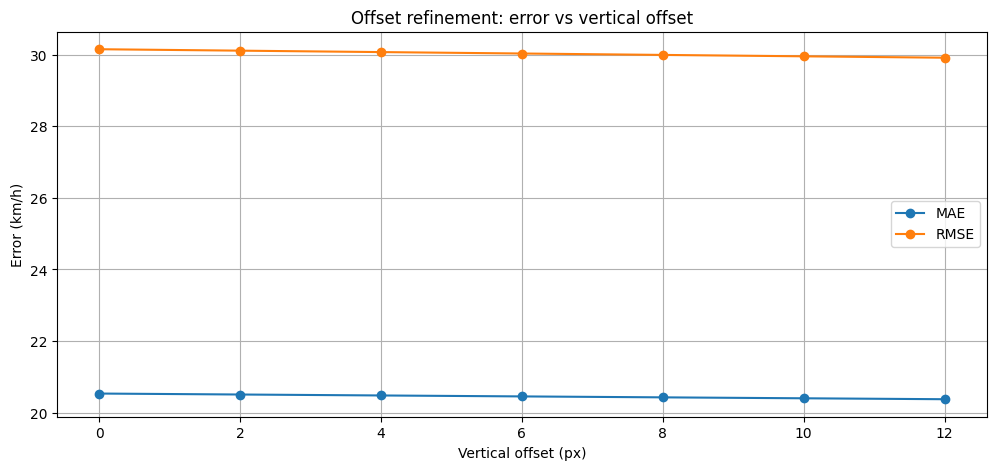

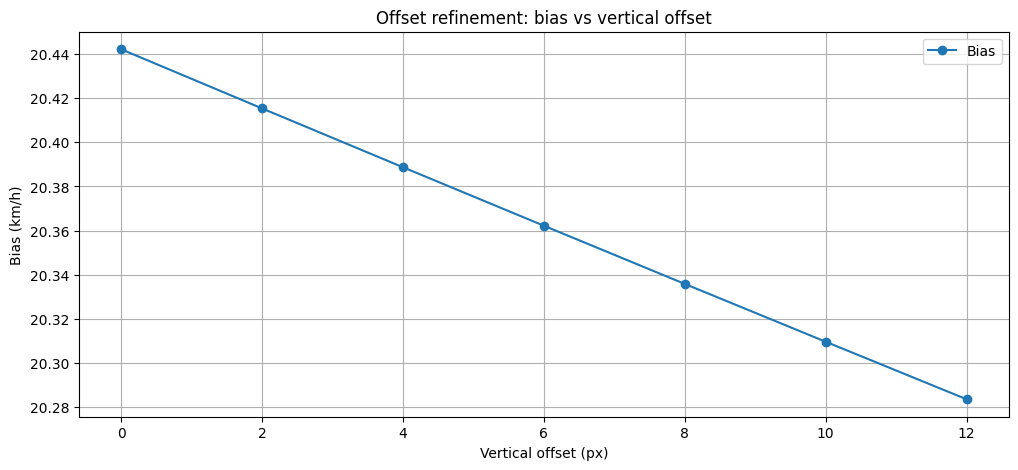

,label,offset_px,mae_kmh,rmse_kmh,bias_kmh,corr
0,bottom_center_offset_0px,0,20.533845,30.149496,20.442115,0.871566
1,bottom_center_offset_+2px,2,20.507049,30.109404,20.415337,0.871610
2,bottom_center_offset_+4px,4,20.480396,30.069540,20.388704,0.871653
3,bottom_center_offset_+6px,6,20.453895,30.029911,20.362221,0.871697
4,bottom_center_offset_+8px,8,20.427582,29.990515,20.335887,0.871740
5,bottom_center_offset_+10px,10,20.401416,29.951349,20.309700,0.871782
6,bottom_center_offset_+12px,12,20.375414,29.912416,20.283661,0.871824


In [60]:
# ============================================================
# Cell 52: Plot MAE/RMSE vs offset
# Purpose:
# - visualize whether performance improves, plateaus, or worsens
# - make it easy to choose the next best representative point
# ============================================================

import re
import matplotlib.pyplot as plt

plot_df = EXPERIMENT1_OFFSET_REFINEMENT_METRICS_DF.copy()

def extract_offset_px(label):
    m = re.search(r'offset_([+-]?\d+)px', label)
    if m:
        return int(m.group(1))
    return None

plot_df["offset_px"] = plot_df["label"].apply(extract_offset_px)
plot_df = plot_df.sort_values("offset_px").reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(plot_df["offset_px"], plot_df["mae_kmh"], marker="o", label="MAE")
plt.plot(plot_df["offset_px"], plot_df["rmse_kmh"], marker="o", label="RMSE")
plt.xlabel("Vertical offset (px)")
plt.ylabel("Error (km/h)")
plt.title("Offset refinement: error vs vertical offset")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(plot_df["offset_px"], plot_df["bias_kmh"], marker="o", label="Bias")
plt.xlabel("Vertical offset (px)")
plt.ylabel("Bias (km/h)")
plt.title("Offset refinement: bias vs vertical offset")
plt.grid(True)
plt.legend()
plt.show()

display(plot_df[["label", "offset_px", "mae_kmh", "rmse_kmh", "bias_kmh", "corr"]])

In [61]:
# ============================================================
# Cell 53: Define larger offset continuation sweep
# Purpose:
# - continue searching beyond +12 px
# - find the turning point before moving to Experiment 2
# ============================================================

EXPERIMENT1_OFFSET_CONTINUATION_CONFIGS = [
    {"label": "bottom_center_offset_+12px", "mode": "bottom_center_offset", "alpha": None, "offset_px": 12.0},
    {"label": "bottom_center_offset_+24px", "mode": "bottom_center_offset", "alpha": None, "offset_px": 24.0},
    {"label": "bottom_center_offset_+36px", "mode": "bottom_center_offset", "alpha": None, "offset_px": 36.0},
    {"label": "bottom_center_offset_+48px", "mode": "bottom_center_offset", "alpha": None, "offset_px": 48.0},
    {"label": "bottom_center_offset_+60px", "mode": "bottom_center_offset", "alpha": None, "offset_px": 60.0},
    {"label": "bottom_center_offset_+72px", "mode": "bottom_center_offset", "alpha": None, "offset_px": 72.0},
    {"label": "bottom_center_offset_+84px", "mode": "bottom_center_offset", "alpha": None, "offset_px": 84.0},
]

print("=== Cell 53: Larger offset continuation configs ===")
for cfg in EXPERIMENT1_OFFSET_CONTINUATION_CONFIGS:
    print(cfg)
print("===================================================")

=== Cell 53: Larger offset continuation configs ===
{'label': 'bottom_center_offset_+12px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': 12.0}
{'label': 'bottom_center_offset_+24px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': 24.0}
{'label': 'bottom_center_offset_+36px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': 36.0}
{'label': 'bottom_center_offset_+48px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': 48.0}
{'label': 'bottom_center_offset_+60px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': 60.0}
{'label': 'bottom_center_offset_+72px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': 72.0}
{'label': 'bottom_center_offset_+84px', 'mode': 'bottom_center_offset', 'alpha': None, 'offset_px': 84.0}


In [62]:
# ============================================================
# Cell 54: Run larger offset continuation sweep
# Purpose:
# - determine whether the offset improvement keeps going
# - identify plateau or degradation
# ============================================================

EXPERIMENT1_OFFSET_CONTINUATION_RESULTS = []
EXPERIMENT1_OFFSET_CONTINUATION_METRICS = []

for cfg in EXPERIMENT1_OFFSET_CONTINUATION_CONFIGS:
    result = run_experiment1_single_config(cfg)
    EXPERIMENT1_OFFSET_CONTINUATION_RESULTS.append(result)
    EXPERIMENT1_OFFSET_CONTINUATION_METRICS.append(result["metrics"])

EXPERIMENT1_OFFSET_CONTINUATION_METRICS_DF = pd.DataFrame(
    EXPERIMENT1_OFFSET_CONTINUATION_METRICS
).sort_values(
    ["mae_kmh", "rmse_kmh", "corr", "bias_kmh"],
    ascending=[True, True, False, True]
).reset_index(drop=True)

print("=== Cell 54: Larger offset continuation results ===")
display(EXPERIMENT1_OFFSET_CONTINUATION_METRICS_DF)

BEST_OFFSET_CONTINUATION_LABEL = EXPERIMENT1_OFFSET_CONTINUATION_METRICS_DF.iloc[0]["label"]
print("")
print("Best continuation config:", BEST_OFFSET_CONTINUATION_LABEL)
print("===================================================")

Exp1: bottom_center_offset_+12px:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: bottom_center_offset_+24px:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: bottom_center_offset_+36px:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: bottom_center_offset_+48px:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: bottom_center_offset_+60px:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: bottom_center_offset_+72px:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: bottom_center_offset_+84px:   0%|          | 0/521 [00:00<?, ?it/s]

=== Cell 54: Larger offset continuation results ===


,label,n,mae_kmh,rmse_kmh,bias_kmh,corr,gt_mean_kmh,pred_mean_kmh,pred_max_kmh
0,bottom_center_offset_+84px,485,19.544048,28.664171,19.443745,0.873073,21.116309,40.560054,121.150922
1,bottom_center_offset_+72px,485,19.668581,28.851603,19.570682,0.872903,21.116309,40.686991,121.909605
2,bottom_center_offset_+60px,485,19.799196,29.047238,19.702798,0.872718,21.116309,40.819107,122.688110
3,bottom_center_offset_+48px,485,19.935186,29.251108,19.840123,0.872517,21.116309,40.956432,123.486403
4,bottom_center_offset_+36px,485,20.076392,29.463245,19.982693,0.872301,21.116309,41.099002,124.304515
5,bottom_center_offset_+24px,485,20.223091,29.683671,20.130528,0.872070,21.116309,41.246837,125.142385
6,bottom_center_offset_+12px,485,20.375414,29.912416,20.283661,0.871824,21.116309,41.399970,126.000037



Best continuation config: bottom_center_offset_+84px


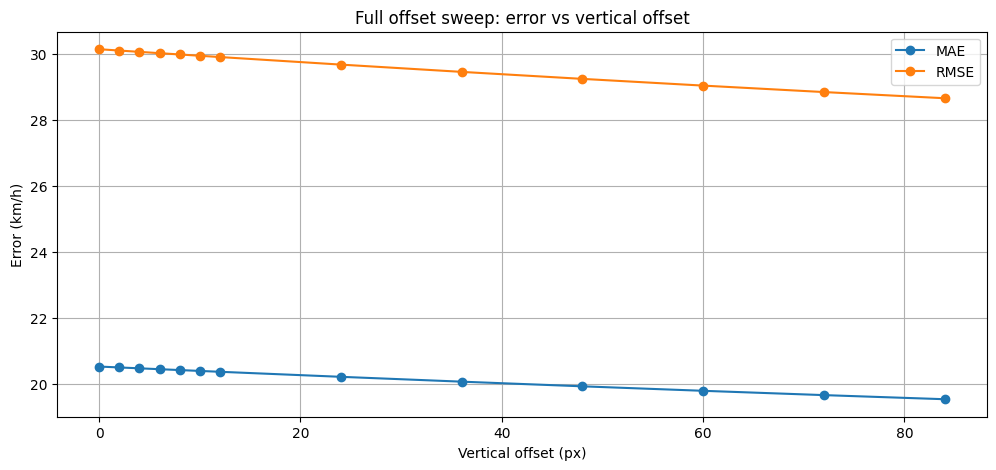

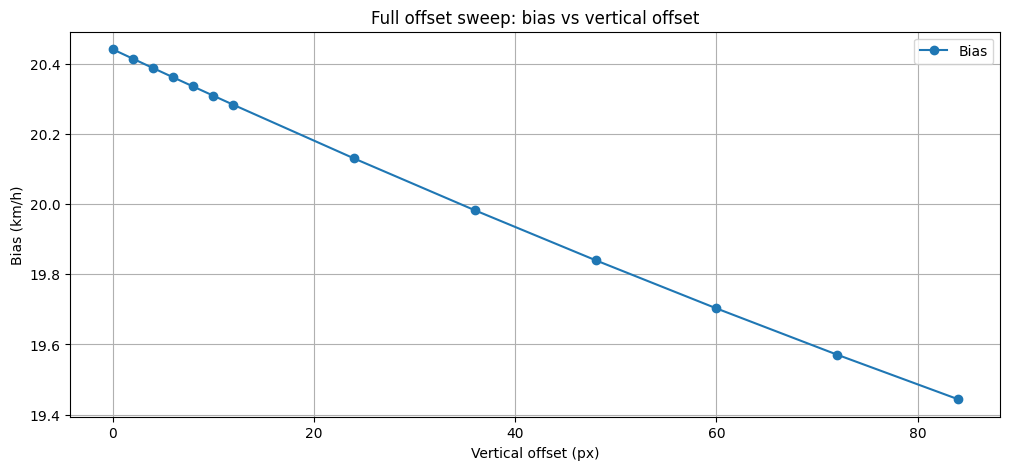

,label,offset_px,mae_kmh,rmse_kmh,bias_kmh,corr
0,bottom_center_offset_0px,0,20.533845,30.149496,20.442115,0.871566
1,bottom_center_offset_+2px,2,20.507049,30.109404,20.415337,0.871610
2,bottom_center_offset_+4px,4,20.480396,30.069540,20.388704,0.871653
3,bottom_center_offset_+6px,6,20.453895,30.029911,20.362221,0.871697
4,bottom_center_offset_+8px,8,20.427582,29.990515,20.335887,0.871740
5,bottom_center_offset_+10px,10,20.401416,29.951349,20.309700,0.871782
6,bottom_center_offset_+12px,12,20.375414,29.912416,20.283661,0.871824
7,bottom_center_offset_+24px,24,20.223091,29.683671,20.130528,0.872070
8,bottom_center_offset_+36px,36,20.076392,29.463245,19.982693,0.872301
9,bottom_center_offset_+48px,48,19.935186,29.251108,19.840123,0.872517


In [63]:
# ============================================================
# Cell 55: Plot full offset trend so far
# Purpose:
# - combine refinement + continuation results
# - visualize whether we found the turning point
# ============================================================

import re
import matplotlib.pyplot as plt
import pandas as pd

full_offset_df = pd.concat(
    [
        EXPERIMENT1_OFFSET_REFINEMENT_METRICS_DF.copy(),
        EXPERIMENT1_OFFSET_CONTINUATION_METRICS_DF.copy(),
    ],
    ignore_index=True
).drop_duplicates(subset=["label"]).copy()

def extract_offset_px(label):
    m = re.search(r'offset_([+-]?\d+)px', label)
    if m:
        return int(m.group(1))
    return None

full_offset_df["offset_px"] = full_offset_df["label"].apply(extract_offset_px)
full_offset_df = full_offset_df.sort_values("offset_px").reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(full_offset_df["offset_px"], full_offset_df["mae_kmh"], marker="o", label="MAE")
plt.plot(full_offset_df["offset_px"], full_offset_df["rmse_kmh"], marker="o", label="RMSE")
plt.xlabel("Vertical offset (px)")
plt.ylabel("Error (km/h)")
plt.title("Full offset sweep: error vs vertical offset")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(full_offset_df["offset_px"], full_offset_df["bias_kmh"], marker="o", label="Bias")
plt.xlabel("Vertical offset (px)")
plt.ylabel("Bias (km/h)")
plt.title("Full offset sweep: bias vs vertical offset")
plt.grid(True)
plt.legend()
plt.show()

display(full_offset_df[["label", "offset_px", "mae_kmh", "rmse_kmh", "bias_kmh", "corr"]])

In [64]:
# ============================================================
# Cell 56: Run a clean bottom_center baseline and capture world trajectories
# Purpose:
# - use plain bottom_center as the Experiment 2 baseline
# - store raw image/world representative-point trajectories
# - keep per-frame track observations for later smoothing
# ============================================================

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from pathlib import Path

EXPERIMENT2_BASELINE_CONFIG = {
    "label": "experiment2_bottom_center_baseline",
    "mode": "bottom_center",
    "alpha": None,
    "offset_px": 0.0,
}

def run_experiment2_collect_world_trajectories(
    config,
    video_path=VIDEO_PATH_EXPERIMENT,
    gt_csv_path=GT_CSV_PATH,
    det_every_n=1,
    det_threshold=0.30,
    min_box_area=30 * 30,
):
    global REPRESENTATIVE_POINT_MODE
    global REP_POINT_BLEND_ALPHA
    global REP_POINT_VERTICAL_OFFSET_PX

    old_mode = REPRESENTATIVE_POINT_MODE
    old_alpha = REP_POINT_BLEND_ALPHA
    old_offset = REP_POINT_VERTICAL_OFFSET_PX

    REPRESENTATIVE_POINT_MODE = config["mode"]
    REP_POINT_BLEND_ALPHA = 1.0 if config["alpha"] is None else float(config["alpha"])
    REP_POINT_VERTICAL_OFFSET_PX = 0.0 if config["offset_px"] is None else float(config["offset_px"])

    if hasattr(TRACKER, "reset"):
        TRACKER.reset()

    TRACK_HISTORIES.clear()
    FINISHED_TRACK_HISTORIES.clear()
    TRACK_LAST_SEEN_FRAME.clear()
    TRACK_STATUS.clear()

    track_meta = {}

    def build_tensors_from_detections_local(detections: "sv.Detections") -> np.ndarray:
        if len(detections) == 0:
            return np.zeros((0, 5), dtype=np.float32)
        return np.hstack([
            detections.xyxy.astype(np.float32),
            detections.confidence.reshape(-1, 1).astype(np.float32),
        ])

    def active_tracks_to_boxes_and_ids_local(tracker):
        tracks = getattr(tracker, "tracked_tracks", [])
        boxes, ids = [], []
        for t in tracks:
            boxes.append(np.array(t.tlbr, dtype=np.float32))
            ids.append(int(t.external_track_id))
        return boxes, ids

    cap = cv2.VideoCapture(str(video_path))
    assert cap.isOpened(), f"Could not open video: {video_path}"

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 1:
        fps = FPS

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    try:
        if hasattr(TRACKER, "frame_rate"):
            TRACKER.frame_rate = int(round(fps))
    except Exception:
        pass

    all_rows = []

    for frame_idx in tqdm(range(total_frames), desc=f"Exp2 collect: {config['label']}"):
        ok, frame_bgr = cap.read()
        if not ok:
            break

        if frame_idx % det_every_n == 0:
            temp_path = "temp_frame_exp2.jpg"
            cv2.imwrite(temp_path, frame_bgr)

            det = DETECTOR.predict(temp_path, threshold=det_threshold)
            detections = rfdetr_to_sv_detections(det, min_conf=det_threshold)

            if len(detections) > 0:
                xyxy = detections.xyxy
                areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
                keep = areas >= min_box_area
                detections = detections[keep]

            tensors = build_tensors_from_detections_local(detections)
            _ = TRACKER.update_with_tensors(tensors)

            det_with_ids = TRACKER.update_with_detections(detections)
            if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
                for i in range(len(det_with_ids)):
                    tid = int(det_with_ids.tracker_id[i])
                    cls = int(det_with_ids.class_id[i])
                    conf = float(det_with_ids.confidence[i])
                    track_meta[tid] = (cls, conf)
        else:
            _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

        boxes, ids = active_tracks_to_boxes_and_ids_local(TRACKER)
        active_ids_this_frame = set()

        for box, tid in zip(boxes, ids):
            active_ids_this_frame.add(int(tid))
            cls, conf = track_meta.get(tid, (-1, 0.0))

            if cls in SPEED_ESTIMATION_CLASS_IDS:
                touches_border = bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX)

                if not touches_border:
                    hist = get_or_create_track_history(tid, speed_window=DEFAULT_SPEED_WINDOW)
                    append_track_observation(
                        track_history=hist,
                        frame_idx=frame_idx,
                        box_xyxy=box,
                        class_id=cls,
                        confidence=conf,
                        fps=fps,
                    )

                    img_pt = hist["image_points"][-1]
                    world_pt = hist["world_points"][-1]

                    all_rows.append({
                        "track_id": int(tid),
                        "frame_idx": int(frame_idx),
                        "class_id": int(cls) if cls is not None else None,
                        "confidence": float(conf) if conf is not None else None,
                        "rep_mode": config["mode"],
                        "image_x": float(img_pt[0]),
                        "image_y": float(img_pt[1]),
                        "world_x": float(world_pt[0]),
                        "world_y": float(world_pt[1]),
                        "raw_speed_kmh": hist["raw_speeds_kmh"][-1],
                        "current_smoothed_speed_kmh": hist["smoothed_speeds_kmh"][-1],
                    })

            mark_track_observed(tid, frame_idx)

        update_missing_tracks(active_ids_this_frame, frame_idx, max_missing_frames=MAX_MISSING_FRAMES)

    cap.release()

    obs_df = pd.DataFrame(all_rows).sort_values(["track_id", "frame_idx"]).reset_index(drop=True)
    assert len(obs_df) > 0, "No Experiment 2 observations were collected."

    track_counts = obs_df.groupby("track_id").size().sort_values(ascending=False)
    best_track_id = int(track_counts.index[0])

    best_track_df = obs_df[obs_df["track_id"] == best_track_id].copy().reset_index(drop=True)

    gt_df_local = pd.read_csv(gt_csv_path).rename(columns={
        "frame": "frame_idx",
        "speed_kmh": "gt_speed_kmh",
    })

    compare_df_local = gt_df_local.merge(
        best_track_df[[
            "frame_idx",
            "raw_speed_kmh",
            "current_smoothed_speed_kmh",
            "world_x",
            "world_y"
        ]],
        on="frame_idx",
        how="left"
    )

    REPRESENTATIVE_POINT_MODE = old_mode
    REP_POINT_BLEND_ALPHA = old_alpha
    REP_POINT_VERTICAL_OFFSET_PX = old_offset

    return {
        "config": config,
        "obs_df": obs_df,
        "best_track_id": best_track_id,
        "best_track_df": best_track_df,
        "compare_df": compare_df_local,
        "track_counts": track_counts,
        "fps": float(fps),
    }

EXPERIMENT2_BASELINE_RESULTS = run_experiment2_collect_world_trajectories(
    EXPERIMENT2_BASELINE_CONFIG
)

EXPERIMENT2_BASELINE_TRACK_DF = EXPERIMENT2_BASELINE_RESULTS["best_track_df"].copy()
EXPERIMENT2_BASELINE_COMPARE_DF = EXPERIMENT2_BASELINE_RESULTS["compare_df"].copy()
EXPERIMENT2_FPS = EXPERIMENT2_BASELINE_RESULTS["fps"]

print("=== Cell 56: Experiment 2 baseline collected ===")
print("Best track ID:", EXPERIMENT2_BASELINE_RESULTS["best_track_id"])
print("FPS:", EXPERIMENT2_FPS)
print("Track counts:")
print(EXPERIMENT2_BASELINE_RESULTS["track_counts"].head())
print("")
print(EXPERIMENT2_BASELINE_TRACK_DF.head())
print("================================================")

Exp2 collect: experiment2_bottom_center_baseline:   0%|          | 0/521 [00:00<?, ?it/s]

=== Cell 56: Experiment 2 baseline collected ===
Best track ID: 1
FPS: 20.0
Track counts:
track_id
1    486
dtype: int64

   track_id  frame_idx  class_id  confidence       rep_mode     image_x  \
0         1          3         3    0.442996  bottom_center  400.697418   
1         1          4         3    0.545935  bottom_center  400.762878   
2         1          5         3    0.644412  bottom_center  400.742065   
3         1          6         3    0.693534  bottom_center  400.718628   
4         1          7         3    0.708591  bottom_center  400.706360   

      image_y   world_x    world_y  raw_speed_kmh  current_smoothed_speed_kmh  
0  319.354492  2.580097 -22.655924            NaN                         NaN  
1  319.387543  2.582829 -22.645903       0.747865                    0.747865  
2  319.479553  2.592309 -22.648418       0.706120                    0.726992  
3  319.445740  2.589112 -22.652149       0.353726                    0.602570  
4  319.486420  2.593332 -22

In [66]:
# ============================================================
# Cell 57: Smooth world trajectory and recompute speed
# Purpose:
# - smooth world_x/world_y before differentiating
# - compare multiple smoothing windows
# - generate new speed series from smoothed world trajectories
# ============================================================

import numpy as np
import pandas as pd

EXPERIMENT2_WORLD_SMOOTH_WINDOWS = [3, 5, 7, 9]

def centered_moving_average(arr, window):
    arr = np.asarray(arr, dtype=np.float64)
    if window <= 1:
        return arr.copy()

    s = pd.Series(arr)
    smoothed = s.rolling(window=window, center=True, min_periods=1).mean()
    return smoothed.to_numpy(dtype=np.float64)

def recompute_speed_from_world_xy(world_x, world_y, frame_idx, fps):
    world_x = np.asarray(world_x, dtype=np.float64)
    world_y = np.asarray(world_y, dtype=np.float64)
    frame_idx = np.asarray(frame_idx, dtype=np.int64)

    speeds_kmh = [None]

    for i in range(1, len(world_x)):
        dx = world_x[i] - world_x[i - 1]
        dy = world_y[i] - world_y[i - 1]
        dist_m = np.sqrt(dx * dx + dy * dy)

        dt = (frame_idx[i] - frame_idx[i - 1]) / float(fps)
        if dt <= 0:
            speeds_kmh.append(None)
        else:
            speed_kmh = (dist_m / dt) * 3.6
            speeds_kmh.append(float(speed_kmh))

    return speeds_kmh

exp2_df = EXPERIMENT2_BASELINE_TRACK_DF.copy()

for window in EXPERIMENT2_WORLD_SMOOTH_WINDOWS:
    sx_col = f"world_x_smooth_w{window}"
    sy_col = f"world_y_smooth_w{window}"
    sp_col = f"speed_from_world_smooth_w{window}_kmh"

    exp2_df[sx_col] = centered_moving_average(exp2_df["world_x"].to_numpy(), window)
    exp2_df[sy_col] = centered_moving_average(exp2_df["world_y"].to_numpy(), window)

    exp2_df[sp_col] = recompute_speed_from_world_xy(
        exp2_df[sx_col].to_numpy(),
        exp2_df[sy_col].to_numpy(),
        exp2_df["frame_idx"].to_numpy(),
        EXPERIMENT2_FPS
    )

EXPERIMENT2_SMOOTHED_WORLD_TRACK_DF = exp2_df.copy()

print("=== Cell 57: Smoothed world trajectories created ===")
print("Windows tested:", EXPERIMENT2_WORLD_SMOOTH_WINDOWS)
print("")
display(
    EXPERIMENT2_SMOOTHED_WORLD_TRACK_DF[
        ["frame_idx", "world_x", "world_y", "raw_speed_kmh", "current_smoothed_speed_kmh"] +
        [f"speed_from_world_smooth_w{w}_kmh" for w in EXPERIMENT2_WORLD_SMOOTH_WINDOWS]
    ].head(12)
)

=== Cell 57: Smoothed world trajectories created ===
Windows tested: [3, 5, 7, 9]



,frame_idx,world_x,world_y,raw_speed_kmh,current_smoothed_speed_kmh,speed_from_world_smooth_w3_kmh,speed_from_world_smooth_w5_kmh,speed_from_world_smooth_w7_kmh,speed_from_world_smooth_w9_kmh
0,3,2.580097,-22.655924,NaN,NaN,NaN,NaN,NaN,NaN
1,4,2.582829,-22.645903,0.747865,0.747865,0.267082,0.081588,0.113601,0.034064
2,5,2.592309,-22.648418,0.706120,0.726992,0.234557,0.113601,0.034064,0.094601
3,6,2.589112,-22.652149,0.353726,0.602570,0.314225,0.135170,0.094601,0.127044
4,7,2.593332,-22.653721,0.324196,0.532977,0.144077,0.232416,0.206975,0.091809
5,8,2.589176,-22.653540,0.299473,0.486276,0.187059,0.215701,0.215590,0.160709
6,9,2.596595,-22.654329,0.537176,0.444138,0.238920,0.185783,0.156075,0.176033
7,10,2.599399,-22.661613,0.561965,0.415307,0.302302,0.145581,0.137205,0.150677
8,11,2.601679,-22.655069,0.498960,0.444354,0.192708,0.182271,0.147229,0.110180
9,12,2.599277,-22.661898,0.521165,0.483748,0.077397,0.166365,0.130788,0.072746


In [67]:
# ============================================================
# Cell 58: Compare world-smoothed speed vs current smoothed_speed_kmh
# Purpose:
# - measure whether smoothing world trajectory first helps
# - rank the new speed series against the current baseline
# ============================================================

import numpy as np
import pandas as pd

gt_df_exp2 = pd.read_csv(GT_CSV_PATH).rename(columns={
    "frame": "frame_idx",
    "speed_kmh": "gt_speed_kmh"
})

exp2_compare_df = gt_df_exp2.merge(
    EXPERIMENT2_SMOOTHED_WORLD_TRACK_DF[
        ["frame_idx", "raw_speed_kmh", "current_smoothed_speed_kmh"] +
        [f"speed_from_world_smooth_w{w}_kmh" for w in EXPERIMENT2_WORLD_SMOOTH_WINDOWS]
    ],
    on="frame_idx",
    how="left"
)

def compute_metrics_exp2(df, gt_col, pred_col, label):
    sub = df[[gt_col, pred_col]].dropna().copy()
    gt = sub[gt_col].to_numpy(dtype=np.float64)
    pred = sub[pred_col].to_numpy(dtype=np.float64)

    err = pred - gt
    abs_err = np.abs(err)

    return {
        "series": label,
        "n": int(len(sub)),
        "mae_kmh": float(abs_err.mean()),
        "rmse_kmh": float(np.sqrt(np.mean(err ** 2))),
        "bias_kmh": float(err.mean()),
        "corr": float(np.corrcoef(gt, pred)[0, 1]),
        "gt_mean_kmh": float(gt.mean()),
        "pred_mean_kmh": float(pred.mean()),
        "pred_max_kmh": float(pred.max()),
    }

exp2_metrics = []

exp2_metrics.append(
    compute_metrics_exp2(
        exp2_compare_df,
        "gt_speed_kmh",
        "current_smoothed_speed_kmh",
        label="current_smoothed_speed_kmh"
    )
)

for window in EXPERIMENT2_WORLD_SMOOTH_WINDOWS:
    col = f"speed_from_world_smooth_w{window}_kmh"
    exp2_metrics.append(
        compute_metrics_exp2(
            exp2_compare_df,
            "gt_speed_kmh",
            col,
            label=col
        )
    )

EXPERIMENT2_METRICS_DF = pd.DataFrame(exp2_metrics).sort_values(
    ["mae_kmh", "rmse_kmh", "corr"],
    ascending=[True, True, False]
).reset_index(drop=True)

print("=== Cell 58: Experiment 2 metrics ===")
display(EXPERIMENT2_METRICS_DF)

best_exp2_series = EXPERIMENT2_METRICS_DF.iloc[0]["series"]
print("")
print("Best Experiment 2 series:", best_exp2_series)
print("=====================================")

=== Cell 58: Experiment 2 metrics ===


,series,n,mae_kmh,rmse_kmh,bias_kmh,corr,gt_mean_kmh,pred_mean_kmh,pred_max_kmh
0,current_smoothed_speed_kmh,485,20.533845,30.149496,20.442115,0.871566,21.116309,41.558424,126.877444
1,speed_from_world_smooth_w3_kmh,485,24.521591,61.169168,24.336576,0.527361,21.116309,45.452886,816.366186
2,speed_from_world_smooth_w5_kmh,485,25.129798,55.710760,24.911274,0.582488,21.116309,46.027584,527.626628
3,speed_from_world_smooth_w7_kmh,485,25.137398,50.961351,24.860012,0.631164,21.116309,45.976321,401.206478
4,speed_from_world_smooth_w9_kmh,485,25.239675,48.197742,24.905005,0.660347,21.116309,46.021315,329.288217



Best Experiment 2 series: current_smoothed_speed_kmh


In [68]:
# ============================================================
# Cell 59: Build a robust world-trajectory version
# Purpose:
# - suppress implausible world-position jumps
# - smooth world_x/world_y after suppression
# - prepare cleaned trajectories for robust speed estimation
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Config for revised Experiment 2
# ------------------------------------------------------------
EXPERIMENT2B_WORLD_SMOOTH_WINDOWS = [3, 5, 7]
EXPERIMENT2B_MAX_STEP_METERS = 1.5   # per observation step; conservative outlier cap

exp2b_df = EXPERIMENT2_BASELINE_TRACK_DF.copy().reset_index(drop=True)

def suppress_world_position_outliers(df, max_step_m=1.5):
    """
    If a world-position jump from previous kept point is too large,
    replace current point with previous kept point.
    This is a simple robustification step before smoothing.
    """
    df = df.copy().reset_index(drop=True)

    wx = df["world_x"].to_numpy(dtype=np.float64)
    wy = df["world_y"].to_numpy(dtype=np.float64)

    wx_clean = wx.copy()
    wy_clean = wy.copy()

    for i in range(1, len(wx_clean)):
        dx = wx_clean[i] - wx_clean[i - 1]
        dy = wy_clean[i] - wy_clean[i - 1]
        step = np.sqrt(dx * dx + dy * dy)

        if step > float(max_step_m):
            wx_clean[i] = wx_clean[i - 1]
            wy_clean[i] = wy_clean[i - 1]

    df["world_x_clean"] = wx_clean
    df["world_y_clean"] = wy_clean
    return df

def centered_moving_average(arr, window):
    arr = np.asarray(arr, dtype=np.float64)
    if window <= 1:
        return arr.copy()
    s = pd.Series(arr)
    return s.rolling(window=window, center=True, min_periods=1).mean().to_numpy(dtype=np.float64)

exp2b_df = suppress_world_position_outliers(exp2b_df, max_step_m=EXPERIMENT2B_MAX_STEP_METERS)

for window in EXPERIMENT2B_WORLD_SMOOTH_WINDOWS:
    exp2b_df[f"world_x_clean_smooth_w{window}"] = centered_moving_average(exp2b_df["world_x_clean"], window)
    exp2b_df[f"world_y_clean_smooth_w{window}"] = centered_moving_average(exp2b_df["world_y_clean"], window)

EXPERIMENT2B_TRACK_DF = exp2b_df.copy()

print("=== Cell 59: Robust world trajectory built ===")
print("World smoothing windows:", EXPERIMENT2B_WORLD_SMOOTH_WINDOWS)
print("Max allowed world step (m):", EXPERIMENT2B_MAX_STEP_METERS)
print("")
display(
    EXPERIMENT2B_TRACK_DF[
        [
            "frame_idx", "world_x", "world_y",
            "world_x_clean", "world_y_clean",
            "raw_speed_kmh", "current_smoothed_speed_kmh"
        ]
    ].head(15)
)
print("=============================================")

=== Cell 59: Robust world trajectory built ===
World smoothing windows: [3, 5, 7]
Max allowed world step (m): 1.5



,frame_idx,world_x,world_y,world_x_clean,world_y_clean,raw_speed_kmh,current_smoothed_speed_kmh
0,3,2.580097,-22.655924,2.580097,-22.655924,NaN,NaN
1,4,2.582829,-22.645903,2.582829,-22.645903,0.747865,0.747865
2,5,2.592309,-22.648418,2.592309,-22.648418,0.706120,0.726992
3,6,2.589112,-22.652149,2.589112,-22.652149,0.353726,0.602570
4,7,2.593332,-22.653721,2.593332,-22.653721,0.324196,0.532977
5,8,2.589176,-22.653540,2.589176,-22.653540,0.299473,0.486276
6,9,2.596595,-22.654329,2.596595,-22.654329,0.537176,0.444138
7,10,2.599399,-22.661613,2.599399,-22.661613,0.561965,0.415307
8,11,2.601679,-22.655069,2.601679,-22.655069,0.498960,0.444354
9,12,2.599277,-22.661898,2.599277,-22.661898,0.521165,0.483748


In [69]:
# ============================================================
# Cell 60: Compute speed from robust smoothed world trajectories
# Purpose:
# - use multi-frame gap differentiation
# - compare several (smooth_window, gap) combinations
# - avoid adjacent-frame derivative instability
# ============================================================

import numpy as np
import pandas as pd

EXPERIMENT2B_SPEED_GAPS = [3, 5, 7]

def recompute_speed_from_world_xy_gap(world_x, world_y, frame_idx, fps, gap=3):
    """
    Speed at i uses displacement from i-gap to i.
    This reduces sensitivity to residual jitter.
    """
    world_x = np.asarray(world_x, dtype=np.float64)
    world_y = np.asarray(world_y, dtype=np.float64)
    frame_idx = np.asarray(frame_idx, dtype=np.int64)

    speeds_kmh = [None] * len(world_x)

    for i in range(gap, len(world_x)):
        dx = world_x[i] - world_x[i - gap]
        dy = world_y[i] - world_y[i - gap]
        dist_m = np.sqrt(dx * dx + dy * dy)

        dt = (frame_idx[i] - frame_idx[i - gap]) / float(fps)
        if dt <= 0:
            speeds_kmh[i] = None
        else:
            speeds_kmh[i] = float((dist_m / dt) * 3.6)

    return speeds_kmh

exp2b_df = EXPERIMENT2B_TRACK_DF.copy()

for window in EXPERIMENT2B_WORLD_SMOOTH_WINDOWS:
    for gap in EXPERIMENT2B_SPEED_GAPS:
        sx_col = f"world_x_clean_smooth_w{window}"
        sy_col = f"world_y_clean_smooth_w{window}"
        sp_col = f"speed_worldclean_w{window}_gap{gap}_kmh"

        exp2b_df[sp_col] = recompute_speed_from_world_xy_gap(
            exp2b_df[sx_col].to_numpy(),
            exp2b_df[sy_col].to_numpy(),
            exp2b_df["frame_idx"].to_numpy(),
            EXPERIMENT2_FPS,
            gap=gap
        )

EXPERIMENT2B_SPEED_DF = exp2b_df.copy()

created_speed_cols = [
    f"speed_worldclean_w{w}_gap{g}_kmh"
    for w in EXPERIMENT2B_WORLD_SMOOTH_WINDOWS
    for g in EXPERIMENT2B_SPEED_GAPS
]

print("=== Cell 60: Robust world-based speed series created ===")
print("Speed gaps tested:", EXPERIMENT2B_SPEED_GAPS)
print("")
display(
    EXPERIMENT2B_SPEED_DF[
        ["frame_idx", "current_smoothed_speed_kmh"] + created_speed_cols[:6]
    ].head(15)
)
print("========================================================")

=== Cell 60: Robust world-based speed series created ===
Speed gaps tested: [3, 5, 7]



,frame_idx,current_smoothed_speed_kmh,speed_worldclean_w3_gap3_kmh,speed_worldclean_w3_gap5_kmh,speed_worldclean_w3_gap7_kmh,speed_worldclean_w5_gap3_kmh,speed_worldclean_w5_gap5_kmh,speed_worldclean_w5_gap7_kmh
0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,0.747865,NaN,NaN,NaN,NaN,NaN,NaN
2,5,0.726992,NaN,NaN,NaN,NaN,NaN,NaN
3,6,0.602570,0.243213,NaN,NaN,0.103789,NaN,NaN
4,7,0.532977,0.150189,NaN,NaN,0.150980,NaN,NaN
5,8,0.486276,0.169556,0.171951,NaN,0.170799,0.141234,NaN
6,9,0.444138,0.147379,0.170799,NaN,0.199033,0.160707,NaN
7,10,0.415307,0.228156,0.199033,0.193126,0.169405,0.164621,0.145281
8,11,0.444354,0.217670,0.169405,0.182671,0.164074,0.182777,0.159525
9,12,0.483748,0.141130,0.164074,0.162767,0.160346,0.169392,0.166175


In [70]:
# ============================================================
# Cell 61: Evaluate revised Experiment 2
# Purpose:
# - compare current baseline vs robust world-smoothed multi-gap speeds
# - determine whether revised Experiment 2 beats plain bottom_center
# ============================================================

import numpy as np
import pandas as pd

gt_df_exp2b = pd.read_csv(GT_CSV_PATH).rename(columns={
    "frame": "frame_idx",
    "speed_kmh": "gt_speed_kmh"
})

compare_cols = ["current_smoothed_speed_kmh"] + created_speed_cols

exp2b_compare_df = gt_df_exp2b.merge(
    EXPERIMENT2B_SPEED_DF[["frame_idx"] + compare_cols],
    on="frame_idx",
    how="left"
)

def compute_metrics_exp2b(df, gt_col, pred_col, label):
    sub = df[[gt_col, pred_col]].dropna().copy()
    gt = sub[gt_col].to_numpy(dtype=np.float64)
    pred = sub[pred_col].to_numpy(dtype=np.float64)

    err = pred - gt
    abs_err = np.abs(err)

    return {
        "series": label,
        "n": int(len(sub)),
        "mae_kmh": float(abs_err.mean()),
        "rmse_kmh": float(np.sqrt(np.mean(err ** 2))),
        "bias_kmh": float(err.mean()),
        "corr": float(np.corrcoef(gt, pred)[0, 1]),
        "gt_mean_kmh": float(gt.mean()),
        "pred_mean_kmh": float(pred.mean()),
        "pred_max_kmh": float(pred.max()),
    }

exp2b_metrics = []
for col in compare_cols:
    exp2b_metrics.append(
        compute_metrics_exp2b(
            exp2b_compare_df,
            "gt_speed_kmh",
            col,
            label=col
        )
    )

EXPERIMENT2B_METRICS_DF = pd.DataFrame(exp2b_metrics).sort_values(
    ["mae_kmh", "rmse_kmh", "corr"],
    ascending=[True, True, False]
).reset_index(drop=True)

print("=== Cell 61: Revised Experiment 2 metrics ===")
display(EXPERIMENT2B_METRICS_DF)

best_exp2b_series = EXPERIMENT2B_METRICS_DF.iloc[0]["series"]
print("")
print("Best revised Experiment 2 series:", best_exp2b_series)
print("=============================================")

=== Cell 61: Revised Experiment 2 metrics ===


,series,n,mae_kmh,rmse_kmh,bias_kmh,corr,gt_mean_kmh,pred_mean_kmh,pred_max_kmh
0,speed_worldclean_w7_gap7_kmh,479,17.351579,23.110561,-11.813715,0.287364,21.356159,9.542444,73.227517
1,speed_worldclean_w5_gap7_kmh,479,17.401248,23.152864,-11.787522,0.288814,21.356159,9.568637,74.988466
2,speed_worldclean_w7_gap5_kmh,481,17.417258,23.165357,-11.684886,0.285446,21.268233,9.583347,74.988466
3,speed_worldclean_w3_gap7_kmh,479,17.436279,23.185983,-11.768944,0.289685,21.356159,9.587214,77.586015
4,speed_worldclean_w5_gap5_kmh,481,17.478518,23.219804,-11.649263,0.287094,21.268233,9.618969,77.421953
5,speed_worldclean_w7_gap3_kmh,483,17.505905,23.231797,-11.577559,0.280115,21.183126,9.605567,77.586015
6,speed_worldclean_w3_gap5_kmh,481,17.527689,23.264938,-11.620314,0.288238,21.268233,9.647919,81.277486
7,speed_worldclean_w5_gap3_kmh,483,17.588995,23.312549,-11.544395,0.280733,21.183126,9.638732,81.277486
8,speed_worldclean_w3_gap3_kmh,483,17.701819,23.410583,-11.517005,0.280154,21.183126,9.666121,85.327428
9,current_smoothed_speed_kmh,485,20.533845,30.149496,20.442115,0.871566,21.116309,41.558424,126.877444



Best revised Experiment 2 series: speed_worldclean_w7_gap7_kmh


In [71]:
# ============================================================
# Cell 62: Add pseudo-footprint representative point modes
# Purpose:
# - support footprint-style points derived from the lower part of the box
# - define the representative point as the center of the bottom p% region
# - keep earlier modes intact
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Global config for pseudo-footprint mode
# ------------------------------------------------------------
PSEUDO_FOOTPRINT_BOTTOM_FRAC = 0.30   # fraction of box height kept at the bottom

def representative_point_xyxy(box_xyxy, mode=REPRESENTATIVE_POINT_MODE):
    """
    Extended representative-point selector.

    Supported modes:
      - "center"
      - "bottom_center"
      - "blend_center_bottom"
      - "bottom_center_offset"
      - "pseudo_footprint_center"
    """
    box_xyxy = np.asarray(box_xyxy, dtype=np.float32)
    x1, y1, x2, y2 = map(float, box_xyxy)

    if mode == "center":
        return bbox_center_xyxy(box_xyxy)

    elif mode == "bottom_center":
        return bbox_bottom_center_xyxy(
            box_xyxy,
            y_offset_px=BOTTOM_CENTER_Y_OFFSET_PX
        )

    elif mode == "blend_center_bottom":
        center_pt = bbox_center_xyxy(box_xyxy)
        bottom_pt = bbox_bottom_center_xyxy(
            box_xyxy,
            y_offset_px=BOTTOM_CENTER_Y_OFFSET_PX
        )
        alpha = float(REP_POINT_BLEND_ALPHA)
        alpha = max(0.0, min(1.0, alpha))
        return ((1.0 - alpha) * center_pt + alpha * bottom_pt).astype(np.float32)

    elif mode == "bottom_center_offset":
        return bbox_bottom_center_xyxy(
            box_xyxy,
            y_offset_px=float(REP_POINT_VERTICAL_OFFSET_PX)
        )

    elif mode == "pseudo_footprint_center":
        h = y2 - y1
        frac = float(PSEUDO_FOOTPRINT_BOTTOM_FRAC)
        frac = max(0.05, min(1.0, frac))

        # bottom pseudo-footprint strip
        pseudo_top = y2 - frac * h
        pseudo_bottom = y2
        pseudo_center_x = 0.5 * (x1 + x2)
        pseudo_center_y = 0.5 * (pseudo_top + pseudo_bottom)

        return np.array([pseudo_center_x, pseudo_center_y], dtype=np.float32)

    else:
        raise ValueError(f"Unsupported representative-point mode: {mode}")

print("=== Cell 62: Pseudo-footprint representative point ready ===")
print("New supported mode: pseudo_footprint_center")
print("Current PSEUDO_FOOTPRINT_BOTTOM_FRAC =", PSEUDO_FOOTPRINT_BOTTOM_FRAC)
print("============================================================")

=== Cell 62: Pseudo-footprint representative point ready ===
New supported mode: pseudo_footprint_center
Current PSEUDO_FOOTPRINT_BOTTOM_FRAC = 0.3


In [72]:
# ============================================================
# Cell 63: Define and run Experiment 3 sweep
# Purpose:
# - test pseudo-footprint centers from bottom 20%, 30%, 40%
# - compare them against plain bottom_center baseline
# - rank by MAE / RMSE / bias / correlation
# ============================================================

import pandas as pd

EXPERIMENT3_CONFIGS = [
    {"label": "bottom_center_baseline", "mode": "bottom_center", "alpha": None, "offset_px": 0.0, "bottom_frac": None},
    {"label": "pseudo_footprint_bottom20", "mode": "pseudo_footprint_center", "alpha": None, "offset_px": None, "bottom_frac": 0.20},
    {"label": "pseudo_footprint_bottom30", "mode": "pseudo_footprint_center", "alpha": None, "offset_px": None, "bottom_frac": 0.30},
    {"label": "pseudo_footprint_bottom40", "mode": "pseudo_footprint_center", "alpha": None, "offset_px": None, "bottom_frac": 0.40},
]

def run_experiment3_single_config(
    config,
    video_path=VIDEO_PATH_EXPERIMENT,
    gt_csv_path=GT_CSV_PATH,
    det_every_n=1,
    det_threshold=0.30,
    min_box_area=30 * 30,
):
    global REPRESENTATIVE_POINT_MODE
    global REP_POINT_BLEND_ALPHA
    global REP_POINT_VERTICAL_OFFSET_PX
    global PSEUDO_FOOTPRINT_BOTTOM_FRAC

    old_mode = REPRESENTATIVE_POINT_MODE
    old_alpha = REP_POINT_BLEND_ALPHA
    old_offset = REP_POINT_VERTICAL_OFFSET_PX
    old_bottom_frac = PSEUDO_FOOTPRINT_BOTTOM_FRAC

    REPRESENTATIVE_POINT_MODE = config["mode"]
    REP_POINT_BLEND_ALPHA = 1.0 if config["alpha"] is None else float(config["alpha"])
    REP_POINT_VERTICAL_OFFSET_PX = 0.0 if config["offset_px"] is None else float(config["offset_px"])
    if config["bottom_frac"] is not None:
        PSEUDO_FOOTPRINT_BOTTOM_FRAC = float(config["bottom_frac"])

    result = run_experiment1_single_config(
        {
            "label": config["label"],
            "mode": config["mode"],
            "alpha": config["alpha"],
            "offset_px": config["offset_px"],
        },
        video_path=video_path,
        gt_csv_path=gt_csv_path,
        det_every_n=det_every_n,
        det_threshold=det_threshold,
        min_box_area=min_box_area,
    )

    # restore globals
    REPRESENTATIVE_POINT_MODE = old_mode
    REP_POINT_BLEND_ALPHA = old_alpha
    REP_POINT_VERTICAL_OFFSET_PX = old_offset
    PSEUDO_FOOTPRINT_BOTTOM_FRAC = old_bottom_frac

    # attach config info
    result["config_full"] = config
    result["metrics"]["bottom_frac"] = config["bottom_frac"]
    return result

EXPERIMENT3_RESULTS = []
EXPERIMENT3_METRICS = []

for cfg in EXPERIMENT3_CONFIGS:
    result = run_experiment3_single_config(cfg)
    EXPERIMENT3_RESULTS.append(result)
    EXPERIMENT3_METRICS.append(result["metrics"])

EXPERIMENT3_METRICS_DF = pd.DataFrame(EXPERIMENT3_METRICS).sort_values(
    ["mae_kmh", "rmse_kmh", "corr", "bias_kmh"],
    ascending=[True, True, False, True]
).reset_index(drop=True)

print("=== Cell 63: Experiment 3 results ===")
display(EXPERIMENT3_METRICS_DF)
print("")
print("Best Experiment 3 config:", EXPERIMENT3_METRICS_DF.iloc[0]["label"])
print("=====================================")

Exp1: bottom_center_baseline:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: pseudo_footprint_bottom20:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: pseudo_footprint_bottom30:   0%|          | 0/521 [00:00<?, ?it/s]

Exp1: pseudo_footprint_bottom40:   0%|          | 0/521 [00:00<?, ?it/s]

=== Cell 63: Experiment 3 results ===


,label,n,mae_kmh,rmse_kmh,bias_kmh,corr,gt_mean_kmh,pred_mean_kmh,pred_max_kmh,bottom_frac
0,bottom_center_baseline,485,20.533845,30.149496,20.442115,0.871566,21.116309,41.558424,126.877444,NaN
1,pseudo_footprint_bottom20,485,20.560139,30.275000,20.487089,0.870994,21.116309,41.603399,126.994043,0.2
2,pseudo_footprint_bottom30,485,20.584897,30.348889,20.517534,0.870643,21.116309,41.633843,127.056525,0.3
3,pseudo_footprint_bottom40,485,20.616950,30.430213,20.553284,0.870248,21.116309,41.669593,127.121750,0.4



Best Experiment 3 config: bottom_center_baseline


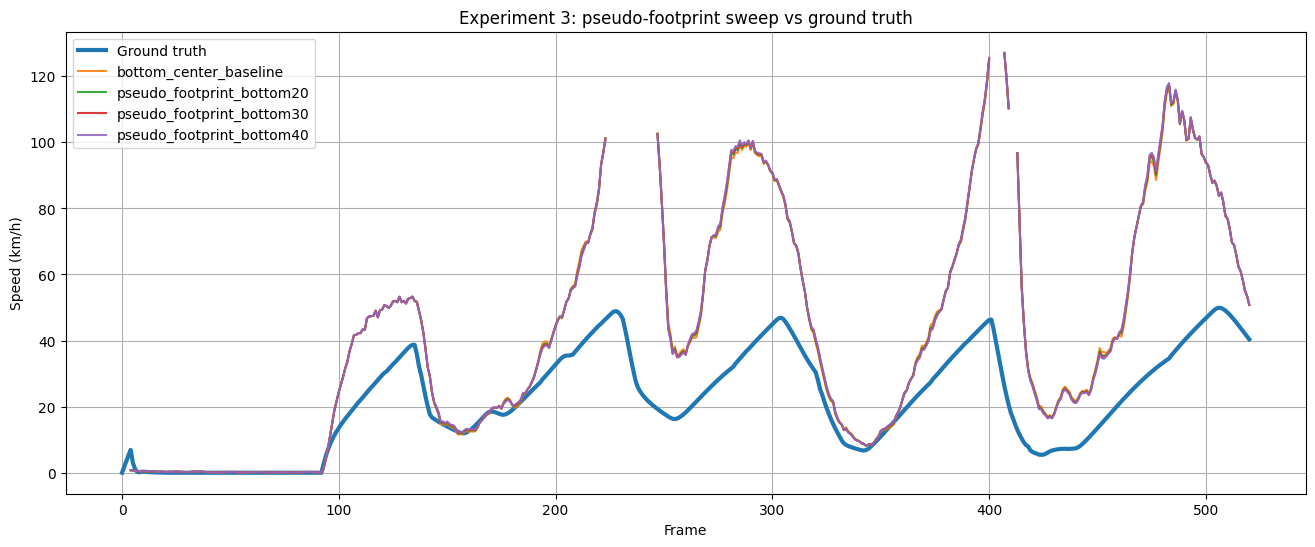

In [73]:
# ============================================================
# Cell 64: Plot Experiment 3 against ground truth
# Purpose:
# - visually compare GT vs bottom_center vs pseudo-footprint candidates
# - inspect scale bias and shape differences
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

GT_COL = "gt_speed_kmh"
COMPARE_COL = "smoothed_speed_kmh"

plot_dfs = []
for result in EXPERIMENT3_RESULTS:
    label = result["config_full"]["label"]
    df = result["compare_df"][["frame_idx", GT_COL, COMPARE_COL]].copy()
    df = df.rename(columns={COMPARE_COL: label})
    plot_dfs.append(df)

exp3_plot_df = plot_dfs[0]
for df in plot_dfs[1:]:
    exp3_plot_df = exp3_plot_df.merge(df[["frame_idx"] + [c for c in df.columns if c not in ["frame_idx", GT_COL]]],
                                      on="frame_idx", how="outer")

plt.figure(figsize=(16, 6))
plt.plot(exp3_plot_df["frame_idx"], exp3_plot_df[GT_COL], label="Ground truth", linewidth=3)

for result in EXPERIMENT3_RESULTS:
    label = result["config_full"]["label"]
    plt.plot(exp3_plot_df["frame_idx"], exp3_plot_df[label], label=label, alpha=0.9)

plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Experiment 3: pseudo-footprint sweep vs ground truth")
plt.grid(True)
plt.legend()
plt.show()

# Experiment Summary: Representative Point, World-Trajectory Smoothing, and Pseudo-Footprint Tests

## Overall purpose

The goal of these experiments was to understand **why homography-based speed estimation is inaccurate** in the current notebook and to identify which parts of the pipeline improve the estimates most effectively.

The experiments were designed to isolate three different sources of error:

1. **Representative-point choice** inside or near the detection box  
2. **Temporal instability** in the projected world trajectory  
3. **Mismatch between the 2D detection box and the car’s road-plane footprint**

The long-term goal is **not** to choose one experiment as the winner and stop there.  
The goal is to learn what each experiment fixes and then combine the best ideas into a stronger final pipeline.

---

## Experiment 1: blended representative point sweep

### Purpose
This experiment tested whether the speed estimation improves when the representative point is moved within or near the detection box.

The following point choices were tested:
- `center`
- `bottom_center`
- blended points between center and bottom-center
- vertical offsets around bottom-center

### Findings
- `bottom_center` performed better than `center`
- moving the representative point slightly downward improved the error further
- large positive offsets continued to reduce MAE/RMSE, but the required offsets became very large

### Interpretation
This showed that the representative point matters, but very large offsets likely act as an **empirical correction knob** rather than a physically meaningful ground-contact proxy.

So Experiment 1 taught us:
- lower points are better than the box center
- `bottom_center` is a strong physical baseline
- large offsets may reduce error on this sequence, but may not generalize well

### Main takeaway
Use **`bottom_center` as the physically interpretable baseline**, while treating large offsets as diagnostic rather than final.

---

## Experiment 2: smooth world trajectory before speed

### Purpose
This experiment tested whether it is better to:
1. project the representative point into world coordinates,
2. smooth the world trajectory,
3. then compute speed from the smoothed world positions,

instead of computing speed first and smoothing later.

### First attempt
The first version used simple world smoothing followed by adjacent-frame differentiation.

### Findings from first attempt
- this performed worse than the notebook baseline
- it produced unrealistic speed spikes
- smoothing alone was not enough

### Revised Experiment 2
The revised version added:
- world-position outlier suppression
- world-trajectory smoothing
- multi-frame-gap speed computation

### Findings from revised Experiment 2
- MAE and RMSE improved significantly
- the large positive bias from the baseline was greatly reduced
- however, the resulting speed series became too damped and developed a strong **negative bias**
- correlation with ground truth dropped substantially

### Interpretation
This showed that world-space smoothing is valuable, but the current settings were too aggressive. The method became more stable, but it under-tracked the true speed changes.

### Main takeaway
Experiment 2 showed that:
- **world-space smoothing + gap-based speed estimation is useful**
- but it must be tuned carefully to avoid over-damping

---

## Experiment 3: pseudo-footprint shrink / anchor sweep

### Purpose
This experiment tested whether a better geometric proxy could be obtained by defining a pseudo-footprint region inside the detection box.

The following footprint-style proxies were tested:
- center of the bottom 20% of the box
- center of the bottom 30% of the box
- center of the bottom 40% of the box

These were compared against plain `bottom_center`.

### Findings
- all pseudo-footprint variants performed almost the same as `bottom_center`
- they were slightly worse in the tested sequence
- visually, the curves were nearly identical

### Interpretation
This suggests that, for this overhead single-car video, the main error is **not** coming from the exact choice of lower-box footprint strip.

### Main takeaway
`bottom_center` is already a strong simple geometric proxy for this setup.  
More complicated lower-box footprint shrink heuristics did not materially improve the results.

---

## Combined interpretation across all three experiments

### What we learned
- The current baseline tracks the speed trend reasonably well, but it is **biased too high**
- Representative point choice matters, but box-internal geometry changes alone do not solve the main error
- World-space smoothing helps reduce error, but aggressive smoothing/gap settings can **over-correct** and create negative bias
- Pseudo-footprint shrink variants did not materially outperform `bottom_center`

### Current best understanding
At this stage, the best path forward is to use:
- **`bottom_center` as the geometric baseline**
- then perform a **lighter integration pass**
  - mild world-space smoothing
  - smaller speed gaps
  - moderate outlier suppression

### Why the integration pass is needed
The baseline and revised Experiment 2 currently fail in opposite directions:

- baseline: follows trend well, but overestimates strongly
- revised Experiment 2: much lower error, but underestimates and loses responsiveness

This suggests the best solution is likely **between these two extremes**.

---

## Next step
The next stage is an **integration / tuning pass** that combines:
- the physically interpretable `bottom_center` geometry
- the useful temporal-stabilization ideas from Experiment 2
- milder smoothing/gap settings to balance stability and responsiveness

The purpose of the integration pass is to find a method that:
- lowers MAE/RMSE
- avoids large positive bias
- avoids strong negative bias
- preserves more of the true speed dynamics

In [75]:
# ============================================================
# Cell 65: Define integration-pass configs
# Purpose:
# - combine the strongest idea from geometry (bottom_center)
#   with lighter temporal stabilization settings
# - search for a middle ground between:
#     * baseline overestimation
#     * Experiment 2 over-damping
# ============================================================

INTEGRATION_WORLD_SMOOTH_WINDOWS = [1, 3, 5]
INTEGRATION_SPEED_GAPS = [2, 3, 5]
INTEGRATION_MAX_STEP_METERS = [0.75, 1.00, 1.50]

print("=== Cell 65: Integration-pass config space ===")
print("World smooth windows :", INTEGRATION_WORLD_SMOOTH_WINDOWS)
print("Speed gaps           :", INTEGRATION_SPEED_GAPS)
print("Max step meters      :", INTEGRATION_MAX_STEP_METERS)
print("Geometry baseline    : bottom_center")
print("==============================================")

=== Cell 65: Integration-pass config space ===
World smooth windows : [1, 3, 5]
Speed gaps           : [2, 3, 5]
Max step meters      : [0.75, 1.0, 1.5]
Geometry baseline    : bottom_center


In [76]:
# ============================================================
# Cell 66: Run integration-pass sweep
# Purpose:
# - keep bottom_center geometry fixed
# - test lighter world smoothing + smaller gaps
# - compare against the original bottom_center baseline
# ============================================================

import numpy as np
import pandas as pd

def suppress_world_position_outliers_with_cap(df, max_step_m=1.5):
    df = df.copy().reset_index(drop=True)

    wx = df["world_x"].to_numpy(dtype=np.float64)
    wy = df["world_y"].to_numpy(dtype=np.float64)

    wx_clean = wx.copy()
    wy_clean = wy.copy()

    for i in range(1, len(wx_clean)):
        dx = wx_clean[i] - wx_clean[i - 1]
        dy = wy_clean[i] - wy_clean[i - 1]
        step = np.sqrt(dx * dx + dy * dy)

        if step > float(max_step_m):
            wx_clean[i] = wx_clean[i - 1]
            wy_clean[i] = wy_clean[i - 1]

    df["world_x_clean"] = wx_clean
    df["world_y_clean"] = wy_clean
    return df

def centered_moving_average(arr, window):
    arr = np.asarray(arr, dtype=np.float64)
    if window <= 1:
        return arr.copy()
    s = pd.Series(arr)
    return s.rolling(window=window, center=True, min_periods=1).mean().to_numpy(dtype=np.float64)

def recompute_speed_from_world_xy_gap(world_x, world_y, frame_idx, fps, gap=3):
    world_x = np.asarray(world_x, dtype=np.float64)
    world_y = np.asarray(world_y, dtype=np.float64)
    frame_idx = np.asarray(frame_idx, dtype=np.int64)

    speeds_kmh = [None] * len(world_x)

    for i in range(gap, len(world_x)):
        dx = world_x[i] - world_x[i - gap]
        dy = world_y[i] - world_y[i - gap]
        dist_m = np.sqrt(dx * dx + dy * dy)

        dt = (frame_idx[i] - frame_idx[i - gap]) / float(EXPERIMENT2_FPS)
        if dt > 0:
            speeds_kmh[i] = float((dist_m / dt) * 3.6)

    return speeds_kmh

def compute_metrics_integration(df, gt_col, pred_col, label):
    sub = df[[gt_col, pred_col]].dropna().copy()
    gt = sub[gt_col].to_numpy(dtype=np.float64)
    pred = sub[pred_col].to_numpy(dtype=np.float64)

    err = pred - gt
    abs_err = np.abs(err)

    return {
        "series": label,
        "n": int(len(sub)),
        "mae_kmh": float(abs_err.mean()),
        "rmse_kmh": float(np.sqrt(np.mean(err ** 2))),
        "bias_kmh": float(err.mean()),
        "corr": float(np.corrcoef(gt, pred)[0, 1]),
        "gt_mean_kmh": float(gt.mean()),
        "pred_mean_kmh": float(pred.mean()),
        "pred_max_kmh": float(pred.max()),
    }

integration_base_df = EXPERIMENT2_BASELINE_TRACK_DF.copy().reset_index(drop=True)
gt_df_integration = pd.read_csv(GT_CSV_PATH).rename(columns={
    "frame": "frame_idx",
    "speed_kmh": "gt_speed_kmh"
})

INTEGRATION_RESULTS = []
INTEGRATION_METRICS = []

# original baseline for direct comparison
baseline_compare_df = gt_df_integration.merge(
    integration_base_df[["frame_idx", "current_smoothed_speed_kmh"]],
    on="frame_idx",
    how="left"
)

INTEGRATION_METRICS.append(
    compute_metrics_integration(
        baseline_compare_df,
        "gt_speed_kmh",
        "current_smoothed_speed_kmh",
        "baseline_current_smoothed_speed_kmh"
    )
)

for max_step_m in INTEGRATION_MAX_STEP_METERS:
    capped_df = suppress_world_position_outliers_with_cap(integration_base_df, max_step_m=max_step_m)

    for window in INTEGRATION_WORLD_SMOOTH_WINDOWS:
        wx_s = centered_moving_average(capped_df["world_x_clean"].to_numpy(), window)
        wy_s = centered_moving_average(capped_df["world_y_clean"].to_numpy(), window)

        temp_df = capped_df.copy()
        temp_df[f"world_x_s{window}_cap{max_step_m}"] = wx_s
        temp_df[f"world_y_s{window}_cap{max_step_m}"] = wy_s

        for gap in INTEGRATION_SPEED_GAPS:
            series_name = f"integrated_cap{max_step_m}_w{window}_gap{gap}"
            temp_df[series_name] = recompute_speed_from_world_xy_gap(
                wx_s,
                wy_s,
                temp_df["frame_idx"].to_numpy(),
                EXPERIMENT2_FPS,
                gap=gap
            )

            compare_df = gt_df_integration.merge(
                temp_df[["frame_idx", series_name]],
                on="frame_idx",
                how="left"
            )

            metrics = compute_metrics_integration(
                compare_df,
                "gt_speed_kmh",
                series_name,
                series_name
            )

            INTEGRATION_RESULTS.append({
                "series_name": series_name,
                "max_step_m": max_step_m,
                "smooth_window": window,
                "gap": gap,
                "temp_df": temp_df.copy(),
                "compare_df": compare_df.copy(),
                "metrics": metrics,
            })
            INTEGRATION_METRICS.append(metrics)

INTEGRATION_METRICS_DF = pd.DataFrame(INTEGRATION_METRICS).sort_values(
    ["mae_kmh", "rmse_kmh", "corr"],
    ascending=[True, True, False]
).reset_index(drop=True)

print("=== Cell 66: Integration-pass metrics ===")
display(INTEGRATION_METRICS_DF.head(15))

BEST_INTEGRATION_SERIES = INTEGRATION_METRICS_DF.iloc[0]["series"]
print("")
print("Best integration series:", BEST_INTEGRATION_SERIES)
print("=========================================")

=== Cell 66: Integration-pass metrics ===


,series,n,mae_kmh,rmse_kmh,bias_kmh,corr,gt_mean_kmh,pred_mean_kmh,pred_max_kmh
0,integrated_cap1.5_w5_gap5,481,17.478518,23.219804,-11.649263,0.287094,21.268233,9.618969,77.421953
1,integrated_cap1.5_w3_gap5,481,17.527689,23.264938,-11.620314,0.288238,21.268233,9.647919,81.277486
2,integrated_cap1.5_w1_gap5,481,17.559895,23.294759,-11.604082,0.288610,21.268233,9.664151,85.177457
3,integrated_cap1.5_w5_gap3,483,17.588995,23.312549,-11.544395,0.280733,21.183126,9.638732,81.277486
4,integrated_cap1.5_w5_gap2,484,17.652310,23.375621,-11.511691,0.275623,21.145640,9.633949,82.933797
5,integrated_cap1.5_w3_gap3,483,17.701819,23.410583,-11.517005,0.280154,21.183126,9.666121,85.327428
6,integrated_cap1.0_w5_gap5,481,17.722745,23.631393,-13.331685,0.187100,21.268233,7.936548,54.295352
7,integrated_cap1.0_w3_gap5,481,17.772968,23.672426,-13.324894,0.186729,21.268233,7.943339,55.995594
8,integrated_cap1.5_w1_gap3,483,17.780595,23.506309,-11.500601,0.278571,21.183126,9.682525,89.666954
9,integrated_cap1.5_w3_gap2,484,17.792359,23.519766,-11.491117,0.273417,21.145640,9.654524,87.230613



Best integration series: integrated_cap1.5_w5_gap5


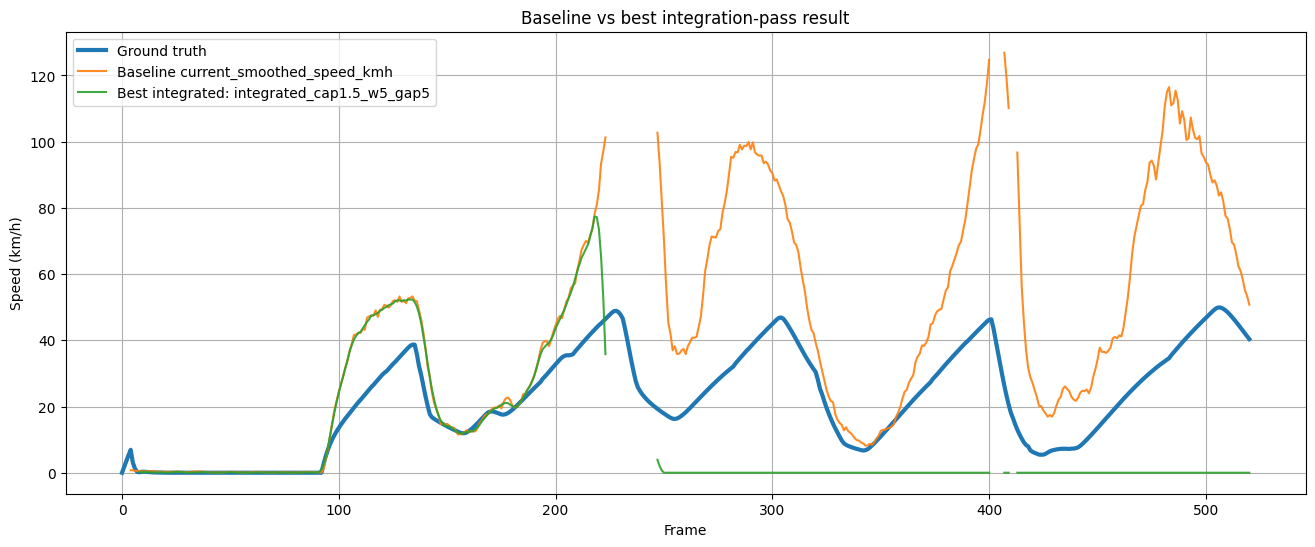

Best integration config preview:
{'series': 'integrated_cap1.5_w5_gap5', 'n': 481, 'mae_kmh': 17.478517785538216, 'rmse_kmh': 23.21980446556657, 'bias_kmh': -11.64926340441009, 'corr': 0.2870940848118882, 'gt_mean_kmh': 21.26823284823285, 'pred_mean_kmh': 9.618969443822756, 'pred_max_kmh': 77.42195308051642}


In [78]:
# ============================================================
# Cell 67: Plot baseline vs best integration result
# Purpose:
# - visually inspect whether the best integrated setting
#   gives a better balance than the original baseline
# - prepare for final decision on next tuning steps
# ============================================================

import matplotlib.pyplot as plt

best_integration_result = None
for item in INTEGRATION_RESULTS:
    if item["series_name"] == BEST_INTEGRATION_SERIES:
        best_integration_result = item
        break

assert best_integration_result is not None, "Best integration result not found."

best_compare_df = best_integration_result["compare_df"].copy()

plot_df = gt_df_integration.merge(
    integration_base_df[["frame_idx", "current_smoothed_speed_kmh"]],
    on="frame_idx",
    how="left"
).merge(
    best_compare_df[["frame_idx", BEST_INTEGRATION_SERIES]],
    on="frame_idx",
    how="left"
)

plt.figure(figsize=(16, 6))
plt.plot(plot_df["frame_idx"], plot_df["gt_speed_kmh"], label="Ground truth", linewidth=3)
plt.plot(plot_df["frame_idx"], plot_df["current_smoothed_speed_kmh"], label="Baseline current_smoothed_speed_kmh", alpha=0.9)
plt.plot(plot_df["frame_idx"], plot_df[BEST_INTEGRATION_SERIES], label=f"Best integrated: {BEST_INTEGRATION_SERIES}", alpha=0.9)

plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Baseline vs best integration-pass result")
plt.grid(True)
plt.legend()
plt.show()

print("Best integration config preview:")
print(best_integration_result["metrics"])

# Final Findings from Speed-Estimation Experiments

## Goal
The purpose of these experiments was to improve homography-based speed estimation from a fixed overhead camera by identifying which parts of the pipeline were causing the largest errors.

The tested ideas focused on:
1. representative-point choice,
2. world-trajectory smoothing,
3. pseudo-footprint geometry inside the detection box.

---

## Final conclusions

### 1. The raw pipeline captures the speed trend, but is systematically biased high
The original `bottom_center`-based speed estimator follows the general shape of the ground-truth speed curve reasonably well, but it consistently overestimates the true speed.

This means the current physical estimator is useful, but it has a strong **scale/offset bias**.

---

### 2. `bottom_center` is the best simple geometric baseline
Testing different representative points showed that:
- `center` is worse than lower points,
- `bottom_center` is better than `center`,
- blended points and pseudo-footprint shrink variants did not produce meaningful improvements over `bottom_center`.

Large positive vertical offsets reduced error numerically, but they became too large to remain physically interpretable. They appear to act more like empirical correction knobs than true ground-contact proxies.

**Decision:** use `bottom_center` as the default representative point.

---

### 3. Aggressive world-space smoothing reduces error but over-damps the signal
Smoothing the world trajectory before computing speed helped reduce MAE/RMSE, but the stronger versions of this idea:
- introduced large negative bias,
- reduced correlation with ground truth,
- and sometimes flattened the signal too much.

This means world-space stabilization is useful in principle, but the tested versions were too aggressive to serve as the final estimator.

**Decision:** do not use the aggressive Experiment 2 variants as the main speed estimator.

---

### 4. Pseudo-footprint shrink heuristics did not materially improve results
Testing representative points derived from the bottom 20%, 30%, and 40% of the detection box produced results that were almost identical to plain `bottom_center`, and slightly worse in the tested sequence.

**Decision:** do not use pseudo-footprint shrink as the default method.

---

### 5. Affine correction is currently the best practical calibration layer
Among all tested approaches, the best-performing practical method was:

1. estimate raw speed using the physically interpretable `bottom_center` baseline,
2. then apply an affine correction:
   \[
   \text{gt speed} \approx a \cdot \text{predicted speed} + b
   \]

This preserved the speed trend much better than the heavily damped smoothing approaches while greatly reducing bias and overall error.

**Decision:** use affine correction on top of the `bottom_center` baseline as the current best method.

---

## Final recommended pipeline

The current best-performing pipeline is:

1. Detect vehicles with RF-DETR
2. Track them with ByteTrack
3. Use `bottom_center` of each tracked box as the representative point
4. Project that point into world coordinates with the homography
5. Compute speed from world displacement over time
6. Smooth the raw speed lightly using the existing notebook logic
7. Apply the affine correction learned from the calibration/ground-truth comparison

This gives the best balance of:
- physical interpretability,
- trend tracking,
- and practical accuracy

based on the experiments performed so far.

---

## Important note
The affine correction is currently the best **practical** solution, but it should be understood as a calibration layer on top of a still-imperfect physical estimator.

In future work, the raw estimator could be improved further through:
- better physical camera/scale calibration,
- more robust world-trajectory filtering,
- or improved footprint localization.

For now, the best validated method is:
**`bottom_center` + homography + light smoothing + affine correction**

In [93]:
# ============================================================
# FINAL CELL: End-to-end speed estimation pipeline
# Purpose:
# - load trained RF-DETR detector
# - initialize ByteTrack tracker
# - run tracking and homography-based speed estimation
# - use bottom_center as the representative point
# - apply affine correction as the best practical calibration layer
# - save annotated output video + per-frame CSV
# ============================================================

# -----------------------------
# 0) Imports
# -----------------------------
from pathlib import Path
import inspect
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import torch
import psutil

from rfdetr import RFDETRNano

try:
    import supervision as sv
    SUPERVISION_OK = True
except Exception as e:
    SUPERVISION_OK = False
    raise ImportError(f"supervision is required for ByteTrack. Import error: {repr(e)}")

# -----------------------------
# 1) Paths / config
# -----------------------------
PHASE_ROOT = Path.cwd().parent.parent
RFDETR_MODELS_DIR = PHASE_ROOT / "rfdetr" / "models"
INFRARED_RFDETR_MODELS_DIR = RFDETR_MODELS_DIR / "infrared-training"

CKPT_PATH = INFRARED_RFDETR_MODELS_DIR / "dronevehicle_rfdetr_nano_best_ema.pth"
VIDEO_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "carla_rgb_speeds.mp4"

OUTPUT_VIDEO_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "final_best_pipeline_output.mp4"
OUTPUT_CSV_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "final_best_pipeline_observations.csv"

assert CKPT_PATH.exists(), f"Checkpoint not found: {CKPT_PATH}"
assert VIDEO_PATH.exists(), f"Video not found: {VIDEO_PATH}"

# -----------------------------
# 2) Class map
# -----------------------------
PHASE_CLASSES = {
    1: "Human",
    2: "Bicycle",
    3: "Car",
    4: "Truck",
    5: "Bus",
    6: "Other",
}

SPEED_ESTIMATION_CLASS_IDS = {3, 4, 5, 6}

# -----------------------------
# 3) Detection / tracking config
# -----------------------------
DET_THRESHOLD = 0.30
MIN_BOX_AREA = 30 * 30
DETECT_EVERY_N = 1
BORDER_MARGIN_PX = 20
DEFAULT_SPEED_WINDOW = 5
MAX_REASONABLE_SPEED_KMH = 250.0
MIN_REASONABLE_SPEED_KMH = 0.0

TRACK_THRESH = 0.30
TRACK_BUFFER = 30
MATCH_THRESH = 0.80
DEFAULT_FPS = 30.0

# -----------------------------
# 4) Best-practice geometry config
# -----------------------------
# Final choice from experiments:
# use plain bottom_center as the physical baseline.
REPRESENTATIVE_POINT_MODE = "bottom_center"
BOTTOM_CENTER_Y_OFFSET_PX = 0.0

# -----------------------------
# 5) Vehicle dimensions used in simulation
# -----------------------------
REFERENCE_VEHICLE_WIDTH_M  = 2.16
REFERENCE_VEHICLE_LENGTH_M = 4.79

# -----------------------------
# 6) Affine correction from experiments
# -----------------------------
# From earlier fitting:
#   gt ≈ 0.375625 * smoothed_speed_kmh + 5.341696
AFFINE_A = 0.375625
AFFINE_B = 5.341696

# -----------------------------
# 7) Homography setup
# IMPORTANT:
# These points must already have been selected in your notebook.
# If not, you must run your calibration cells first.
# -----------------------------
assert "REFERENCE_VEHICLE_IMAGE_POINTS" in globals(), "REFERENCE_VEHICLE_IMAGE_POINTS not found. Run the calibration cells first."

REFERENCE_VEHICLE_WORLD_POINTS = np.array([
    [0.0,                       REFERENCE_VEHICLE_LENGTH_M],  # front-left
    [REFERENCE_VEHICLE_WIDTH_M, REFERENCE_VEHICLE_LENGTH_M],  # front-right
    [REFERENCE_VEHICLE_WIDTH_M, 0.0],                         # rear-right
    [0.0,                       0.0],                         # rear-left
], dtype=np.float32)

img_pts = np.asarray(REFERENCE_VEHICLE_IMAGE_POINTS, dtype=np.float32)
world_pts = np.asarray(REFERENCE_VEHICLE_WORLD_POINTS, dtype=np.float32)

H_IMG_TO_WORLD = cv2.getPerspectiveTransform(img_pts, world_pts)
H_WORLD_TO_IMG = np.linalg.inv(H_IMG_TO_WORLD)

# -----------------------------
# 8) Helper functions
# -----------------------------
def rfdetr_to_sv_detections(det, min_conf=0.30):
    xyxy = np.asarray(det.xyxy, dtype=np.float32)
    conf = np.asarray(det.confidence, dtype=np.float32)
    cls  = np.asarray(det.class_id, dtype=np.int32)

    keep = conf >= float(min_conf)
    return sv.Detections(
        xyxy=xyxy[keep],
        confidence=conf[keep],
        class_id=cls[keep]
    )

def bbox_bottom_center_xyxy(box_xyxy, y_offset_px=0.0):
    x1, y1, x2, y2 = map(float, box_xyxy)
    cx = 0.5 * (x1 + x2)
    cy = y2 + float(y_offset_px)
    return np.array([cx, cy], dtype=np.float32)

def bbox_center_xyxy(box_xyxy):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return np.array([(x1 + x2) / 2.0, (y1 + y2) / 2.0], dtype=np.float32)

def representative_point_xyxy(box_xyxy, mode=REPRESENTATIVE_POINT_MODE):
    if mode == "bottom_center":
        return bbox_bottom_center_xyxy(box_xyxy, y_offset_px=BOTTOM_CENTER_Y_OFFSET_PX)
    elif mode == "center":
        return bbox_center_xyxy(box_xyxy)
    else:
        raise ValueError(f"Unsupported representative point mode: {mode}")

def bbox_touches_border(box_xyxy, image_width, image_height, margin_px=BORDER_MARGIN_PX):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return (
        x1 <= margin_px or
        y1 <= margin_px or
        x2 >= (image_width - margin_px) or
        y2 >= (image_height - margin_px)
    )

def image_to_world_point(point_xy, H=H_IMG_TO_WORLD):
    point_xy = np.asarray(point_xy, dtype=np.float32).reshape(1, 1, 2)
    world_xy = cv2.perspectiveTransform(point_xy, H).reshape(2)
    return world_xy.astype(np.float32)

def euclidean_distance_m(p1_world, p2_world):
    p1 = np.asarray(p1_world, dtype=np.float32)
    p2 = np.asarray(p2_world, dtype=np.float32)
    return float(np.linalg.norm(p2 - p1))

def speed_kmh_from_positions(p1_world, p2_world, frame_delta, fps):
    dt = float(frame_delta) / float(fps)
    if dt <= 0:
        return None
    dist_m = euclidean_distance_m(p1_world, p2_world)
    return float((dist_m / dt) * 3.6)

def is_reasonable_speed_kmh(speed_kmh, min_kmh=MIN_REASONABLE_SPEED_KMH, max_kmh=MAX_REASONABLE_SPEED_KMH):
    if speed_kmh is None:
        return False
    return float(min_kmh) <= float(speed_kmh) <= float(max_kmh)

def moving_average(values, window=DEFAULT_SPEED_WINDOW):
    valid = [float(v) for v in values if v is not None]
    if len(valid) == 0:
        return None
    valid = valid[-int(window):]
    return float(np.mean(valid))

def affine_correct_speed(speed_kmh, a=AFFINE_A, b=AFFINE_B):
    if speed_kmh is None:
        return None
    corrected = a * float(speed_kmh) + b
    return max(0.0, float(corrected))

def make_empty_track_history(speed_window=DEFAULT_SPEED_WINDOW):
    return {
        "frames": [],
        "image_points": [],
        "world_points": [],
        "raw_speeds_kmh": [],
        "smoothed_speeds_kmh": [],
        "affine_corrected_speeds_kmh": [],
        "last_box": None,
        "class_id": None,
        "confidence": None,
        "speed_window": int(speed_window),
    }

def append_track_observation(track_history, frame_idx, box_xyxy, class_id, confidence, fps):
    img_pt = representative_point_xyxy(box_xyxy, mode=REPRESENTATIVE_POINT_MODE)
    world_pt = image_to_world_point(img_pt)

    track_history["frames"].append(int(frame_idx))
    track_history["image_points"].append(img_pt)
    track_history["world_points"].append(world_pt)
    track_history["last_box"] = np.asarray(box_xyxy, dtype=np.float32)
    track_history["class_id"] = int(class_id) if class_id is not None else None
    track_history["confidence"] = float(confidence) if confidence is not None else None

    raw_speed_kmh = None
    if len(track_history["world_points"]) >= 2:
        p1 = track_history["world_points"][-2]
        p2 = track_history["world_points"][-1]
        f1 = track_history["frames"][-2]
        f2 = track_history["frames"][-1]
        frame_delta = f2 - f1

        raw_speed_kmh = speed_kmh_from_positions(p1, p2, frame_delta, fps)
        if raw_speed_kmh is not None and not is_reasonable_speed_kmh(raw_speed_kmh):
            raw_speed_kmh = None

    track_history["raw_speeds_kmh"].append(raw_speed_kmh)

    smoothed_speed_kmh = moving_average(
        track_history["raw_speeds_kmh"],
        window=track_history["speed_window"]
    )
    track_history["smoothed_speeds_kmh"].append(smoothed_speed_kmh)

    corrected_speed_kmh = affine_correct_speed(smoothed_speed_kmh)
    track_history["affine_corrected_speeds_kmh"].append(corrected_speed_kmh)

    return track_history

# -----------------------------
# 9) Load detector
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("=== Environment ===")
print("Python:", __import__("sys").version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("CPU cores:", psutil.cpu_count(logical=True))
print("===================")

print("Loading RF-DETR model...")
DETECTOR = RFDETRNano(pretrain_weights=str(CKPT_PATH))
DETECTOR.model.model.to(device)
DETECTOR.model.model.eval()
print("Detector ready.")

# -----------------------------
# 10) Initialize ByteTrack
# -----------------------------
sig = inspect.signature(sv.ByteTrack.__init__)
params = set(sig.parameters.keys())
kwargs = {}

if "track_activation_threshold" in params:
    kwargs["track_activation_threshold"] = TRACK_THRESH
if "lost_track_buffer" in params:
    kwargs["lost_track_buffer"] = TRACK_BUFFER
if "minimum_matching_threshold" in params:
    kwargs["minimum_matching_threshold"] = MATCH_THRESH
if "frame_rate" in params:
    kwargs["frame_rate"] = int(DEFAULT_FPS)

if "track_thresh" in params:
    kwargs["track_thresh"] = TRACK_THRESH
if "track_buffer" in params:
    kwargs["track_buffer"] = TRACK_BUFFER
if "match_thresh" in params:
    kwargs["match_thresh"] = MATCH_THRESH

try:
    TRACKER = sv.ByteTrack(**kwargs)
except TypeError:
    TRACKER = sv.ByteTrack()

print("ByteTrack ready.")
print("Tracker kwargs:", kwargs)

# -----------------------------
# 11) Video input/output
# -----------------------------
cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"

fps = cap.get(cv2.CAP_PROP_FPS)
if fps is None or fps <= 1:
    fps = DEFAULT_FPS

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

OUTPUT_VIDEO_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_VIDEO_PATH), fourcc, fps, (width, height))
assert writer.isOpened(), f"Could not open writer: {OUTPUT_VIDEO_PATH}"

try:
    if hasattr(TRACKER, "frame_rate"):
        TRACKER.frame_rate = int(round(fps))
except Exception:
    pass

if hasattr(TRACKER, "reset"):
    TRACKER.reset()

print(f"Input video  : {VIDEO_PATH}")
print(f"Output video : {OUTPUT_VIDEO_PATH}")
print(f"Output CSV   : {OUTPUT_CSV_PATH}")
print(f"Frames       : {total_frames}")
print(f"FPS          : {fps}")
print(f"Frame size   : {width}x{height}")

# -----------------------------
# 12) Track state
# -----------------------------
TRACK_HISTORIES = {}
track_meta = {}
output_rows = []

def get_or_create_track_history(track_id, speed_window=DEFAULT_SPEED_WINDOW):
    track_id = int(track_id)
    if track_id not in TRACK_HISTORIES:
        TRACK_HISTORIES[track_id] = make_empty_track_history(speed_window=speed_window)
    return TRACK_HISTORIES[track_id]

def build_tensors_from_detections(detections: "sv.Detections") -> np.ndarray:
    if len(detections) == 0:
        return np.zeros((0, 5), dtype=np.float32)
    return np.hstack([
        detections.xyxy.astype(np.float32),
        detections.confidence.reshape(-1, 1).astype(np.float32),
    ])

def active_tracks_to_boxes_and_ids(tracker):
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

# -----------------------------
# 13) Main loop
# -----------------------------
pbar = tqdm(total=total_frames, desc="Final best pipeline")

for frame_idx in range(total_frames):
    ok, frame_bgr = cap.read()
    if not ok:
        break

    # Detection step
    if frame_idx % DETECT_EVERY_N == 0:
        temp_path = "temp_final_pipeline_frame.jpg"
        cv2.imwrite(temp_path, frame_bgr)

        det = DETECTOR.predict(temp_path, threshold=DET_THRESHOLD)
        detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

        if len(detections) > 0:
            xyxy = detections.xyxy
            areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
            keep = areas >= MIN_BOX_AREA
            detections = detections[keep]

        tensors = build_tensors_from_detections(detections)
        _ = TRACKER.update_with_tensors(tensors)

        det_with_ids = TRACKER.update_with_detections(detections)
        if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
            for i in range(len(det_with_ids)):
                tid = int(det_with_ids.tracker_id[i])
                cls = int(det_with_ids.class_id[i])
                conf = float(det_with_ids.confidence[i])
                track_meta[tid] = (cls, conf)
    else:
        _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

    # Active tracks
    boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)
    out = frame_bgr.copy()

    for box, tid in zip(boxes, ids):
        cls, conf = track_meta.get(tid, (-1, 0.0))

        x1, y1, x2, y2 = box.astype(int).tolist()
        label = PHASE_CLASSES.get(cls, f"class_{cls}") if cls != -1 else "unknown"

        # draw bbox
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)

        rep_pt = representative_point_xyxy(box, mode=REPRESENTATIVE_POINT_MODE)
        rep_x, rep_y = map(int, np.round(rep_pt))
        cv2.circle(out, (rep_x, rep_y), 4, (0, 0, 255), -1)

        display_speed = None
        if cls in SPEED_ESTIMATION_CLASS_IDS:
            touches_border = bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX)

            if not touches_border:
                hist = get_or_create_track_history(tid, speed_window=DEFAULT_SPEED_WINDOW)
                append_track_observation(
                    track_history=hist,
                    frame_idx=frame_idx,
                    box_xyxy=box,
                    class_id=cls,
                    confidence=conf,
                    fps=fps,
                )

                display_speed = hist["affine_corrected_speeds_kmh"][-1]

                world_pt = hist["world_points"][-1]
                raw_speed = hist["raw_speeds_kmh"][-1]
                smooth_speed = hist["smoothed_speeds_kmh"][-1]

                output_rows.append({
                    "track_id": int(tid),
                    "frame_idx": int(frame_idx),
                    "class_id": int(cls),
                    "label": label,
                    "confidence": float(conf),
                    "bbox_x1": float(box[0]),
                    "bbox_y1": float(box[1]),
                    "bbox_x2": float(box[2]),
                    "bbox_y2": float(box[3]),
                    "rep_image_x": float(rep_pt[0]),
                    "rep_image_y": float(rep_pt[1]),
                    "world_x": float(world_pt[0]),
                    "world_y": float(world_pt[1]),
                    "raw_speed_kmh": raw_speed,
                    "smoothed_speed_kmh": smooth_speed,
                    "affine_corrected_speed_kmh": display_speed,
                })

        # trail
        if tid in TRACK_HISTORIES and len(TRACK_HISTORIES[tid]["image_points"]) >= 2:
            pts = np.array(TRACK_HISTORIES[tid]["image_points"][-20:], dtype=np.float32)
            pts = np.round(pts).astype(int)
            for j in range(1, len(pts)):
                cv2.line(out, tuple(pts[j - 1]), tuple(pts[j]), (255, 0, 0), 2, cv2.LINE_AA)

        # label text
        text = f"ID {tid}: {label} {conf:.2f}"
        if display_speed is not None:
            text += f" | {display_speed:.2f} km/h"

        cv2.putText(
            out,
            text,
            (x1, max(0, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA,
        )

    writer.write(out)
    pbar.update(1)

pbar.close()
cap.release()
writer.release()

# -----------------------------
# 14) Save CSV
# -----------------------------
final_df = pd.DataFrame(output_rows)
final_df.to_csv(OUTPUT_CSV_PATH, index=False)

print("\n=== Done ===")
print("Saved video:", OUTPUT_VIDEO_PATH)
print("Saved CSV  :", OUTPUT_CSV_PATH)
print("Rows       :", len(final_df))
print(final_df.head())

=== Environment ===
Python: 3.11.9
PyTorch: 2.5.1+cu121
CUDA available: False
CPU cores: 8
Loading RF-DETR model...
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
Detector ready.
ByteTrack ready.
Tracker kwargs: {'track_activation_threshold': 0.3, 'lost_track_buffer': 30, 'minimum_matching_threshold': 0.8, 'frame_rate': 30}
Input video  : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\carla_rgb_speeds.mp4
Output video : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\final_best_pipeline_output.mp4
Output CSV   : C:\Users\apraka01\projects\object-identification-uav-camera\

Final best pipeline:   0%|          | 0/521 [00:00<?, ?it/s]

Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().



=== Done ===
Saved video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\final_best_pipeline_output.mp4
Saved CSV  : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\final_best_pipeline_observations.csv
Rows       : 486
   track_id  frame_idx  class_id label  confidence     bbox_x1     bbox_y1  \
0         1          3         3   Car    0.442996  360.325714  281.570496   
1         1          4         3   Car    0.545935  360.377991  281.585114   
2         1          5         3   Car    0.644412  360.300262  281.616089   
3         1          6         3   Car    0.693534  360.255005  281.543579   
4         1          7         3   Car    0.708591  360.212799  281.537659   

      bbox_x2     bbox_y2  rep_image_x  rep_image_y   world_x    world_y  \
0  441.069122  319.354492   400.697418   319.354492  2.580097 -22.655924   
1  441.147766  319.387543   400.762878   319.38754

In [94]:
# ============================================================
# Final Comparison Cell 1: Load and align final output with GT
# Purpose:
# - load the final pipeline CSV from OUTPUT_CSV_PATH
# - load the simulation ground-truth CSV
# - align both by frame
# - pick the final affine-corrected speed as the main prediction
# ============================================================

import pandas as pd
import numpy as np

GT_CSV_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "carla_rgb_speeds.csv"

assert OUTPUT_CSV_PATH.exists(), f"Missing output CSV: {OUTPUT_CSV_PATH}"
assert GT_CSV_PATH.exists(), f"Missing ground-truth CSV: {GT_CSV_PATH}"

gt_df = pd.read_csv(GT_CSV_PATH).rename(columns={
    "frame": "frame_idx",
    "speed_kmh": "gt_speed_kmh"
})

pred_df = pd.read_csv(OUTPUT_CSV_PATH)

# keep the main track if multiple tracks exist
if "track_id" in pred_df.columns:
    track_counts = pred_df.groupby("track_id").size().sort_values(ascending=False)
    best_track_id = int(track_counts.index[0])
    pred_df = pred_df[pred_df["track_id"] == best_track_id].copy()
    print("Using track_id:", best_track_id)

pred_cols_available = [c for c in [
    "raw_speed_kmh",
    "smoothed_speed_kmh",
    "affine_corrected_speed_kmh"
] if c in pred_df.columns]

compare_df_final = gt_df.merge(
    pred_df[["frame_idx"] + pred_cols_available],
    on="frame_idx",
    how="left"
)

print("Ground truth rows :", len(gt_df))
print("Prediction rows   :", len(pred_df))
print("Merged rows       :", len(compare_df_final))
display(compare_df_final.head(10))

Using track_id: 1
Ground truth rows : 521
Prediction rows   : 486
Merged rows       : 521


,frame_idx,gt_speed_kmh,raw_speed_kmh,smoothed_speed_kmh,affine_corrected_speed_kmh
0,0,0.00,NaN,NaN,NaN
1,1,1.76,NaN,NaN,NaN
2,2,3.53,NaN,NaN,NaN
3,3,5.29,NaN,NaN,NaN
4,4,6.92,0.747865,0.747865,5.622613
5,5,3.04,0.706120,0.726992,5.614772
6,6,1.17,0.353726,0.602570,5.568036
7,7,0.26,0.324196,0.532977,5.541895
8,8,0.14,0.299473,0.486276,5.524353
9,9,0.28,0.537176,0.444138,5.508525


In [102]:
# ============================================================
# Final Comparison Cell 2: Metrics table
# Purpose:
# - quantify final performance for raw, smoothed, and affine-corrected speeds
# ============================================================

def compute_metrics(df, gt_col, pred_col, label):
    sub = df[[gt_col, pred_col]].dropna().copy()
    gt = sub[gt_col].to_numpy(dtype=np.float64)
    pred = sub[pred_col].to_numpy(dtype=np.float64)

    err = pred - gt
    abs_err = np.abs(err)

    return {
        "series": label,
        "n": int(len(sub)),
        "mae_kmh": float(abs_err.mean()),
        "rmse_kmh": float(np.sqrt(np.mean(err ** 2))),
        "bias_kmh": float(err.mean()),
        "corr": float(np.corrcoef(gt, pred)[0, 1]),
        "gt_mean_kmh": float(gt.mean()),
        "pred_mean_kmh": float(pred.mean()),
        "pred_max_kmh": float(pred.max()),
    }

final_metrics = []
for col in pred_cols_available:
    final_metrics.append(compute_metrics(compare_df_final, "gt_speed_kmh", col, col))

FINAL_COMPARISON_METRICS_DF = pd.DataFrame(final_metrics).sort_values(
    ["mae_kmh", "rmse_kmh", "corr"],
    ascending=[True, True, False]
).reset_index(drop=True)

display(FINAL_COMPARISON_METRICS_DF)

,series,n,mae_kmh,rmse_kmh,bias_kmh,corr,gt_mean_kmh,pred_mean_kmh,pred_max_kmh
0,affine_corrected_speed_kmh,485,6.092186,7.410849,-0.164230,0.871566,21.116309,20.952079,53.000036
1,smoothed_speed_kmh,485,20.533845,30.149496,20.442115,0.871566,21.116309,41.558424,126.877444
2,raw_speed_kmh,485,20.894170,30.642866,20.636972,0.870005,21.116309,41.753281,134.842672


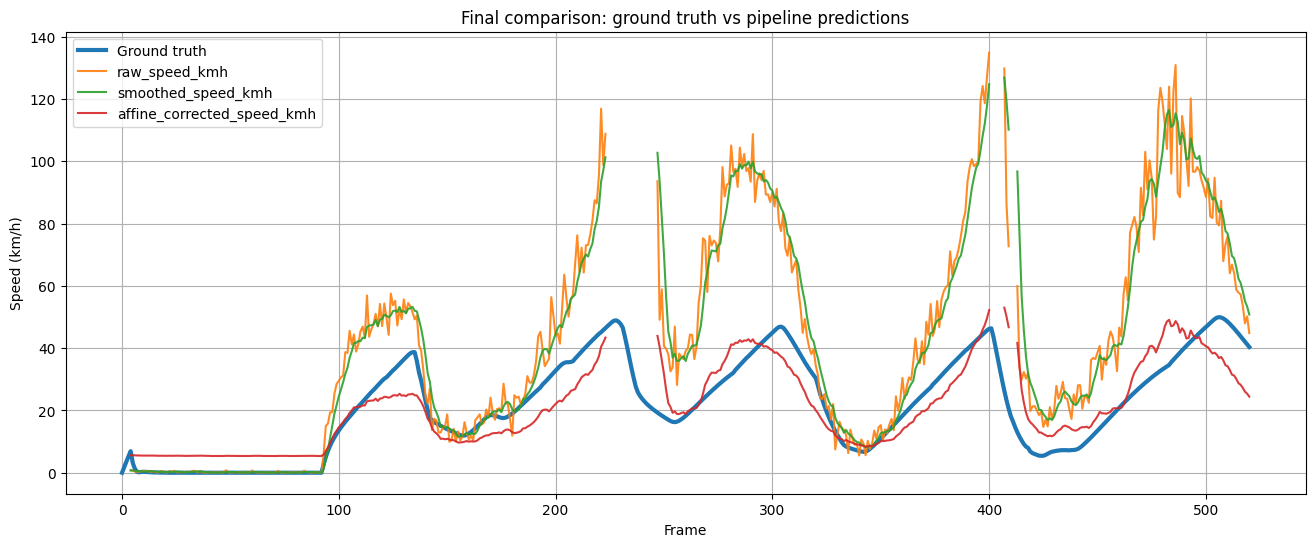

In [96]:
# ============================================================
# Final Comparison Cell 3: Plot GT vs predicted curves
# Purpose:
# - visualize ground truth against raw, smoothed, and affine-corrected speeds
# - highlight whether affine correction gives the best final alignment
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
plt.plot(compare_df_final["frame_idx"], compare_df_final["gt_speed_kmh"], label="Ground truth", linewidth=3)

for col in pred_cols_available:
    plt.plot(compare_df_final["frame_idx"], compare_df_final[col], label=col, alpha=0.9)

plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Final comparison: ground truth vs pipeline predictions")
plt.grid(True)
plt.legend()
plt.show()

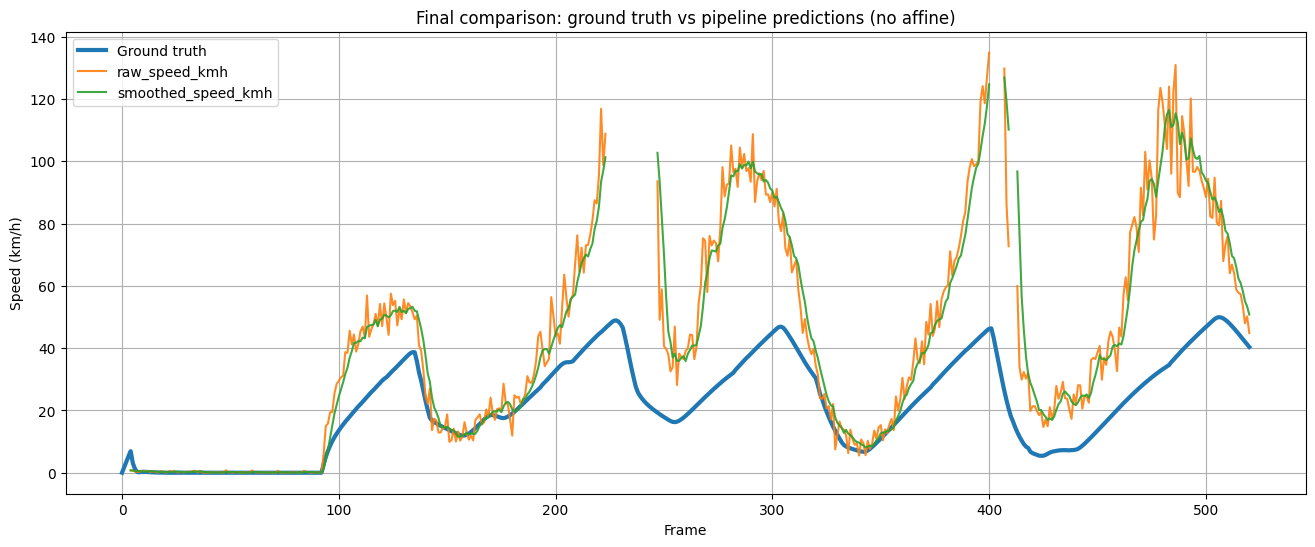

In [99]:
# ============================================================
# Final Comparison Cell 4: Plot GT vs predicted curves (no affine)
# Purpose:
# - visualize ground truth against only raw and smoothed speeds
# - exclude affine_corrected_speed_kmh from the comparison
# ============================================================

import matplotlib.pyplot as plt

non_affine_cols = [c for c in pred_cols_available if c != "affine_corrected_speed_kmh"]

plt.figure(figsize=(16, 6))
plt.plot(
    compare_df_final["frame_idx"],
    compare_df_final["gt_speed_kmh"],
    label="Ground truth",
    linewidth=3
)

for col in non_affine_cols:
    plt.plot(
        compare_df_final["frame_idx"],
        compare_df_final[col],
        label=col,
        alpha=0.9
    )

plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Final comparison: ground truth vs pipeline predictions (no affine)")
plt.grid(True)
plt.legend()
plt.show()

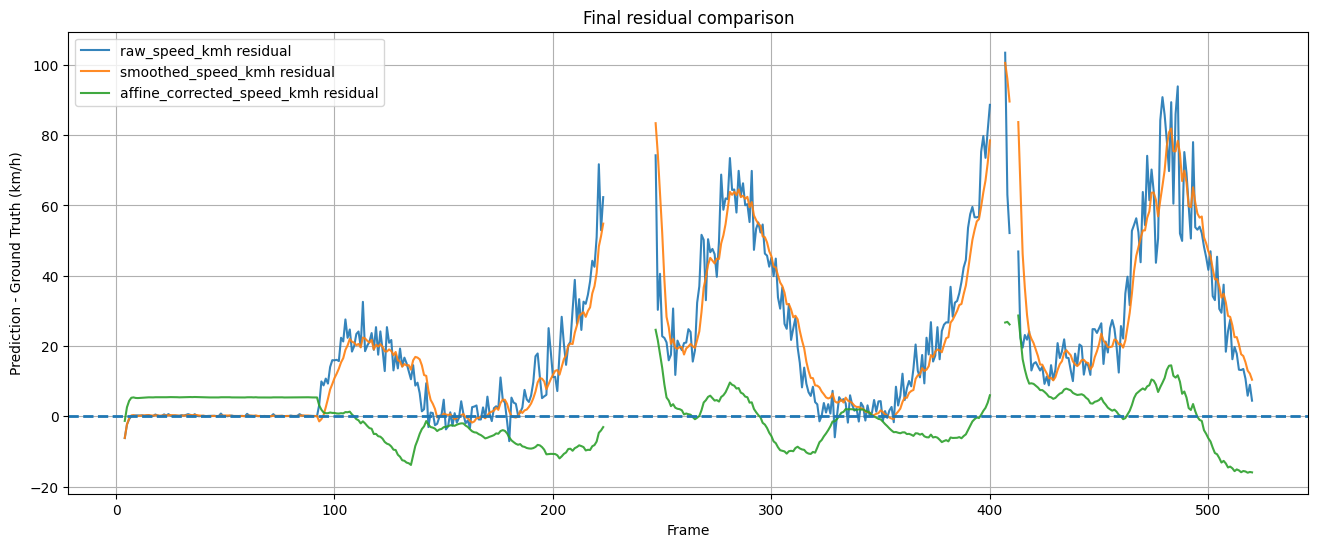

In [100]:
# ============================================================
# Final Comparison Cell 5: Residual plot
# Purpose:
# - inspect prediction-minus-ground-truth over time
# - confirm whether affine correction reduced the scale bias
# ============================================================

plt.figure(figsize=(16, 6))

for col in pred_cols_available:
    residual = compare_df_final[col] - compare_df_final["gt_speed_kmh"]
    plt.plot(compare_df_final["frame_idx"], residual, label=f"{col} residual", alpha=0.9)

plt.axhline(0, linestyle="--", linewidth=2)
plt.xlabel("Frame")
plt.ylabel("Prediction - Ground Truth (km/h)")
plt.title("Final residual comparison")
plt.grid(True)
plt.legend()
plt.show()

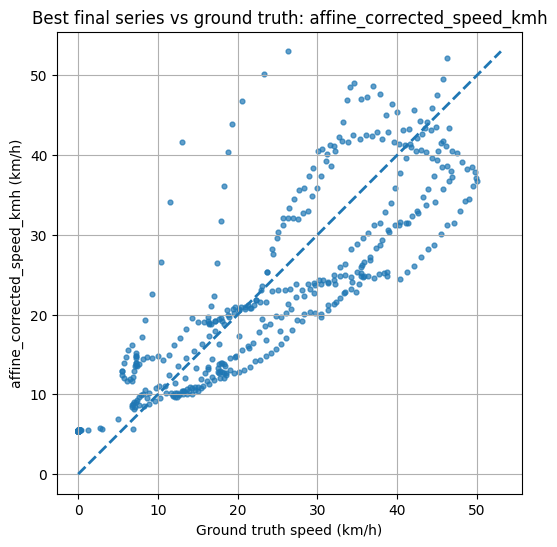

Best final series: affine_corrected_speed_kmh


In [103]:
# ============================================================
# Final Comparison Cell 6: Best-series scatter plot
# Purpose:
# - visualize how closely the best final series matches GT
# ============================================================

best_series = FINAL_COMPARISON_METRICS_DF.iloc[0]["series"]
sub = compare_df_final[["gt_speed_kmh", best_series]].dropna().copy()

plt.figure(figsize=(6, 6))
plt.scatter(sub["gt_speed_kmh"], sub[best_series], s=12, alpha=0.7)
max_v = max(sub["gt_speed_kmh"].max(), sub[best_series].max())
plt.plot([0, max_v], [0, max_v], linestyle="--", linewidth=2)

plt.xlabel("Ground truth speed (km/h)")
plt.ylabel(f"{best_series} (km/h)")
plt.title(f"Best final series vs ground truth: {best_series}")
plt.grid(True)
plt.axis("equal")
plt.show()

print("Best final series:", best_series)

In [87]:
# ============================================================
# BONUS CELL: Different Video
# ============================================================

# -----------------------------
# 0) Imports
# -----------------------------
from pathlib import Path
import inspect
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import torch
import psutil

from rfdetr import RFDETRNano

try:
    import supervision as sv
    SUPERVISION_OK = True
except Exception as e:
    SUPERVISION_OK = False
    raise ImportError(f"supervision is required for ByteTrack. Import error: {repr(e)}")

# -----------------------------
# 1) Paths / config
# -----------------------------
PHASE_ROOT = Path.cwd().parent.parent
RFDETR_MODELS_DIR = PHASE_ROOT / "rfdetr" / "models"
INFRARED_RFDETR_MODELS_DIR = RFDETR_MODELS_DIR / "infrared-training"

CKPT_PATH = INFRARED_RFDETR_MODELS_DIR / "dronevehicle_rfdetr_nano_best_ema.pth"
VIDEO_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "carla_81.mp4"

OUTPUT_VIDEO_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "personal_simulation" / "carla_81_output.mp4"
OUTPUT_CSV_PATH = Path(PHASE_ROOT) / "rfdetr" / "videos" / "carla_81_output.csv"

assert CKPT_PATH.exists(), f"Checkpoint not found: {CKPT_PATH}"
assert VIDEO_PATH.exists(), f"Video not found: {VIDEO_PATH}"

# -----------------------------
# 2) Class map
# -----------------------------
PHASE_CLASSES = {
    1: "Human",
    2: "Bicycle",
    3: "Car",
    4: "Truck",
    5: "Bus",
    6: "Other",
}

SPEED_ESTIMATION_CLASS_IDS = {3, 4, 5, 6}

# -----------------------------
# 3) Detection / tracking config
# -----------------------------
DET_THRESHOLD = 0.30
MIN_BOX_AREA = 30 * 30
DETECT_EVERY_N = 1
BORDER_MARGIN_PX = 20
DEFAULT_SPEED_WINDOW = 5
MAX_REASONABLE_SPEED_KMH = 250.0
MIN_REASONABLE_SPEED_KMH = 0.0

TRACK_THRESH = 0.30
TRACK_BUFFER = 30
MATCH_THRESH = 0.80
DEFAULT_FPS = 30.0

# -----------------------------
# 4) Best-practice geometry config
# -----------------------------
# Final choice from experiments:
# use plain bottom_center as the physical baseline.
REPRESENTATIVE_POINT_MODE = "bottom_center"
BOTTOM_CENTER_Y_OFFSET_PX = 0.0

# -----------------------------
# 5) Vehicle dimensions used in simulation
# -----------------------------
REFERENCE_VEHICLE_WIDTH_M  = 2.16
REFERENCE_VEHICLE_LENGTH_M = 4.79

# -----------------------------
# 6) Affine correction from experiments
# -----------------------------
# From earlier fitting:
#   gt ≈ 0.375625 * smoothed_speed_kmh + 5.341696
AFFINE_A = 0.375625
AFFINE_B = 5.341696

# -----------------------------
# 7) Homography setup
# IMPORTANT:
# These points must already have been selected in your notebook.
# If not, you must run your calibration cells first.
# -----------------------------
assert "REFERENCE_VEHICLE_IMAGE_POINTS" in globals(), "REFERENCE_VEHICLE_IMAGE_POINTS not found. Run the calibration cells first."

REFERENCE_VEHICLE_WORLD_POINTS = np.array([
    [0.0,                       REFERENCE_VEHICLE_LENGTH_M],  # front-left
    [REFERENCE_VEHICLE_WIDTH_M, REFERENCE_VEHICLE_LENGTH_M],  # front-right
    [REFERENCE_VEHICLE_WIDTH_M, 0.0],                         # rear-right
    [0.0,                       0.0],                         # rear-left
], dtype=np.float32)

img_pts = np.asarray(REFERENCE_VEHICLE_IMAGE_POINTS, dtype=np.float32)
world_pts = np.asarray(REFERENCE_VEHICLE_WORLD_POINTS, dtype=np.float32)

H_IMG_TO_WORLD = cv2.getPerspectiveTransform(img_pts, world_pts)
H_WORLD_TO_IMG = np.linalg.inv(H_IMG_TO_WORLD)

# -----------------------------
# 8) Helper functions
# -----------------------------
def rfdetr_to_sv_detections(det, min_conf=0.30):
    xyxy = np.asarray(det.xyxy, dtype=np.float32)
    conf = np.asarray(det.confidence, dtype=np.float32)
    cls  = np.asarray(det.class_id, dtype=np.int32)

    keep = conf >= float(min_conf)
    return sv.Detections(
        xyxy=xyxy[keep],
        confidence=conf[keep],
        class_id=cls[keep]
    )

def bbox_bottom_center_xyxy(box_xyxy, y_offset_px=0.0):
    x1, y1, x2, y2 = map(float, box_xyxy)
    cx = 0.5 * (x1 + x2)
    cy = y2 + float(y_offset_px)
    return np.array([cx, cy], dtype=np.float32)

def bbox_center_xyxy(box_xyxy):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return np.array([(x1 + x2) / 2.0, (y1 + y2) / 2.0], dtype=np.float32)

def representative_point_xyxy(box_xyxy, mode=REPRESENTATIVE_POINT_MODE):
    if mode == "bottom_center":
        return bbox_bottom_center_xyxy(box_xyxy, y_offset_px=BOTTOM_CENTER_Y_OFFSET_PX)
    elif mode == "center":
        return bbox_center_xyxy(box_xyxy)
    else:
        raise ValueError(f"Unsupported representative point mode: {mode}")

def bbox_touches_border(box_xyxy, image_width, image_height, margin_px=BORDER_MARGIN_PX):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return (
        x1 <= margin_px or
        y1 <= margin_px or
        x2 >= (image_width - margin_px) or
        y2 >= (image_height - margin_px)
    )

def image_to_world_point(point_xy, H=H_IMG_TO_WORLD):
    point_xy = np.asarray(point_xy, dtype=np.float32).reshape(1, 1, 2)
    world_xy = cv2.perspectiveTransform(point_xy, H).reshape(2)
    return world_xy.astype(np.float32)

def euclidean_distance_m(p1_world, p2_world):
    p1 = np.asarray(p1_world, dtype=np.float32)
    p2 = np.asarray(p2_world, dtype=np.float32)
    return float(np.linalg.norm(p2 - p1))

def speed_kmh_from_positions(p1_world, p2_world, frame_delta, fps):
    dt = float(frame_delta) / float(fps)
    if dt <= 0:
        return None
    dist_m = euclidean_distance_m(p1_world, p2_world)
    return float((dist_m / dt) * 3.6)

def is_reasonable_speed_kmh(speed_kmh, min_kmh=MIN_REASONABLE_SPEED_KMH, max_kmh=MAX_REASONABLE_SPEED_KMH):
    if speed_kmh is None:
        return False
    return float(min_kmh) <= float(speed_kmh) <= float(max_kmh)

def moving_average(values, window=DEFAULT_SPEED_WINDOW):
    valid = [float(v) for v in values if v is not None]
    if len(valid) == 0:
        return None
    valid = valid[-int(window):]
    return float(np.mean(valid))

def affine_correct_speed(speed_kmh, a=AFFINE_A, b=AFFINE_B):
    if speed_kmh is None:
        return None
    corrected = a * float(speed_kmh) + b
    return max(0.0, float(corrected))

def make_empty_track_history(speed_window=DEFAULT_SPEED_WINDOW):
    return {
        "frames": [],
        "image_points": [],
        "world_points": [],
        "raw_speeds_kmh": [],
        "smoothed_speeds_kmh": [],
        "affine_corrected_speeds_kmh": [],
        "last_box": None,
        "class_id": None,
        "confidence": None,
        "speed_window": int(speed_window),
    }

def append_track_observation(track_history, frame_idx, box_xyxy, class_id, confidence, fps):
    img_pt = representative_point_xyxy(box_xyxy, mode=REPRESENTATIVE_POINT_MODE)
    world_pt = image_to_world_point(img_pt)

    track_history["frames"].append(int(frame_idx))
    track_history["image_points"].append(img_pt)
    track_history["world_points"].append(world_pt)
    track_history["last_box"] = np.asarray(box_xyxy, dtype=np.float32)
    track_history["class_id"] = int(class_id) if class_id is not None else None
    track_history["confidence"] = float(confidence) if confidence is not None else None

    raw_speed_kmh = None
    if len(track_history["world_points"]) >= 2:
        p1 = track_history["world_points"][-2]
        p2 = track_history["world_points"][-1]
        f1 = track_history["frames"][-2]
        f2 = track_history["frames"][-1]
        frame_delta = f2 - f1

        raw_speed_kmh = speed_kmh_from_positions(p1, p2, frame_delta, fps)
        if raw_speed_kmh is not None and not is_reasonable_speed_kmh(raw_speed_kmh):
            raw_speed_kmh = None

    track_history["raw_speeds_kmh"].append(raw_speed_kmh)

    smoothed_speed_kmh = moving_average(
        track_history["raw_speeds_kmh"],
        window=track_history["speed_window"]
    )
    track_history["smoothed_speeds_kmh"].append(smoothed_speed_kmh)

    corrected_speed_kmh = affine_correct_speed(smoothed_speed_kmh)
    track_history["affine_corrected_speeds_kmh"].append(corrected_speed_kmh)

    return track_history

# -----------------------------
# 9) Load detector
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("=== Environment ===")
print("Python:", __import__("sys").version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("CPU cores:", psutil.cpu_count(logical=True))
print("===================")

print("Loading RF-DETR model...")
DETECTOR = RFDETRNano(pretrain_weights=str(CKPT_PATH))
DETECTOR.model.model.to(device)
DETECTOR.model.model.eval()
print("Detector ready.")

# -----------------------------
# 10) Initialize ByteTrack
# -----------------------------
sig = inspect.signature(sv.ByteTrack.__init__)
params = set(sig.parameters.keys())
kwargs = {}

if "track_activation_threshold" in params:
    kwargs["track_activation_threshold"] = TRACK_THRESH
if "lost_track_buffer" in params:
    kwargs["lost_track_buffer"] = TRACK_BUFFER
if "minimum_matching_threshold" in params:
    kwargs["minimum_matching_threshold"] = MATCH_THRESH
if "frame_rate" in params:
    kwargs["frame_rate"] = int(DEFAULT_FPS)

if "track_thresh" in params:
    kwargs["track_thresh"] = TRACK_THRESH
if "track_buffer" in params:
    kwargs["track_buffer"] = TRACK_BUFFER
if "match_thresh" in params:
    kwargs["match_thresh"] = MATCH_THRESH

try:
    TRACKER = sv.ByteTrack(**kwargs)
except TypeError:
    TRACKER = sv.ByteTrack()

print("ByteTrack ready.")
print("Tracker kwargs:", kwargs)

# -----------------------------
# 11) Video input/output
# -----------------------------
cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"

fps = cap.get(cv2.CAP_PROP_FPS)
if fps is None or fps <= 1:
    fps = DEFAULT_FPS

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

OUTPUT_VIDEO_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_VIDEO_PATH), fourcc, fps, (width, height))
assert writer.isOpened(), f"Could not open writer: {OUTPUT_VIDEO_PATH}"

try:
    if hasattr(TRACKER, "frame_rate"):
        TRACKER.frame_rate = int(round(fps))
except Exception:
    pass

if hasattr(TRACKER, "reset"):
    TRACKER.reset()

print(f"Input video  : {VIDEO_PATH}")
print(f"Output video : {OUTPUT_VIDEO_PATH}")
print(f"Output CSV   : {OUTPUT_CSV_PATH}")
print(f"Frames       : {total_frames}")
print(f"FPS          : {fps}")
print(f"Frame size   : {width}x{height}")

# -----------------------------
# 12) Track state
# -----------------------------
TRACK_HISTORIES = {}
track_meta = {}
output_rows = []

def get_or_create_track_history(track_id, speed_window=DEFAULT_SPEED_WINDOW):
    track_id = int(track_id)
    if track_id not in TRACK_HISTORIES:
        TRACK_HISTORIES[track_id] = make_empty_track_history(speed_window=speed_window)
    return TRACK_HISTORIES[track_id]

def build_tensors_from_detections(detections: "sv.Detections") -> np.ndarray:
    if len(detections) == 0:
        return np.zeros((0, 5), dtype=np.float32)
    return np.hstack([
        detections.xyxy.astype(np.float32),
        detections.confidence.reshape(-1, 1).astype(np.float32),
    ])

def active_tracks_to_boxes_and_ids(tracker):
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

# -----------------------------
# 13) Main loop
# -----------------------------
pbar = tqdm(total=total_frames, desc="Final best pipeline")

for frame_idx in range(total_frames):
    ok, frame_bgr = cap.read()
    if not ok:
        break

    # Detection step
    if frame_idx % DETECT_EVERY_N == 0:
        temp_path = "temp_final_pipeline_frame.jpg"
        cv2.imwrite(temp_path, frame_bgr)

        det = DETECTOR.predict(temp_path, threshold=DET_THRESHOLD)
        detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

        if len(detections) > 0:
            xyxy = detections.xyxy
            areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
            keep = areas >= MIN_BOX_AREA
            detections = detections[keep]

        tensors = build_tensors_from_detections(detections)
        _ = TRACKER.update_with_tensors(tensors)

        det_with_ids = TRACKER.update_with_detections(detections)
        if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
            for i in range(len(det_with_ids)):
                tid = int(det_with_ids.tracker_id[i])
                cls = int(det_with_ids.class_id[i])
                conf = float(det_with_ids.confidence[i])
                track_meta[tid] = (cls, conf)
    else:
        _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

    # Active tracks
    boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)
    out = frame_bgr.copy()

    for box, tid in zip(boxes, ids):
        cls, conf = track_meta.get(tid, (-1, 0.0))

        x1, y1, x2, y2 = box.astype(int).tolist()
        label = PHASE_CLASSES.get(cls, f"class_{cls}") if cls != -1 else "unknown"

        # draw bbox
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)

        rep_pt = representative_point_xyxy(box, mode=REPRESENTATIVE_POINT_MODE)
        rep_x, rep_y = map(int, np.round(rep_pt))
        cv2.circle(out, (rep_x, rep_y), 4, (0, 0, 255), -1)

        display_speed = None
        if cls in SPEED_ESTIMATION_CLASS_IDS:
            touches_border = bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX)

            if not touches_border:
                hist = get_or_create_track_history(tid, speed_window=DEFAULT_SPEED_WINDOW)
                append_track_observation(
                    track_history=hist,
                    frame_idx=frame_idx,
                    box_xyxy=box,
                    class_id=cls,
                    confidence=conf,
                    fps=fps,
                )

                display_speed = hist["affine_corrected_speeds_kmh"][-1]

                world_pt = hist["world_points"][-1]
                raw_speed = hist["raw_speeds_kmh"][-1]
                smooth_speed = hist["smoothed_speeds_kmh"][-1]

                output_rows.append({
                    "track_id": int(tid),
                    "frame_idx": int(frame_idx),
                    "class_id": int(cls),
                    "label": label,
                    "confidence": float(conf),
                    "bbox_x1": float(box[0]),
                    "bbox_y1": float(box[1]),
                    "bbox_x2": float(box[2]),
                    "bbox_y2": float(box[3]),
                    "rep_image_x": float(rep_pt[0]),
                    "rep_image_y": float(rep_pt[1]),
                    "world_x": float(world_pt[0]),
                    "world_y": float(world_pt[1]),
                    "raw_speed_kmh": raw_speed,
                    "smoothed_speed_kmh": smooth_speed,
                    "affine_corrected_speed_kmh": display_speed,
                })

        # trail
        if tid in TRACK_HISTORIES and len(TRACK_HISTORIES[tid]["image_points"]) >= 2:
            pts = np.array(TRACK_HISTORIES[tid]["image_points"][-20:], dtype=np.float32)
            pts = np.round(pts).astype(int)
            for j in range(1, len(pts)):
                cv2.line(out, tuple(pts[j - 1]), tuple(pts[j]), (255, 0, 0), 2, cv2.LINE_AA)

        # label text
        text = f"ID {tid}: {label} {conf:.2f}"
        if display_speed is not None:
            text += f" | {display_speed:.2f} km/h"

        cv2.putText(
            out,
            text,
            (x1, max(0, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA,
        )

    writer.write(out)
    pbar.update(1)

pbar.close()
cap.release()
writer.release()

# -----------------------------
# 14) Save CSV
# -----------------------------
final_df = pd.DataFrame(output_rows)
final_df.to_csv(OUTPUT_CSV_PATH, index=False)

print("\n=== Done ===")
print("Saved video:", OUTPUT_VIDEO_PATH)
print("Saved CSV  :", OUTPUT_CSV_PATH)
print("Rows       :", len(final_df))
print(final_df.head())

=== Environment ===
Python: 3.11.9
PyTorch: 2.5.1+cu121
CUDA available: False
CPU cores: 8
Loading RF-DETR model...
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
Detector ready.
ByteTrack ready.
Tracker kwargs: {'track_activation_threshold': 0.3, 'lost_track_buffer': 30, 'minimum_matching_threshold': 0.8, 'frame_rate': 30}
Input video  : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\carla_81.mp4
Output video : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\carla_81_output.mp4
Output CSV   : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\vide

Final best pipeline:   0%|          | 0/442 [00:00<?, ?it/s]

Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().



=== Done ===
Saved video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\carla_81_output.mp4
Saved CSV  : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\carla_81_output.csv
Rows       : 361
   track_id  frame_idx  class_id label  confidence     bbox_x1     bbox_y1  \
0         1          1         3   Car    0.537093  359.641052  280.873596   
1         1          2         3   Car    0.686635  359.571136  280.893951   
2         1          3         3   Car    0.745193  359.299713  280.642548   
3         1          4         3   Car    0.699057  359.501801  280.621033   
4         1          5         3   Car    0.709701  359.709229  280.685089   

      bbox_x2     bbox_y2  rep_image_x  rep_image_y   world_x    world_y  \
0  441.344666  318.618469   400.492859   318.618469  2.507658 -22.691393   
1  441.131470  318.567169   400.351318   318.567169  2.503765 -22.712950   
2  441.461121  318.618